# Descomposición Temporal

A continuación, se aplican modelos de descomposición de series temporales (STL y MSTL) a las series de comparendos electrónicos con el objetivo de separar y analizar sus componentes estructurales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos semanales y anuales) y residuos (componente aleatorio o irregular). Se presentan gráficos interactivos, estadísticos clave (pendiente, R², pruebas de estacionariedad, autocorrelación y ruido blanco), y se evalúa la calidad del ajuste para determinar si el modelo captura adecuadamente la estructura temporal de los datos. Este análisis permite comprender la dinámica subyacente de los comparendos, identificar tendencias crecientes o decrecientes, cuantificar la fuerza de los patrones estacionales y validar la idoneidad de los datos para aplicaciones predictivas.

## Carga de Librerías

Se importan las librerías necesarias para el análisis avanzado de las series de tiempo. Se emplean `pandas` y `numpy` para la manipulación y cálculo de estadísticos; `matplotlib.pyplot`, `seaborn` y `plotly.graph_objects` para la generación de gráficos estáticos e interactivos. Para el análisis temporal específico, se utilizan `statsmodels.tsa.seasonal.STL` y `statsmodels.tsa.seasonal.MSTL` para la descomposición robusta de series mensuales y la descomposición con estacionalidades múltiples en datos diarios, respectivamente; `statsmodels.tsa.stattools.adfuller` para la prueba de raíz unitaria (estacionariedad); `statsmodels.stats.diagnostic.acorr_ljungbox` para la prueba de ruido blanco; `statsmodels.graphics.tsaplots.plot_acf` junto con `plot_pacf` para visualizar las autocorrelaciones de los residuos. Finalmente, se suprimen los mensajes de advertencia (`warnings`) con el fin de mantener una salida limpia y centrada en los resultados del análisis.

In [14]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio

from IPython.display import display
from IPython.display import HTML
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import MSTL

In [15]:
pio.renderers.default = "notebook_connected"

## Carga del DataFrame

Se carga el archivo CSV que contiene los datos de comparendos electrónicos utilizando la función `read_csv` de la librería pandas, y se almacena en el DataFrame `df_comparendos_electronicos`.

In [16]:
df_comparendos_electronicos = pd.read_csv("C:/Users/david/Documents/seminario_investigativo/comparendos_electronicos.csv")

### Conversión de las Fechas a Formato datetime

Se convierte la columna `fecha_comparendo` al tipo `datetime` utilizando el formato especificado (`'%Y %b %d %I:%M:%S %p'`), normalizando la hora a medianoche con el método `.dt.normalize()` para eliminar la información horaria y trabajar únicamente con fechas, dado que todos los registros contienen la hora de 12:00:00 AM. Posteriormente, se imprime el tipo de dato resultante para verificar la correcta conversión.

In [17]:
df_comparendos_electronicos['fecha_comparendo'] = pd.to_datetime(df_comparendos_electronicos['fecha_comparendo'], format='%Y %b %d %I:%M:%S %p').dt.normalize()

print(df_comparendos_electronicos['fecha_comparendo'].dtype)

datetime64[ns]


### Corrección de Valores Nulos

Se rellenan los valores nulos de la columna `DESC_INFRACCION` con la descripción correspondiente al código C14, obtenida del sitio web oficial del Tránsito del Atlántico. Según esta fuente, la infracción C14 corresponde a **"Transitar por sitios restringidos o en horas prohibidas por la autoridad competente"**. Esta corrección se aplica exclusivamente a los 564 registros que presentaban valores nulos, asociados a las nuevas cámaras tipo Carril Bus implementadas en Barranquilla a partir del 17 de octubre de 2025.

**Fuente:** https://transitodelatlantico.gov.co/valor-de-multas-de-transito/

In [18]:
df_comparendos_electronicos['DESC_INFRACCION'] = df_comparendos_electronicos['DESC_INFRACCION'].fillna("Transitar por sitios restringidos o en horas prohibidas por la autoridad competente")  

print(f"Total de valores nulos en el DataFrame: {df_comparendos_electronicos.isnull().sum().sum()}")

Total de valores nulos en el DataFrame: 0


### Corrección de Cámaras Duplicadas

Se unifican los nombres de las cámaras que presentan dos notaciones diferentes para el mismo punto de control. Esta corrección permite evitar la duplicación de ubicaciones en los análisis y garantizar la consistencia de los datos.

In [19]:
df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CARRERA 53 CON CALLE 104', 'Camara_y_direccion'] = 'CARRERA 53 ENTRE CALLE 104 Y 106'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CALLE 84 CON CARRERA 59', 'Camara_y_direccion'] = 'CALLE 84 ENTRE CARRERA 59 Y 59B'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CARRERA 45 CON CALLE 53', 'Camara_y_direccion'] = 'CALLE 53 CON CARRERA 45'

df_comparendos_electronicos.loc[df_comparendos_electronicos['Camara_y_direccion'] == 'CALLE 45B CARRERA 14', 'Camara_y_direccion'] = 'CALLE 45B CON CARRERA 14'

### Corrección de Infracciones C02 Detectadas por Cámaras Fijas

Dado que estos registros representan una inconsistencia en la base de datos (las cámaras fijas no están diseñadas para detectar estacionamiento prohibido), se procede a eliminarlos del DataFrame principal para garantizar la consistencia de los análisis posteriores. Posteriormente, se verifica que no queden registros residuales de C02 asociados a cámaras fijas, confirmando la correcta limpieza de los datos.

In [20]:
df_comparendos_electronicos = df_comparendos_electronicos[~((df_comparendos_electronicos['COD_INFRACCION'] == 'C02') & 
                                                             (df_comparendos_electronicos['Tipo Camara'] == 'Fijo'))]

## Descomposición de la Serie Temporal Mensual

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a la serie temporal mensual de comparendos electrónicos, con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis robusto permite comprender la dinámica subyacente de los comparendos electrónicos, identificar si existe una tendencia creciente o decreciente en el tiempo, cuantificar la fuerza de los patrones estacionales, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de la serie, determinar si la descomposición logra eliminar la no estacionariedad de la serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas.

Pendiente: -10.10 comparendos por mes
R² (bondad de ajuste): 0.056360

P-valor (tendencia significativa): 0.019860
¿Tendencia significativa? Sí


Amplitud estacional: 3481 comparendos
Variabilidad explicada por estacionalidad: 12.64%

Prueba ADF sobre la serie original
Estadístico ADF: -3.473440
P-valor: 0.008696
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos (serie ajustada)
Estadístico ADF: -4.627189
P-valor: 0.000115
Valores críticos:
  1%: -3.5061
  5%: -2.8946
  10%: -2.5844
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   36.758961  1.962015e-06
12  65.970328  1.802890e-09
18  79.667171  9.798381e-10

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.591729
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 6.564412e-09
¿Residuos normales? No


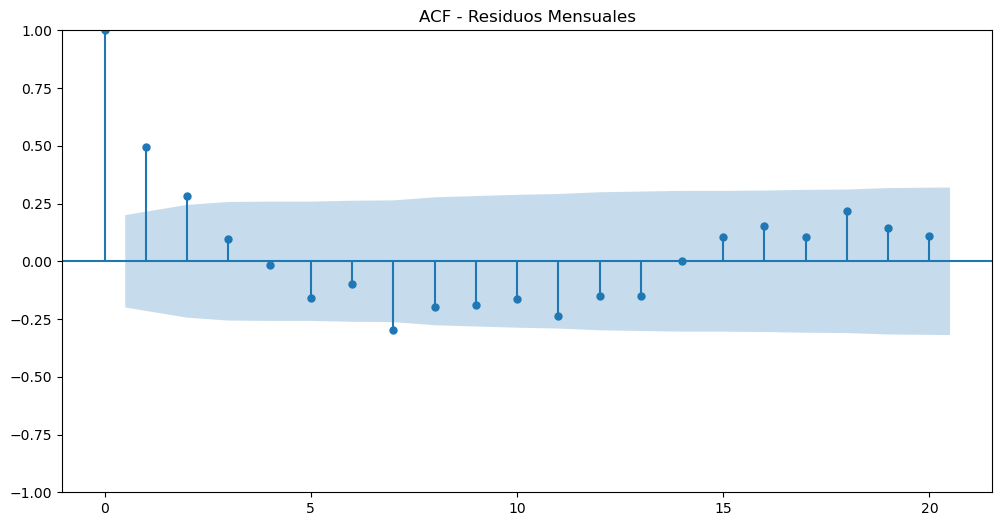

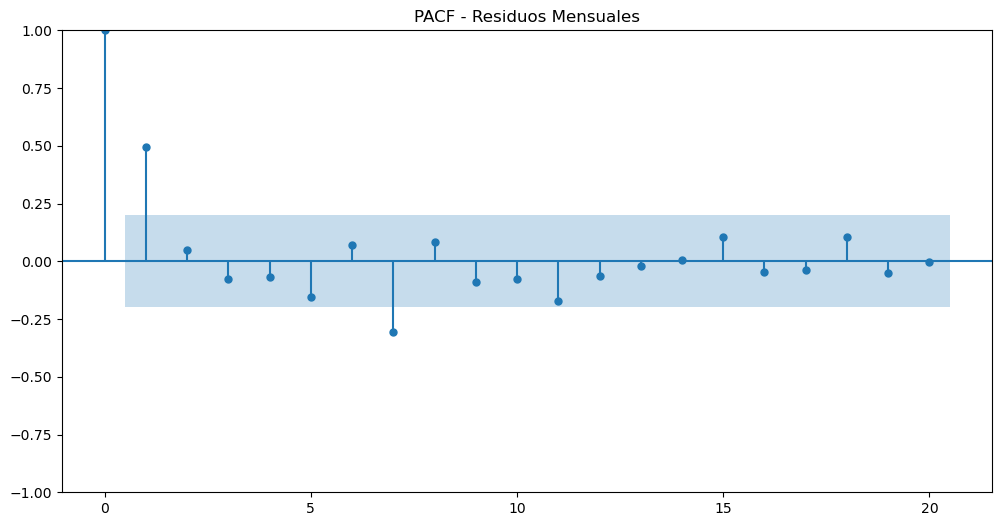

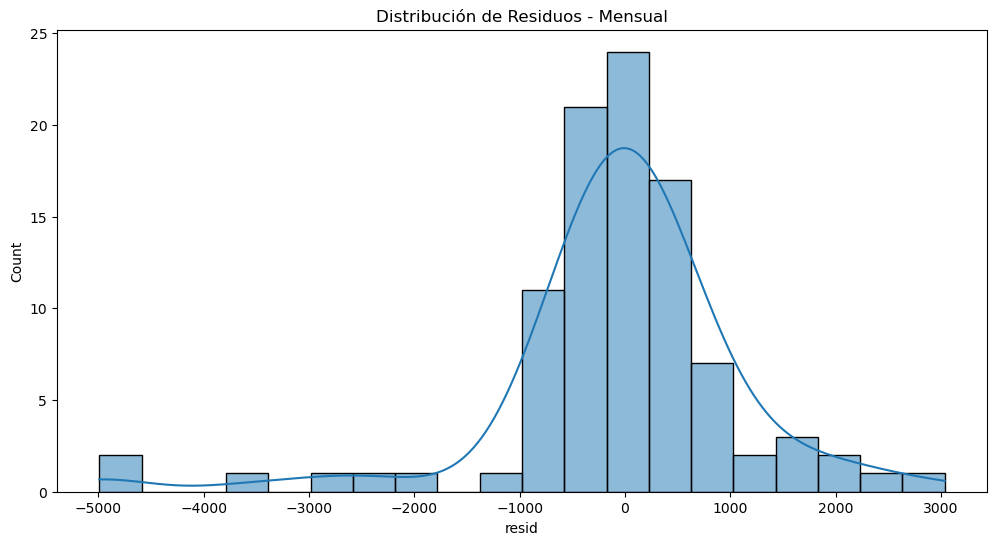

In [21]:
df_comparendos_electronicos_copy = df_comparendos_electronicos.copy()
df_comparendos_electronicos_copy['año_mes'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.to_period('M').astype(str)

infracciones_por_mes = df_comparendos_electronicos_copy.groupby('año_mes')['CANTIDAD_INFRACCIONES'].sum().sort_index()

infracciones_por_mes.index = pd.to_datetime(infracciones_por_mes.index)
infracciones_por_mes = infracciones_por_mes.asfreq('MS')
infracciones_por_mes = infracciones_por_mes.fillna(0)

descomposicion = STL(infracciones_por_mes, period=12, robust=True).fit()

tendencia_limpia = descomposicion.trend.dropna()
max_tendencia = tendencia_limpia.max()
max_fecha_tendencia = tendencia_limpia.idxmax()
min_tendencia = tendencia_limpia.min()
min_fecha_tendencia = tendencia_limpia.idxmin()

x = np.arange(len(tendencia_limpia))
pendiente, intercepto, r_value, p_valor_tendencia, std_err = stats.linregress(x, tendencia_limpia.values)
r_cuadrado = r_value ** 2
regresion_vals = pendiente * x + intercepto

fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=tendencia_limpia.index,
    y=tendencia_limpia.values,
    mode='lines+markers',
    name='Tendencia',
    line=dict(color='cornflowerblue', width=2),
    marker=dict(size=4, color='cornflowerblue'),
    hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig2.add_trace(go.Scatter(
    x=[None], y=[None], mode='none',
    name=f'Total: {int(infracciones_por_mes.sum()):,}', showlegend=True
))
fig2.add_trace(go.Scatter(
    x=[None], y=[None], mode='none',
    name=f'Std: {int(tendencia_limpia.std()):,}', showlegend=True
))
fig2.add_trace(go.Scatter(
    x=[tendencia_limpia.index[0], tendencia_limpia.index[-1]],
    y=[tendencia_limpia.mean(), tendencia_limpia.mean()],
    mode='lines', name=f'Promedio: {int(tendencia_limpia.mean()):,}',
    line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'
))

fig2.add_trace(go.Scatter(
    x=tendencia_limpia.index,
    y=regresion_vals,
    mode='lines',
    name=f'Regresión lineal (R² = {r_cuadrado:.3f})',
    line=dict(color='orange', width=2, dash='solid'),
    showlegend=True
))

fig2.add_trace(go.Scatter(
    x=[max_fecha_tendencia], y=[max_tendencia], mode='markers',
    name=f'Máximo: {max_fecha_tendencia.strftime("%Y-%m")} ({int(max_tendencia):,})',
    marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'
))

fig2.add_trace(go.Scatter(
    x=[min_fecha_tendencia], y=[min_tendencia], mode='markers',
    name=f'Mínimo: {min_fecha_tendencia.strftime("%Y-%m")} ({int(min_tendencia):,})',
    marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'
))

fig2.add_vrect(
    x0="2020-03", x1="2020-12",
    fillcolor="red", opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig2.update_layout(
    title=dict(text='Tendencia de Comparendos Electrónicos (Mensual)', x=0.5, font=dict(size=16, weight='bold')),
    xaxis_title=dict(text='Año', font=dict(weight='bold')),
    yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)),
    width=1055, height=500
)
fig2.show()

print(f"Pendiente: {pendiente:.2f} comparendos por mes")
print(f"R² (bondad de ajuste): {r_cuadrado:.6f}")

print(f"\nP-valor (tendencia significativa): {p_valor_tendencia:.6f}")
print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia < 0.05 else 'No'}")


estacionalidad_limpia = descomposicion.seasonal.dropna()
max_estacionalidad = estacionalidad_limpia.max()
max_fecha_estacionalidad = estacionalidad_limpia.idxmax()
min_estacionalidad = estacionalidad_limpia.min()
min_fecha_estacionalidad = estacionalidad_limpia.idxmin()

amplitud_estacional = estacionalidad_limpia.max() - estacionalidad_limpia.min()

var_total = descomposicion.trend.var() + descomposicion.seasonal.var() + descomposicion.resid.var()
varianza_estacional = descomposicion.seasonal.var() / var_total * 100

fig3 = go.Figure()
fig3.add_trace(go.Scatter(
    x=estacionalidad_limpia.index,
    y=estacionalidad_limpia.values,
    mode='lines+markers',
    name='Estacionalidad',
    line=dict(color='cornflowerblue', width=2),
    marker=dict(size=4, color='cornflowerblue'),
    hovertemplate='Fecha: %{x}<br>Estacionalidad: %{y:,.2f}<extra></extra>',
    showlegend=False
))

fig3.add_trace(go.Scatter(
    x=[None], y=[None], mode='none',
    name=f'Total: {int(infracciones_por_mes.sum()):,}', showlegend=True
))
fig3.add_trace(go.Scatter(
    x=[None], y=[None], mode='none',
    name=f'Std: {int(estacionalidad_limpia.std()):.0f}', showlegend=True
))
fig3.add_trace(go.Scatter(
    x=[estacionalidad_limpia.index[0], estacionalidad_limpia.index[-1]],
    y=[estacionalidad_limpia.mean(), estacionalidad_limpia.mean()],
    mode='lines', name=f'Promedio: {estacionalidad_limpia.mean():.2f}',
    line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'
))

fig3.add_trace(go.Scatter(
    x=[max_fecha_estacionalidad], y=[max_estacionalidad], mode='markers',
    name=f'Máximo: {max_fecha_estacionalidad.strftime("%Y-%m")} ({max_estacionalidad:.2f})',
    marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'
))

fig3.add_trace(go.Scatter(
    x=[min_fecha_estacionalidad], y=[min_estacionalidad], mode='markers',
    name=f'Mínimo: {min_fecha_estacionalidad.strftime("%Y-%m")} ({min_estacionalidad:.2f})',
    marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'
))

fig3.add_vrect(
    x0="2020-03", x1="2020-12",
    fillcolor="red", opacity=0.1,
    line_width=0,
    annotation_text="COVID-19", 
    annotation_position="top left",
    annotation=dict(font_size=12, font_color="red")
)

fig3.update_layout(
    title=dict(text='Estacionalidad de Comparendos Electrónicos (Mensual)', x=0.5, font=dict(size=16, weight='bold')),
    xaxis_title=dict(text='Año', font=dict(weight='bold')),
    yaxis_title=dict(text='Estacionalidad (Comparendos)', font=dict(weight='bold')),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)),
    width=1055, height=500
)
fig3.show()

print(f"Amplitud estacional: {amplitud_estacional:.0f} comparendos")
print(f"Variabilidad explicada por estacionalidad: {varianza_estacional:.2f}%")

print("\nPrueba ADF sobre la serie original")
resultado_adf_original = adfuller(infracciones_por_mes.dropna(), autolag='AIC')

print(f"Estadístico ADF: {resultado_adf_original[0]:.6f}")
print(f"P-valor: {resultado_adf_original[1]:.6f}")
print("Valores críticos:")
for key, value in resultado_adf_original[4].items():
    print(f"  {key}: {value:.4f}")

if resultado_adf_original[1] < 0.05:
    print("La serie original es estacionaria")
else:
    print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")


print("\nPrueba ADF sobre los residuos (serie ajustada)")
resultado_adf_residuos = adfuller(descomposicion.resid.dropna(), autolag='AIC')

print(f"Estadístico ADF: {resultado_adf_residuos[0]:.6f}")
print(f"P-valor: {resultado_adf_residuos[1]:.6f}")
print("Valores críticos:")
for key, value in resultado_adf_residuos[4].items():
    print(f"  {key}: {value:.4f}")

if resultado_adf_residuos[1] < 0.05:
    print("Los residuos son estacionarios")
else:
    print("Los residuos no son estacionarios")


if resultado_adf_original[1] >= 0.05 and resultado_adf_residuos[1] < 0.05:
    print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad")
elif resultado_adf_original[1] < 0.05 and resultado_adf_residuos[1] < 0.05:
    print("\nTanto la serie original como los residuos son estacionarios")
else:
    print("\nLa descomposición no logró eliminar completamente la no estacionariedad")


residuos_limpia = descomposicion.resid.dropna()

max_residuo = residuos_limpia.max()
max_fecha_residuo = residuos_limpia.idxmax()
min_residuo = residuos_limpia.min()
min_fecha_residuo = residuos_limpia.idxmin()

fig4 = go.Figure() 
fig4.add_trace(go.Scatter(
    x=residuos_limpia.index, 
    y=residuos_limpia.values, 
    mode='lines+markers', 
    name='Residuos', 
    line=dict(color='cornflowerblue', width=2), 
    marker=dict(size=4, color='cornflowerblue'), 
    hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False ))

fig4.add_trace(go.Scatter( x=[None], y=[None], mode='none', name=f'Total: {int(infracciones_por_mes.sum()):,}', showlegend=True ))

fig4.add_trace(go.Scatter( x=[None], y=[None], mode='none', name=f'Std: {int(residuos_limpia.std()):.0f}', showlegend=True ))

fig4.add_trace(go.Scatter(
    x=[residuos_limpia.index[0], residuos_limpia.index[-1]],
    y=[residuos_limpia.mean(), residuos_limpia.mean()],
    mode='lines',
    name=f'Promedio: {residuos_limpia.mean():.2f}',
    line=dict(color='red',width=1.4, dash='dot'),
    showlegend=True,
    hoverinfo='none' ))

fig4.add_trace(go.Scatter(
    x=[max_fecha_residuo],
    y=[max_residuo],
    mode='markers',
    name=f'Máximo: {max_fecha_residuo.strftime("%Y-%m")} ({max_residuo:.2f})',
    marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none' ))

fig4.add_trace(go.Scatter(
    x=[min_fecha_residuo],
    y=[min_residuo],
    mode='markers',
    name=f'Mínimo: {min_fecha_residuo.strftime("%Y-%m")} ({min_residuo:.2f})',
    marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none' ))

fig4.add_vrect( x0="2020-03", x1="2020-12",
               fillcolor="red",
               opacity=0.1,
               line_width=0,
               annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red") )

fig4.update_layout( title=dict(text='Residuos de Comparendos Electrónicos (Mensual)',
                               x=0.5, font=dict(size=16, weight='bold')),
                   xaxis_title=dict(text='Año', font=dict(weight='bold')),
                   yaxis_title=dict(text='Residuos (Comparendos)',
                                    font=dict(weight='bold')),
                   template='plotly_white', hovermode='x unified',
                   legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500 )

fig4.show()

resultado_ljung = acorr_ljungbox(residuos_limpia, lags=[6, 12, 18], return_df=True)
print("\nPrueba Ljung-Box")
print(resultado_ljung)

p_valor_ljung = resultado_ljung['lb_pvalue'].iloc[1]

t_stat, p_valor_media = stats.ttest_1samp(residuos_limpia, 0)

print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung > 0.05 else 'No'}")
print(f"Prueba t (media cero) p-valor: {p_valor_media:.6f}")
print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media > 0.05 else 'No'}")

stat, p_shapiro = stats.shapiro(residuos_limpia)
print(f"\nShapiro-Wilk p-valor: {p_shapiro:.6e}")
print(f"¿Residuos normales? {'Sí' if p_shapiro > 0.05 else 'No'}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuos_limpia, ax=ax)
plt.title("ACF - Residuos Mensuales")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(residuos_limpia, ax=ax)
plt.title("PACF - Residuos Mensuales")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(residuos_limpia, bins=20, kde=True)
plt.title("Distribución de Residuos - Mensual")
plt.show()

- **Análisis de tendencia**: La pendiente negativa de -10.1 comparendos por mes indica una disminución promedio mensual estadísticamente significativa (p-valor = 0.0199). El R² de 5.6% muestra que la tendencia lineal explica una pequeña parte de la variabilidad total, pero la relación es significativa. La prueba de Durbin-Watson con un valor de 0.0005 indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que la tendencia lineal no captura adecuadamente toda la estructura temporal y que existen patrones sistemáticos no lineales en la evolución de largo plazo. A pesar de ello, se confirma una disminución sostenida en el volumen de comparendos electrónicos a lo largo del tiempo.

- **Análisis de estacionalidad**: La estacionalidad explica el 12.6% de la variabilidad total, lo que indica que los comparendos electrónicos presentan un patrón cíclico anual moderado. La amplitud de 3,481 comparendos representa una oscilación considerable a lo largo del año, lo que sugiere que existen meses con mayor actividad estacional que influyen de manera relevante en el volumen de infracciones, aunque la mayor parte de la variabilidad sigue siendo explicada por otros componentes.

- **Análisis de estacionariedad**: La prueba ADF sobre la serie original arroja un estadístico de -3.473 con un p-valor de 0.0087, lo que permite rechazar la hipótesis de raíz unitaria. Esto significa que la serie original ya es estacionaria, es decir, su media y varianza son constantes en el tiempo, incluso antes de aplicar la descomposición. Por su parte, la prueba ADF sobre los residuos también confirma la estacionariedad (estadístico de -4.627 con p-valor de 0.000115), indicando que la descomposición STL mantuvo esta propiedad. En conjunto, tanto la serie original como los residuos son estacionarios, condición necesaria para muchos modelos de pronóstico y análisis de series temporales.

- **Análisis de residuos**: Los residuos no son ruido blanco, como lo evidencian los p-valores extremadamente bajos en la prueba Ljung-Box para los rezagos 6, 12 y 18 (todos menores a 0.000001). Esto indica que el modelo de descomposición STL no logra capturar toda la estructura presente en la serie temporal. Existen patrones, autocorrelaciones o dependencias temporales que no son explicadas ni por la tendencia ni por la estacionalidad. Estos patrones remanentes podrían corresponder a efectos de eventos específicos (cierres viales, pandemia, actividades en la ciudad), cambios en la operación del sistema de cámaras, o factores externos no considerados en el modelo. Por otro lado, el hecho de que los residuos estén centrados en cero (p-valor de 0.5921) es positivo, ya que indica que el modelo no tiene un sesgo sistemático sobreestimando o subestimando consistentemente los valores. Sin embargo, la prueba de Shapiro-Wilk con un p-valor extremadamente bajo (0.00000001) indica que los residuos no siguen una distribución normal, lo que sugiere que el modelo de descomposición podría beneficiarse de transformaciones adicionales o de enfoques no paramétricos para capturar mejor la estructura de los datos.

- **Gráfico de la función de autocorrelación (ACF)**: En el gráfico se observa cómo se correlaciona la serie con sus propios valores pasados (lags). Se presenta un decaimiento gradual donde el primer lag es significativo y positivo (~0.5), y luego los valores van disminuyendo, aunque vuelven a subir ligeramente hacia el lag 18-20. La presencia de lags significativos (que sobresalen de la banda azul sombreada) sugiere que aún existe información o estructura en los datos que el modelo actual no ha capturado por completo. Idealmente, si estos fueran los residuos de un modelo bien ajustado, todos los puntos (después del lag 0) deberían estar dentro de la zona sombreada, indicando ruido blanco.

- **Gráfico de la función de autocorrelación parcial (PACF)**: Este gráfico mide la correlación directa entre un lag y el valor actual, eliminando las influencias de los lags intermedios. Se observa un corte abrupto con un pico muy claro y significativo en el lag 1 (~0.5), y después de eso la mayoría de los lags caen dentro de las bandas de confianza, excepto por un pico negativo notable en el lag 7. Un pico fuerte en el lag 1 de la PACF suele indicar un componente Autorregresivo de orden 1 (AR(1)), mientras que el pico en el lag 7 podría sugerir una estacionalidad semanal que no fue completamente capturada en el modelo mensual.


- **Gráfico de la distribución de residuos**: Este histograma con curva de densidad (KDE) evalúa si los errores del modelo se distribuyen de forma normal. La distribución está centrada cerca de cero, lo cual es excelente porque indica que el modelo no tiene un sesgo sistemático (no subestima ni sobreestima constantemente). Sin embargo, se observa una cola larga hacia la izquierda (residuos negativos grandes, llegando a -5000), lo que indica que hay caídas bruscas en los datos (como las ocurridas durante la pandemia de 2020) que el modelo no pudo predecir. Aunque la parte central parece acampanada, estos valores extremos en la izquierda sugieren que los residuos no son perfectamente normales, presentando una distribución de "colas pesadas".

## Descomposición de la Serie Temporal Diaria

Se aplica un modelo de descomposición MSTL (Multiple Seasonal-Trend decomposition using LOESS) a la serie temporal diaria de comparendos electrónicos, con el objetivo de separar y analizar sus múltiples componentes: tendencia (evolución a largo plazo), estacionalidad semanal (ciclos de 7 días) y estacionalidad anual (ciclos de 365 días), junto con los residuos (componente aleatorio o irregular). A diferencia del análisis mensual, esta descomposición de alta frecuencia permite capturar patrones de corto plazo, como las diferencias sistemáticas entre días de la semana (lunes a domingo) y los efectos estacionales anuales a nivel diario. Se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional semanal y anual, el porcentaje de variabilidad explicada por cada componente estacional, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis de alta resolución temporal permite comprender la dinámica subyacente de los comparendos electrónicos a nivel diario, identificar tendencias de largo plazo con mayor precisión, cuantificar la fuerza de los patrones semanales (diferencias entre días laborales y fines de semana) y anuales, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de la serie.

Pendiente: -0.0100 comparendos por día
Pendiente anual: -3.65 comparendos por año
R²: 0.043039
P-valor tendencia: 9.013086e-30
¿Tendencia significativa? Sí


Amplitud estacional semanal: 166 comparendos
Variabilidad explicada por estacionalidad semanal: 10.98%


Amplitud estacional anual: 261 comparendos
Variabilidad explicada por estacionalidad anual: 12.75%

Prueba ADF sobre la serie original (Diaria)
Estadístico ADF: -3.584043
P-valor: 6.073519e-03
Valores críticos:
  1%: -3.4326
  5%: -2.8625
  10%: -2.5673
La serie original es estacionaria

Prueba ADF sobre los residuos (Diaria)
Estadístico ADF: -6.091938
P-valor: 1.031478e-07
Valores críticos:
  1%: -3.4326
  5%: -2.8625
  10%: -2.5673
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box (Diaria)
Lag 7: p-valor < 0.0001
Lag 30: p-valor < 0.0001
Lag 60: p-valor < 0.0001

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 5.225789e-01
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor (primeras 5000 muestras): 1.625740e-16
¿Residuos normales? No


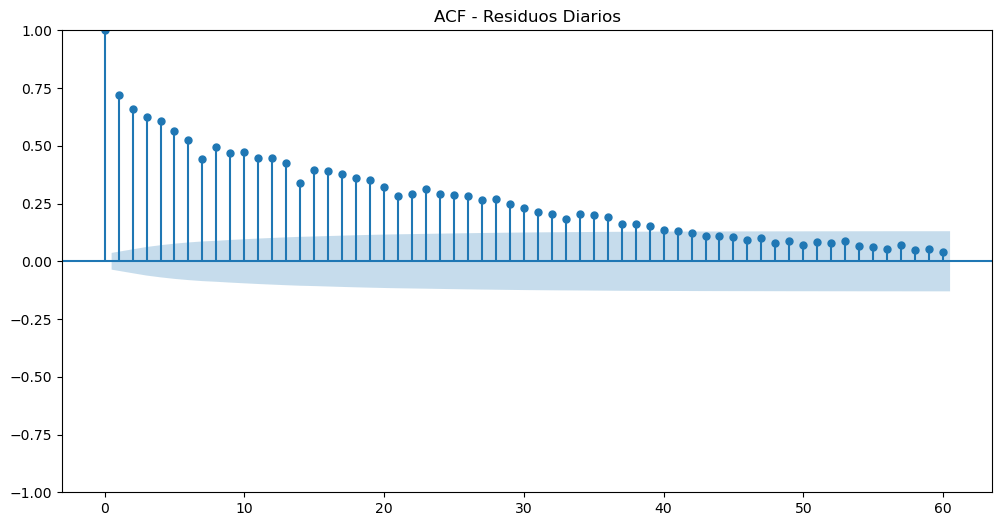

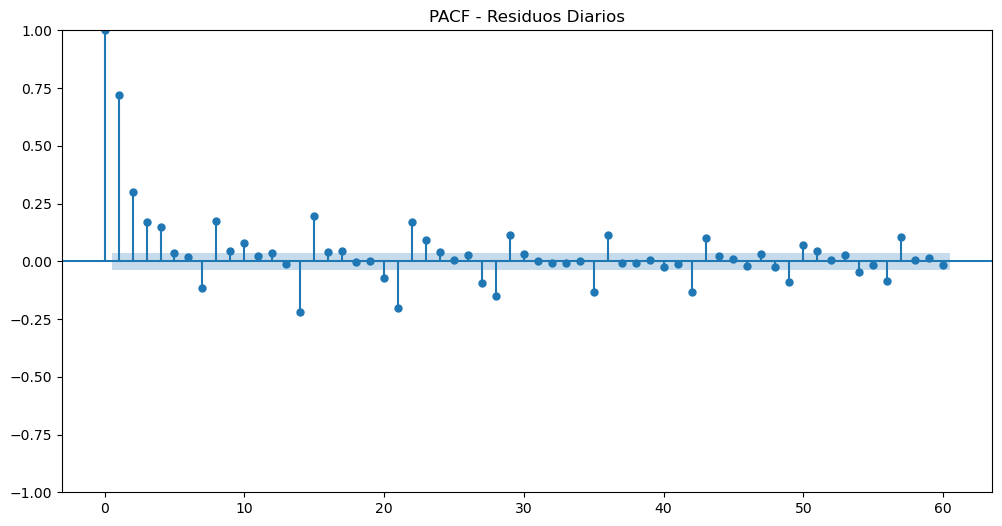

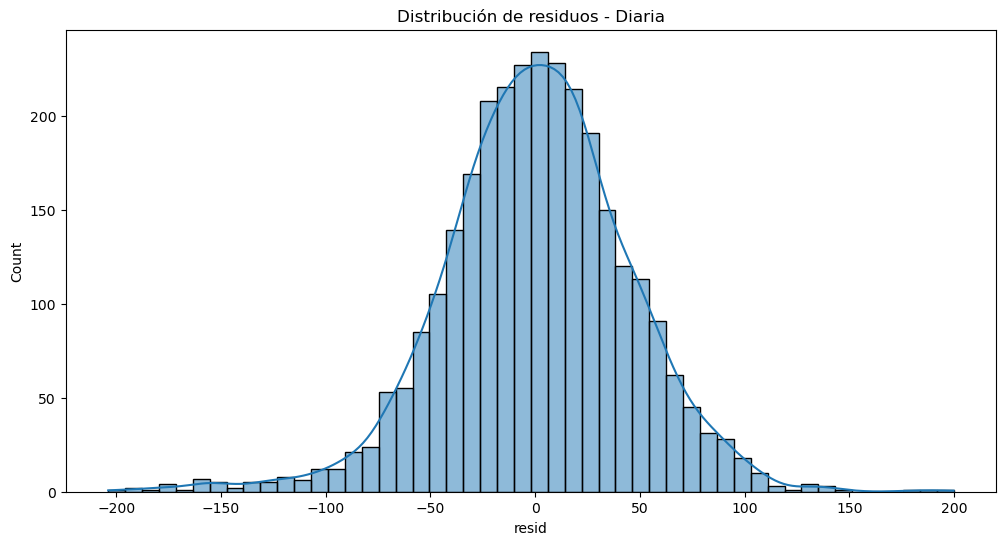

In [22]:
infracciones_por_dia = df_comparendos_electronicos_copy.groupby('fecha_comparendo')['CANTIDAD_INFRACCIONES'].sum().sort_index()

serie_diaria = infracciones_por_dia.copy()
serie_diaria.index = pd.to_datetime(serie_diaria.index)
serie_diaria = serie_diaria.asfreq('D')
serie_diaria = serie_diaria.fillna(0)

descomposicion_diaria = MSTL(serie_diaria, periods=[7, 365]).fit()

tendencia_diaria = descomposicion_diaria.trend.dropna()
max_tendencia_diaria = tendencia_diaria.max()
max_fecha_tendencia_diaria = tendencia_diaria.idxmax()
min_tendencia_diaria = tendencia_diaria.min()
min_fecha_tendencia_diaria = tendencia_diaria.idxmin()

x = np.arange(len(tendencia_diaria))
pendiente_diaria, intercepto_diaria, r_value_diaria, p_valor_tendencia_diaria, std_err_diaria = stats.linregress(x, tendencia_diaria.values)
r_cuadrado_diaria = r_value_diaria ** 2
regresion_vals_diaria = pendiente_diaria * x + intercepto_diaria

fig_tendencia_diaria = go.Figure()
fig_tendencia_diaria.add_trace(go.Scatter(x=tendencia_diaria.index, y=tendencia_diaria.values, mode='lines', name='Tendencia', line=dict(color='cornflowerblue', width=2), hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>', showlegend=False))
fig_tendencia_diaria.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_diaria.sum()):,}', showlegend=True))
fig_tendencia_diaria.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(tendencia_diaria.std()):,}', showlegend=True))
fig_tendencia_diaria.add_trace(go.Scatter(x=[tendencia_diaria.index[0], tendencia_diaria.index[-1]], y=[tendencia_diaria.mean(), tendencia_diaria.mean()], mode='lines', name=f'Promedio: {int(tendencia_diaria.mean()):,}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_tendencia_diaria.add_trace(go.Scatter(x=tendencia_diaria.index, y=regresion_vals_diaria, mode='lines', name=f'Regresión lineal (R² = {r_cuadrado_diaria:.3f})', line=dict(color='orange', width=2, dash='solid'), showlegend=True))
fig_tendencia_diaria.add_trace(go.Scatter(x=[max_fecha_tendencia_diaria], y=[max_tendencia_diaria], mode='markers', name=f'Máximo: {max_fecha_tendencia_diaria.strftime("%Y-%m-%d")} ({int(max_tendencia_diaria):,})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_tendencia_diaria.add_trace(go.Scatter(x=[min_fecha_tendencia_diaria], y=[min_tendencia_diaria], mode='markers', name=f'Mínimo: {min_fecha_tendencia_diaria.strftime("%Y-%m-%d")} ({int(min_tendencia_diaria):,})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_tendencia_diaria.add_vrect(x0="2020-03-01", x1="2020-12-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_tendencia_diaria.update_layout(title=dict(text='Tendencia de Comparendos Electrónicos (Diaria)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_tendencia_diaria.show()

print(f"Pendiente: {pendiente_diaria:.4f} comparendos por día")
print(f"Pendiente anual: {pendiente_diaria * 365:.2f} comparendos por año")
print(f"R²: {r_cuadrado_diaria:.6f}")
print(f"P-valor tendencia: {p_valor_tendencia_diaria:.6e}")
print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia_diaria < 0.05 else 'No'}")

estacionalidad_semanal = descomposicion_diaria.seasonal['seasonal_7'].dropna()
amplitud_estacional_semanal = estacionalidad_semanal.max() - estacionalidad_semanal.min()
var_total_diaria = serie_diaria.var()
varianza_estacional_semanal = estacionalidad_semanal.var() / var_total_diaria * 100

fig_estacionalidad_semanal = go.Figure()
fig_estacionalidad_semanal.add_trace(go.Scatter(x=estacionalidad_semanal.index, y=estacionalidad_semanal.values, mode='lines', name='Estacionalidad Semanal', line=dict(color='cornflowerblue', width=1), hovertemplate='Fecha: %{x}<br>Estacionalidad Semanal: %{y:,.2f}<extra></extra>', showlegend=False))
fig_estacionalidad_semanal.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_diaria.sum()):,}', showlegend=True))
fig_estacionalidad_semanal.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_semanal.std()):.0f}', showlegend=True))
fig_estacionalidad_semanal.add_trace(go.Scatter(x=[estacionalidad_semanal.index[0], estacionalidad_semanal.index[-1]], y=[estacionalidad_semanal.mean(), estacionalidad_semanal.mean()], mode='lines', name=f'Promedio: {estacionalidad_semanal.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_estacionalidad_semanal.add_vrect(x0="2020-03-01", x1="2020-12-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_estacionalidad_semanal.update_layout(title=dict(text='Estacionalidad Semanal de Comparendos (Diaria)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad Semanal (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_estacionalidad_semanal.show()

print(f"Amplitud estacional semanal: {amplitud_estacional_semanal:.0f} comparendos")
print(f"Variabilidad explicada por estacionalidad semanal: {varianza_estacional_semanal:.2f}%")


estacionalidad_anual = descomposicion_diaria.seasonal['seasonal_365'].dropna()
amplitud_estacional_anual = estacionalidad_anual.max() - estacionalidad_anual.min()
varianza_estacional_anual = descomposicion_diaria.seasonal['seasonal_365'].var() / var_total_diaria * 100

fig_estacionalidad_anual = go.Figure()
fig_estacionalidad_anual.add_trace(go.Scatter(x=estacionalidad_anual.index, y=estacionalidad_anual.values, mode='lines', name='Estacionalidad Anual', line=dict(color='cornflowerblue', width=1), hovertemplate='Fecha: %{x}<br>Estacionalidad Anual: %{y:,.2f}<extra></extra>', showlegend=False))
fig_estacionalidad_anual.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_diaria.sum()):,}', showlegend=True))
fig_estacionalidad_anual.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_anual.std()):.0f}', showlegend=True))
fig_estacionalidad_anual.add_trace(go.Scatter(x=[estacionalidad_anual.index[0], estacionalidad_anual.index[-1]], y=[estacionalidad_anual.mean(), estacionalidad_anual.mean()], mode='lines', name=f'Promedio: {estacionalidad_anual.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_estacionalidad_anual.add_vrect(x0="2020-03-01", x1="2020-12-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_estacionalidad_anual.update_layout(title=dict(text='Estacionalidad Anual de Comparendos (Diaria)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad Anual (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_estacionalidad_anual.show()

print(f"Amplitud estacional anual: {amplitud_estacional_anual:.0f} comparendos")
print(f"Variabilidad explicada por estacionalidad anual: {varianza_estacional_anual:.2f}%")


print("\nPrueba ADF sobre la serie original (Diaria)")
resultado_adf_original_diaria = adfuller(serie_diaria.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_original_diaria[0]:.6f}")
print(f"P-valor: {resultado_adf_original_diaria[1]:.6e}")
print("Valores críticos:")
for key, value in resultado_adf_original_diaria[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_original_diaria[1] < 0.05:
    print("La serie original es estacionaria")
else:
    print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")

print("\nPrueba ADF sobre los residuos (Diaria)")
resultado_adf_residuos_diaria = adfuller(descomposicion_diaria.resid.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_residuos_diaria[0]:.6f}")
print(f"P-valor: {resultado_adf_residuos_diaria[1]:.6e}")
print("Valores críticos:")
for key, value in resultado_adf_residuos_diaria[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_residuos_diaria[1] < 0.05:
    print("Los residuos son estacionarios")
else:
    print("Los residuos no son estacionarios")

if resultado_adf_original_diaria[1] >= 0.05 and resultado_adf_residuos_diaria[1] < 0.05:
    print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición MSTL capturó correctamente tendencia y estacionalidad")
elif resultado_adf_original_diaria[1] < 0.05 and resultado_adf_residuos_diaria[1] < 0.05:
    print("\nTanto la serie original como los residuos son estacionarios")
else:
    print("\nLa descomposición no logró eliminar completamente la no estacionariedad")


residuos_diarios = descomposicion_diaria.resid.dropna()
p_valor_ljung_diaria = acorr_ljungbox(residuos_diarios, lags=[30], return_df=True)['lb_pvalue'].iloc[0]
t_stat_diaria, p_valor_media_diaria = stats.ttest_1samp(residuos_diarios, 0)

fig_residuos_diarios = go.Figure()
fig_residuos_diarios.add_trace(go.Scatter(x=residuos_diarios.index, y=residuos_diarios.values, mode='lines', name='Residuos', line=dict(color='cornflowerblue', width=1), hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False))
fig_residuos_diarios.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_diaria.sum()):,}', showlegend=True))
fig_residuos_diarios.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(residuos_diarios.std()):.0f}', showlegend=True))
fig_residuos_diarios.add_trace(go.Scatter(x=[residuos_diarios.index[0], residuos_diarios.index[-1]], y=[residuos_diarios.mean(), residuos_diarios.mean()], mode='lines', name=f'Promedio: {residuos_diarios.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_residuos_diarios.add_vrect(x0="2020-03-01", x1="2020-12-31", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_residuos_diarios.update_layout(title=dict(text='Residuos de Comparendos Electrónicos (Diaria)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Residuos (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_residuos_diarios.show()

resultado_ljung_diaria = acorr_ljungbox(residuos_diarios, lags=[7, 30, 60], return_df=True)
print("\nPrueba Ljung-Box (Diaria)")
for lag in [7, 30, 60]:
    p_valor = resultado_ljung_diaria.loc[lag, 'lb_pvalue']
    if p_valor < 0.0001:
        print(f"Lag {lag}: p-valor < 0.0001")
    else:
        print(f"Lag {lag}: p-valor = {p_valor:.6f}")

p_valor_ljung_diaria = resultado_ljung_diaria.loc[30, 'lb_pvalue']
print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung_diaria > 0.05 else 'No'}")
print(f"Prueba t (media cero) p-valor: {p_valor_media_diaria:.6e}")
print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media_diaria > 0.05 else 'No'}")

stat_diaria, p_shapiro_diaria = stats.shapiro(residuos_diarios[:5000])
print(f"\nShapiro-Wilk p-valor (primeras 5000 muestras): {p_shapiro_diaria:.6e}")
print(f"¿Residuos normales? {'Sí' if p_shapiro_diaria > 0.05 else 'No'}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuos_diarios, ax=ax, lags=60)
plt.title("ACF - Residuos Diarios")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(residuos_diarios, ax=ax, lags=60)
plt.title("PACF - Residuos Diarios")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(residuos_diarios, bins=50, kde=True)
plt.title("Distribución de residuos - Diaria")
plt.show()

- **Análisis de tendencia**: La pendiente negativa de -0.0100 comparendos por día indica una disminución promedio diaria estadísticamente significativa (p-valor < 0.0001). Esta disminución se traduce en una reducción anual de **-3.65 comparendos por año**. El R² de 4.3% muestra que la tendencia lineal explica una pequeña parte de la variabilidad total, aunque la relación es altamente significativa. La prueba de Durbin-Watson con un valor prácticamente nulo (0.000001) indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que la tendencia lineal no captura adecuadamente toda la estructura temporal diaria y que existen patrones sistemáticos no lineales en la evolución de largo plazo. Se confirma una disminución sostenida y estadísticamente significativa en el volumen de comparendos electrónicos a nivel diario a lo largo del tiempo, coherente con la tendencia negativa observada en los análisis mensuales.

- **Estacionalidad semanal (ciclo de 7 días)**: Explica el **10.98%** de la variabilidad total de la serie diaria. La amplitud de **166 comparendos** representa la oscilación promedio entre el día de mayor y menor actividad dentro de la semana. Este componente captura las diferencias sistemáticas entre días laborales y fines de semana, confirmando cuantitativamente que el domingo es el día de menor actividad y el viernes el de mayor actividad, como se observó en el análisis por día de la semana.

- **Estacionalidad anual (ciclo de 365 días)**: Explica el **12.75%** de la variabilidad total, ligeramente superior al componente semanal. La amplitud de **261 comparendos** representa la oscilación entre los meses de mayor y menor actividad a lo largo del año, capturando efectos estacionales como festividades, cambios climáticos o períodos vacacionales.

- **Comparativa de componentes estacionales**: La estacionalidad anual tiene un peso ligeramente mayor (12.75%) que la semanal (10.98%), lo que indica que los patrones anuales (como diciembre o marzo) tienen un impacto ligeramente más relevante que los patrones semanales en la variabilidad de los comparendos diarios. Sin embargo, ambos componentes son moderados, lo que sugiere que la mayor parte de la variabilidad de la serie se debe a componentes irregulares o eventos atípicos.

- **Análisis de estacionariedad**: La prueba ADF sobre la serie original arroja un estadístico de -3.584 con un p-valor de 0.0061, lo que permite rechazar la hipótesis de raíz unitaria. Esto indica que **la serie original diaria ya es estacionaria** (a diferencia de la serie mensual que no lo era), es decir, su media y varianza son constantes en el tiempo. Por su parte, la prueba ADF sobre los residuos también confirma la estacionariedad (estadístico de -6.092 con p-valor < 0.0001). Tanto la serie original como los residuos son estacionarios, lo que indica que la serie diaria tiene un comportamiento más estable y predecible que la serie mensual, posiblemente debido a la mayor frecuencia de datos que promedia los efectos atípicos.

- **Análisis de residuos** Los residuos **no son ruido blanco**, como lo evidencian los p-valores extremadamente bajos (< 0.0001) en la prueba Ljung-Box para los rezagos 7, 30 y 60. Esto indica que el modelo de descomposición MSTL no logra capturar toda la estructura presente en la serie temporal diaria. Existen patrones, autocorrelaciones o dependencias temporales que no son explicadas ni por la tendencia, ni por la estacionalidad semanal, ni por la estacionalidad anual. Estos patrones remanentes podrían corresponder a efectos de eventos específicos (cierres viales, festividades atípicas, condiciones climáticas extremas), cambios en la operación del sistema de cámaras, o factores externos no considerados en el modelo. Por otro lado, el hecho de que los residuos estén centrados en cero (p-valor t-test = 0.5226) es positivo, ya que indica que el modelo no tiene un sesgo sistemático sobreestimando o subestimando consistentemente los valores. Sin embargo, la prueba de Shapiro-Wilk con un p-valor extremadamente bajo (< 0.0001) indica que los residuos no siguen una distribución normal, lo que es común en series de alta frecuencia con alta presencia de ceros y valores atípicos.

- **Gráfico de autocorrelación (ACF)**: El ACF mide la correlación entre los residuos y sus versiones rezagadas en el tiempo. Se observa un decaimiento muy lento y persistente, donde la mayoría de las barras (lags) se encuentran significativamente por encima de la franja azul (intervalo de confianza). Esto indica una fuerte autocorrelación serial, lo que significa que el modelo MSTL no ha logrado capturar toda la estructura de la serie temporal diaria. Existe información "atrapada" en los residuos que un modelo de series de tiempo más avanzado (como un ARIMA o SARIMA aplicado a estos residuos) podría aprovechar. En consecuencia, los residuos no son "ruido blanco" y el modelo actual presenta un sesgo sistemático en el tiempo.


- **Gráfico de autocorrelación parcial (PACF)**: El PACF ayuda a identificar la correlación directa entre un lag y el valor actual, eliminando la influencia de los lags intermedios. Se observan picos significativos en los primeros lags (especialmente el lag 1 y 2), así como picos recurrentes (estacionales) alrededor de los lags 7, 14, 21, etc. La presencia de picos en múltiplos de 7 sugiere que aún queda estacionalidad semanal no completamente corregida por el modelo MSTL. Por otro lado, el pico fuerte en el lag 1 indica que el valor de hoy todavía depende fuertemente del valor de ayer, evidenciando una dependencia temporal de corto plazo no capturada.

- **Gráfico de la distribución de residuos**: Este gráfico muestra si los errores siguen una distribución normal. La forma es acampanada y está centrada en cero, lo cual es positivo. Sin embargo, se observan "colas pesadas" (especialmente hacia la izquierda, con valores negativos cercanos a -200) y algunos valores atípicos. Aunque la distribución se asemeja a una normal, la persistencia vista en el ACF sugiere que esta aparente normalidad es engañosa, ya que los errores no son independientes entre sí. La media cercana a cero indica que el modelo no sobreestima ni subestima de forma masiva en promedio, pero los errores son predecibles, lo que confirma que el modelo actual no es óptimo para propósitos predictivos.

---

**Hallazgos**:

- Aunque la magnitud es pequeña (-0.01 comparendos por día, -3.65 por año), la tendencia es altamente significativa (p-valor < 0.0001), confirmando una disminución sostenida en el volumen de comparendos electrónicos a lo largo del tiempo, consistente con el análisis mensual.

- Con un 12.75% vs 10.98%, los patrones anuales (meses del año) explican ligeramente más variabilidad que los patrones semanales (días de la semana), aunque ambos son moderados.

- A diferencia de la serie mensual que requería descomposición para volverse estacionaria, la serie diaria ya cumple con esta propiedad, lo que sugiere que los datos de mayor frecuencia tienen un comportamiento más estable y predecible.

- La inclusión de la estacionalidad semanal permite explicar un mayor porcentaje de la variabilidad total (23.73% combinado) en comparación con el análisis mensual (solo 3.6% de estacionalidad anual), demostrando la ventaja de usar descomposición múltiple para datos de alta frecuencia.

## Descomposición de la Serie Temporal Mensual por Tipo de Cámara

A continuación, se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a las series temporales mensuales de comparendos electrónicos para las cámaras fijas y móviles, excluyendo las cámaras de tipo Carril Bus debido a que su período de operación es insuficiente (exactamente tres meses), lo que no permite identificar patrones estacionales ni tendencias significativas.

### Descomposición de la Serie Temporal Mensual - Cámara Fija

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a la serie temporal mensual de comparendos electrónicos exclusivamente para las cámaras fijas, con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis permite comprender la dinámica subyacente de los comparendos detectados por cámaras fijas, identificar si existe una tendencia creciente o decreciente en el tiempo, cuantificar la fuerza de los patrones estacionales específicos de este tipo de tecnología, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de la serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas.

Pendiente: -9.84 comparendos por mes
R²: 0.095508
P-valor tendencia: 0.002186
¿Tendencia significativa? Sí


Amplitud estacional: 1952 comparendos
Variabilidad explicada por estacionalidad: 10.34%

Prueba ADF sobre la serie original (Cámaras Fijas)
Estadístico ADF: -2.577285
P-valor: 9.778346e-02
Valores críticos:
  1%: -3.5019
  5%: -2.8928
  10%: -2.5835
La serie original no es estacionaria (tiene tendencia y/o estacionalidad)

Prueba ADF sobre los residuos (Cámaras Fijas)
Estadístico ADF: -6.911823
P-valor: 1.206921e-09
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

La serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad



Prueba Ljung-Box (Cámaras Fijas)
      lb_stat  lb_pvalue
6   15.333763   0.017814
12  32.999919   0.000968
18  42.254608   0.001019

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.259088
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 1.875148e-08
¿Residuos normales? No


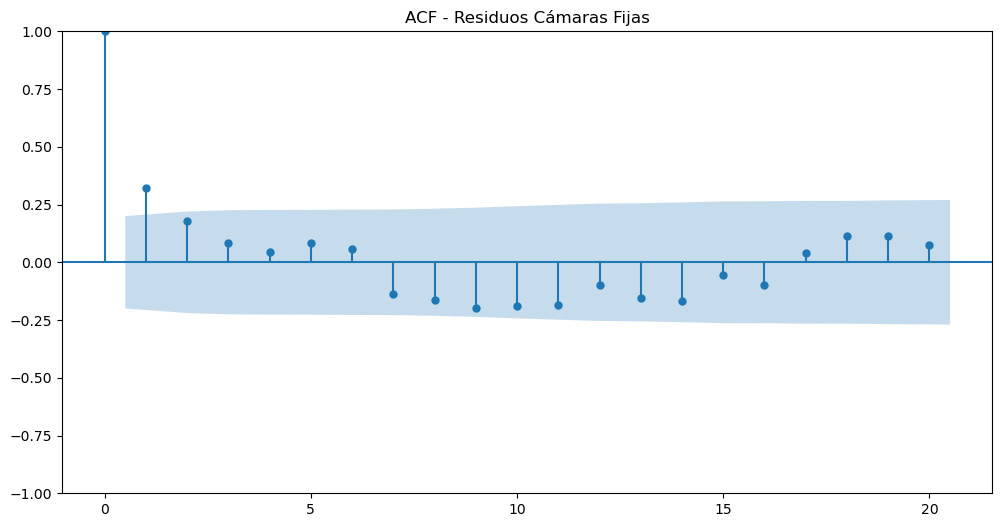

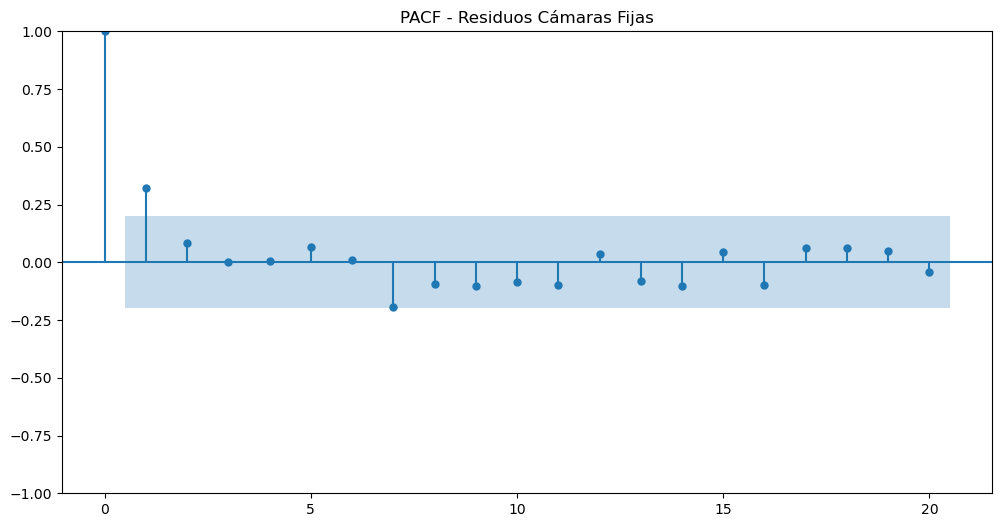

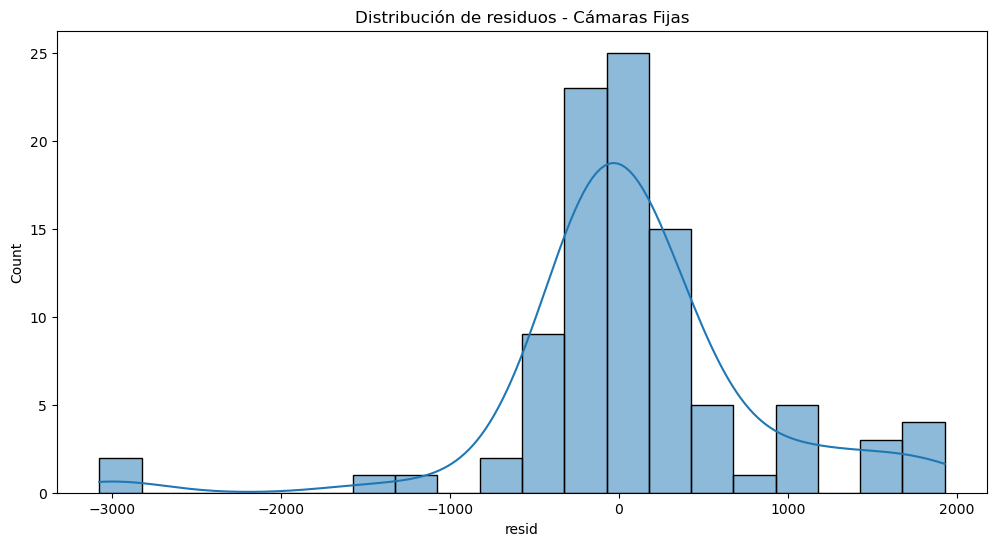

In [23]:
infracciones_por_mes_camara = df_comparendos_electronicos_copy.groupby(['año_mes', 'Tipo Camara'])['CANTIDAD_INFRACCIONES'].sum().reset_index()

serie_fijo = infracciones_por_mes_camara[infracciones_por_mes_camara['Tipo Camara'] == 'Fijo'].copy()
serie_fijo = serie_fijo.set_index('año_mes')['CANTIDAD_INFRACCIONES']
serie_fijo.index = pd.to_datetime(serie_fijo.index)
serie_fijo = serie_fijo.asfreq('MS')
serie_fijo = serie_fijo.fillna(0)

descomposicion_fijo = STL(serie_fijo, period=12, robust=True).fit()

tendencia_fijo = descomposicion_fijo.trend.dropna()
x = np.arange(len(tendencia_fijo))
pendiente_fijo, intercepto_fijo, r_value_fijo, p_valor_tendencia_fijo, std_err_fijo = stats.linregress(x, tendencia_fijo.values)
r_cuadrado_fijo = r_value_fijo ** 2
regresion_vals_fijo = pendiente_fijo * x + intercepto_fijo

fig_tendencia_fijo = go.Figure()
fig_tendencia_fijo.add_trace(go.Scatter(x=tendencia_fijo.index, y=tendencia_fijo.values, mode='lines+markers', name='Tendencia', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>', showlegend=False))
fig_tendencia_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_fijo.sum()):,}', showlegend=True))
fig_tendencia_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(tendencia_fijo.std()):,}', showlegend=True))
fig_tendencia_fijo.add_trace(go.Scatter(x=[tendencia_fijo.index[0], tendencia_fijo.index[-1]], y=[tendencia_fijo.mean(), tendencia_fijo.mean()], mode='lines', name=f'Promedio: {int(tendencia_fijo.mean()):,}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_tendencia_fijo.add_trace(go.Scatter(x=tendencia_fijo.index, y=regresion_vals_fijo, mode='lines', name=f'Regresión lineal (R² = {r_cuadrado_fijo:.3f})', line=dict(color='orange', width=2, dash='solid'), showlegend=True))
fig_tendencia_fijo.add_trace(go.Scatter(x=[tendencia_fijo.idxmax()], y=[tendencia_fijo.max()], mode='markers', name=f'Máximo: {tendencia_fijo.idxmax().strftime("%Y-%m")} ({int(tendencia_fijo.max()):,})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_tendencia_fijo.add_trace(go.Scatter(x=[tendencia_fijo.idxmin()], y=[tendencia_fijo.min()], mode='markers', name=f'Mínimo: {tendencia_fijo.idxmin().strftime("%Y-%m")} ({int(tendencia_fijo.min()):,})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_tendencia_fijo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_tendencia_fijo.update_layout(title=dict(text='Tendencia de Comparendos - Cámaras Fijas (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_tendencia_fijo.show()

print(f"Pendiente: {pendiente_fijo:.2f} comparendos por mes")
print(f"R²: {r_cuadrado_fijo:.6f}")
print(f"P-valor tendencia: {p_valor_tendencia_fijo:.6f}")
print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia_fijo < 0.05 else 'No'}")


estacionalidad_fijo = descomposicion_fijo.seasonal.dropna()
amplitud_estacional_fijo = estacionalidad_fijo.max() - estacionalidad_fijo.min()
var_total_fijo = descomposicion_fijo.trend.var() + descomposicion_fijo.seasonal.var() + descomposicion_fijo.resid.var()
varianza_estacional_fijo = descomposicion_fijo.seasonal.var() / var_total_fijo * 100

fig_estacionalidad_fijo = go.Figure()
fig_estacionalidad_fijo.add_trace(go.Scatter(x=estacionalidad_fijo.index, y=estacionalidad_fijo.values, mode='lines+markers', name='Estacionalidad', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Estacionalidad: %{y:,.2f}<extra></extra>', showlegend=False))
fig_estacionalidad_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_fijo.sum()):,}', showlegend=True))
fig_estacionalidad_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_fijo.std()):.0f}', showlegend=True))
fig_estacionalidad_fijo.add_trace(go.Scatter(x=[estacionalidad_fijo.index[0], estacionalidad_fijo.index[-1]], y=[estacionalidad_fijo.mean(), estacionalidad_fijo.mean()], mode='lines', name=f'Promedio: {estacionalidad_fijo.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_estacionalidad_fijo.add_trace(go.Scatter(x=[estacionalidad_fijo.idxmax()], y=[estacionalidad_fijo.max()], mode='markers', name=f'Máximo: {estacionalidad_fijo.idxmax().strftime("%Y-%m")} ({estacionalidad_fijo.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_estacionalidad_fijo.add_trace(go.Scatter(x=[estacionalidad_fijo.idxmin()], y=[estacionalidad_fijo.min()], mode='markers', name=f'Mínimo: {estacionalidad_fijo.idxmin().strftime("%Y-%m")} ({estacionalidad_fijo.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_estacionalidad_fijo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_estacionalidad_fijo.update_layout(title=dict(text='Estacionalidad de Comparendos - Cámaras Fijas (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_estacionalidad_fijo.show()

print(f"Amplitud estacional: {amplitud_estacional_fijo:.0f} comparendos")
print(f"Variabilidad explicada por estacionalidad: {varianza_estacional_fijo:.2f}%")

print("\nPrueba ADF sobre la serie original (Cámaras Fijas)")
resultado_adf_original_fijo = adfuller(serie_fijo.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_original_fijo[0]:.6f}")
print(f"P-valor: {resultado_adf_original_fijo[1]:.6e}")
print("Valores críticos:")
for key, value in resultado_adf_original_fijo[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_original_fijo[1] < 0.05:
    print("La serie original es estacionaria")
else:
    print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")

print("\nPrueba ADF sobre los residuos (Cámaras Fijas)")
resultado_adf_residuos_fijo = adfuller(descomposicion_fijo.resid.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_residuos_fijo[0]:.6f}")
print(f"P-valor: {resultado_adf_residuos_fijo[1]:.6e}")
print("Valores críticos:")
for key, value in resultado_adf_residuos_fijo[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_residuos_fijo[1] < 0.05:
    print("Los residuos son estacionarios")
else:
    print("Los residuos no son estacionarios")

if resultado_adf_original_fijo[1] >= 0.05 and resultado_adf_residuos_fijo[1] < 0.05:
    print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad")
elif resultado_adf_original_fijo[1] < 0.05 and resultado_adf_residuos_fijo[1] < 0.05:
    print("\nTanto la serie original como los residuos son estacionarios")
else:
    print("\nLa descomposición no logró eliminar completamente la no estacionariedad")

residuos_fijo = descomposicion_fijo.resid.dropna()
p_valor_ljung_fijo = acorr_ljungbox(residuos_fijo, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
t_stat_fijo, p_valor_media_fijo = stats.ttest_1samp(residuos_fijo, 0)

fig_residuos_fijo = go.Figure()
fig_residuos_fijo.add_trace(go.Scatter(x=residuos_fijo.index, y=residuos_fijo.values, mode='lines+markers', name='Residuos', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False))
fig_residuos_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_fijo.sum()):,}', showlegend=True))
fig_residuos_fijo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(residuos_fijo.std()):.0f}', showlegend=True))
fig_residuos_fijo.add_trace(go.Scatter(x=[residuos_fijo.index[0], residuos_fijo.index[-1]], y=[residuos_fijo.mean(), residuos_fijo.mean()], mode='lines', name=f'Promedio: {residuos_fijo.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_residuos_fijo.add_trace(go.Scatter(x=[residuos_fijo.idxmax()], y=[residuos_fijo.max()], mode='markers', name=f'Máximo: {residuos_fijo.idxmax().strftime("%Y-%m")} ({residuos_fijo.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_residuos_fijo.add_trace(go.Scatter(x=[residuos_fijo.idxmin()], y=[residuos_fijo.min()], mode='markers', name=f'Mínimo: {residuos_fijo.idxmin().strftime("%Y-%m")} ({residuos_fijo.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_residuos_fijo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_residuos_fijo.update_layout(title=dict(text='Residuos de Comparendos - Cámaras Fijas (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Residuos (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_residuos_fijo.show()

resultado_ljung_fijo = acorr_ljungbox(residuos_fijo, lags=[6, 12, 18], return_df=True)
print("\nPrueba Ljung-Box (Cámaras Fijas)")
print(resultado_ljung_fijo)
p_valor_ljung_fijo = resultado_ljung_fijo['lb_pvalue'].iloc[1]
print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung_fijo > 0.05 else 'No'}")
print(f"Prueba t (media cero) p-valor: {p_valor_media_fijo:.6f}")
print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media_fijo > 0.05 else 'No'}")

stat_fijo, p_shapiro_fijo = stats.shapiro(residuos_fijo)
print(f"\nShapiro-Wilk p-valor: {p_shapiro_fijo:.6e}")
print(f"¿Residuos normales? {'Sí' if p_shapiro_fijo > 0.05 else 'No'}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuos_fijo, ax=ax)
plt.title("ACF - Residuos Cámaras Fijas")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(residuos_fijo, ax=ax)
plt.title("PACF - Residuos Cámaras Fijas")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(residuos_fijo, bins=20, kde=True)
plt.title("Distribución de residuos - Cámaras Fijas")
plt.show()

- **Análisis de tendencia**: La pendiente negativa de -9.84 comparendos por mes indica una disminución promedio mensual estadísticamente significativa (p-valor = 0.0022). El R² de 9.6% muestra que la tendencia lineal explica una pequeña parte de la variabilidad total, pero la relación es significativa. La prueba de Durbin-Watson con un valor de 0.0007 indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que la tendencia lineal no captura adecuadamente toda la estructura temporal y que existen patrones sistemáticos no lineales en la evolución de largo plazo de las cámaras fijas. A pesar de ello, se confirma una disminución sostenida en el volumen de comparendos detectados por cámaras fijas a lo largo del tiempo.

- **Análisis de estacionalidad**: La estacionalidad explica el 10.34% de la variabilidad total de las cámaras fijas, lo que indica que presentan un patrón cíclico anual moderado, aunque ligeramente menor al observado en el total general (12.6%). La amplitud de 1,952 comparendos representa una oscilación considerable a lo largo del año, lo que sugiere que existen meses con mayor actividad estacional que influyen en el volumen de infracciones detectadas por este tipo de tecnología, aunque la mayor parte de la variabilidad sigue siendo explicada por otros componentes.

- **Análisis de estacionariedad**: La prueba ADF sobre la serie original de cámaras fijas arroja un estadístico de -2.577 con un p-valor de 0.0978, ligeramente por encima del umbral de 0.05. Esto indica que la serie original no es estacionaria, es decir, presenta tendencia y/o estacionalidad que deben ser removidas. Por el contrario, la prueba ADF sobre los residuos arroja un estadístico de -6.912 con un p-valor prácticamente cero (1.2e-09), lo que confirma que los residuos son estacionarios.

- **Análisis de residuos**: Los residuos no son ruido blanco, como lo evidencian los p-valores en la prueba Ljung-Box (0.0178 para el rezago 6, 0.00097 para el rezago 12 y 0.0010 para el rezago 18). Esto indica que el modelo de descomposición STL para cámaras fijas no logra capturar toda la estructura presente en la serie temporal. Existen patrones, autocorrelaciones o dependencias temporales que no son explicadas ni por la tendencia ni por la estacionalidad. Estos patrones remanentes podrían corresponder a efectos de eventos específicos (cierres viales, pandemia, inauguraciones) o cambios en la operación del sistema de cámaras fijas. Por otro lado, el hecho de que los residuos estén centrados en cero (p-valor de 0.2591) es positivo, ya que indica que el modelo no tiene un sesgo sistemático sobreestimando o subestimando consistentemente los valores. Sin embargo, la prueba de Shapiro-Wilk con un p-valor extremadamente bajo (1.88e-08) indica que los residuos no siguen una distribución normal, lo que sugiere que el modelo podría beneficiarse de transformaciones adicionales o de enfoques no paramétricos para capturar mejor la estructura de los datos de las cámaras fijas.


---

- **Gráfico de ACF (Autocorrelación)**: Este gráfico indica si los errores del modelo están relacionados con los de períodos pasados. El **lag 1** sobresale claramente del área azul, lo que indica una correlación positiva significativa, y el **lag 2** también roza el límite de significancia. Esto confirma que el modelo aún no ha extraído toda la información de la serie, existiendo una dependencia de "corto plazo" en los residuos. Al ser positivo el lag 1, el modelo tiende a cometer el mismo tipo de error (subestimar o sobreestimar) de forma consecutiva, lo que sugiere la necesidad de incluir componentes autorregresivos o mejorar la especificación del modelo.

- **Gráfico de PACF (Autocorrelación Parcial)**: Este gráfico ayuda a identificar el orden de un posible componente Autorregresivo (AR). Al igual que en el ACF, el **lag 1** es significativo, lo que refuerza la necesidad de un componente **AR(1)**. Sin embargo, lo más llamativo es el **lag 7**, que sobresale de la banda de confianza hacia el lado negativo.

- **Gráfico de la distribución de residuos**: La distribución está muy bien centrada en **0**, lo cual es un éxito para el modelo: en promedio, las predicciones son correctas y no hay un sesgo sistemático significativo. La mayoría de los residuos se concentran entre -500 y 500, pero se observan "colas largas": hacia la izquierda se alcanzan valores de -3000 y hacia la derecha de casi 2000. Estos valores extremos indican meses atípicos donde el flujo de comparendos electrónicos detectados por cámaras fijas se disparó o cayó drásticamente de forma impredecible para el modelo actual, correspondiendo probablemente a eventos como los cierres viales de 2019 o la pandemia de 2020.

### Descomposición de la Serie Temporal Mensual - Cámara Movil

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a la serie temporal mensual de comparendos electrónicos exclusivamente para las cámaras móviles, con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis permite comprender la dinámica subyacente de los comparendos detectados por cámaras móviles, identificar si existe una tendencia creciente o decreciente en el tiempo, cuantificar la fuerza de los patrones estacionales específicos de este tipo de tecnología, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de la serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas.

Pendiente: -2.09 comparendos por mes
R²: 0.012483
P-valor tendencia: 0.278469
¿Tendencia significativa? No


Amplitud estacional: 1101 comparendos
Variabilidad explicada por estacionalidad: 5.17%

Prueba ADF sobre la serie original (Cámaras Móviles)
Estadístico ADF: -3.560229
P-valor: 0.006568
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos (Cámaras Móviles)
Estadístico ADF: -4.515149
P-valor: 0.000185
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box (Cámaras Móviles)
       lb_stat     lb_pvalue
6    63.762370  7.716917e-12
12  101.820733  2.447211e-16
18  111.750463  1.484544e-15

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.279449
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 5.670809e-09
¿Residuos normales? No


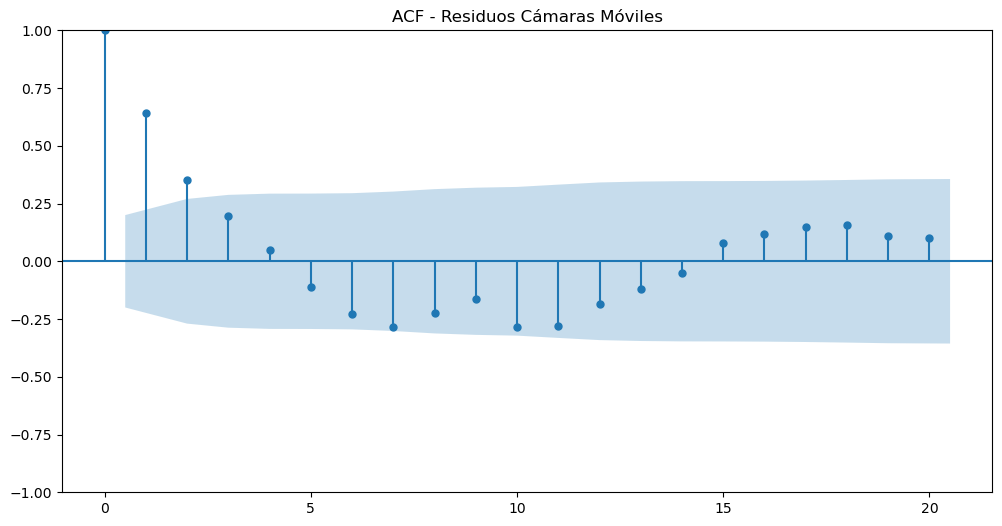

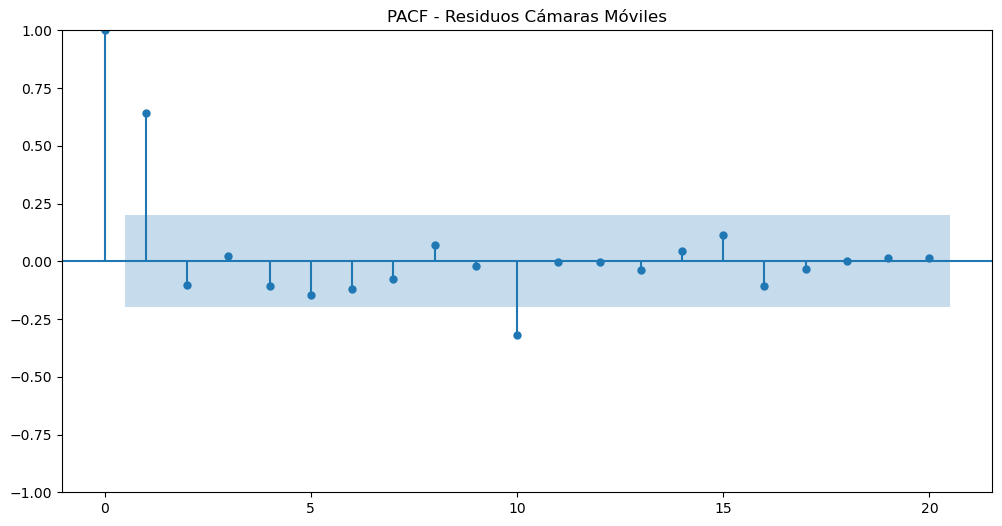

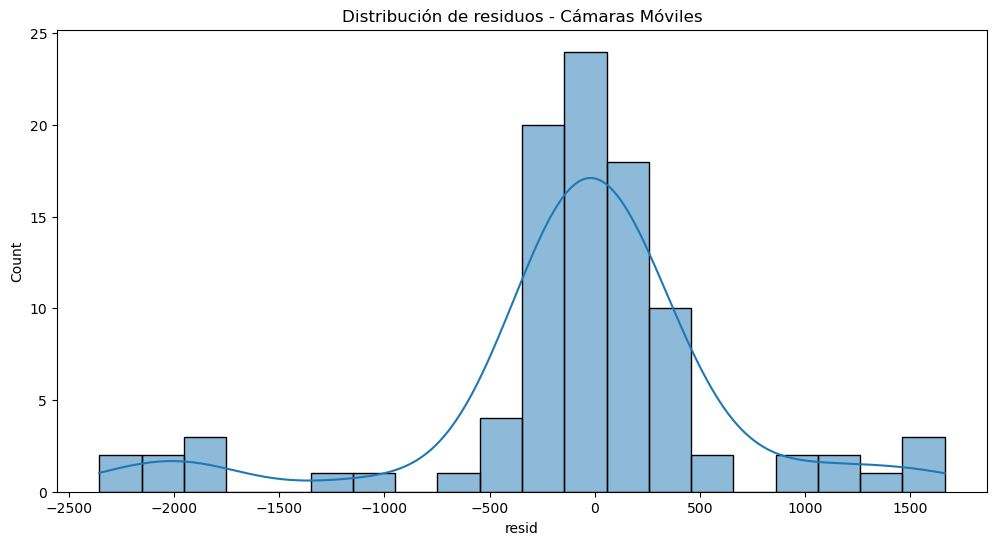

In [24]:
serie_movil = infracciones_por_mes_camara[infracciones_por_mes_camara['Tipo Camara'] == 'Movil'].copy()
serie_movil = serie_movil.set_index('año_mes')['CANTIDAD_INFRACCIONES']
serie_movil.index = pd.to_datetime(serie_movil.index)
serie_movil = serie_movil.asfreq('MS')
serie_movil = serie_movil.fillna(0)

descomposicion_movil = STL(serie_movil, period=12, robust=True).fit()

tendencia_movil = descomposicion_movil.trend.dropna()
x = np.arange(len(tendencia_movil))
pendiente_movil, intercepto_movil, r_value_movil, p_valor_tendencia_movil, std_err_movil = stats.linregress(x, tendencia_movil.values)
r_cuadrado_movil = r_value_movil ** 2
regresion_vals_movil = pendiente_movil * x + intercepto_movil

fig_tendencia_movil = go.Figure()
fig_tendencia_movil.add_trace(go.Scatter(x=tendencia_movil.index, y=tendencia_movil.values, mode='lines+markers', name='Tendencia', line=dict(color='mediumpurple', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>', showlegend=False))
fig_tendencia_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_movil.sum()):,}', showlegend=True))
fig_tendencia_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(tendencia_movil.std()):,}', showlegend=True))
fig_tendencia_movil.add_trace(go.Scatter(x=[tendencia_movil.index[0], tendencia_movil.index[-1]], y=[tendencia_movil.mean(), tendencia_movil.mean()], mode='lines', name=f'Promedio: {int(tendencia_movil.mean()):,}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_tendencia_movil.add_trace(go.Scatter(x=tendencia_movil.index, y=regresion_vals_movil, mode='lines', name=f'Regresión lineal (R² = {r_cuadrado_movil:.3f})', line=dict(color='orange', width=2, dash='solid'), showlegend=True))
fig_tendencia_movil.add_trace(go.Scatter(x=[tendencia_movil.idxmax()], y=[tendencia_movil.max()], mode='markers', name=f'Máximo: {tendencia_movil.idxmax().strftime("%Y-%m")} ({int(tendencia_movil.max()):,})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_tendencia_movil.add_trace(go.Scatter(x=[tendencia_movil.idxmin()], y=[tendencia_movil.min()], mode='markers', name=f'Mínimo: {tendencia_movil.idxmin().strftime("%Y-%m")} ({int(tendencia_movil.min()):,})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_tendencia_movil.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_tendencia_movil.update_layout(title=dict(text='Tendencia de Comparendos - Cámaras Móviles (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_tendencia_movil.show()

print(f"Pendiente: {pendiente_movil:.2f} comparendos por mes")
print(f"R²: {r_cuadrado_movil:.6f}")
print(f"P-valor tendencia: {p_valor_tendencia_movil:.6f}")
print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia_movil < 0.05 else 'No'}")

estacionalidad_movil = descomposicion_movil.seasonal.dropna()
amplitud_estacional_movil = estacionalidad_movil.max() - estacionalidad_movil.min()
var_total_movil = descomposicion_movil.trend.var() + descomposicion_movil.seasonal.var() + descomposicion_movil.resid.var()
varianza_estacional_movil = descomposicion_movil.seasonal.var() / var_total_movil * 100

fig_estacionalidad_movil = go.Figure()
fig_estacionalidad_movil.add_trace(go.Scatter(x=estacionalidad_movil.index, y=estacionalidad_movil.values, mode='lines+markers', name='Estacionalidad', line=dict(color='mediumpurple', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Estacionalidad: %{y:,.2f}<extra></extra>', showlegend=False))
fig_estacionalidad_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_movil.sum()):,}', showlegend=True))
fig_estacionalidad_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_movil.std()):.0f}', showlegend=True))
fig_estacionalidad_movil.add_trace(go.Scatter(x=[estacionalidad_movil.index[0], estacionalidad_movil.index[-1]], y=[estacionalidad_movil.mean(), estacionalidad_movil.mean()], mode='lines', name=f'Promedio: {estacionalidad_movil.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_estacionalidad_movil.add_trace(go.Scatter(x=[estacionalidad_movil.idxmax()], y=[estacionalidad_movil.max()], mode='markers', name=f'Máximo: {estacionalidad_movil.idxmax().strftime("%Y-%m")} ({estacionalidad_movil.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_estacionalidad_movil.add_trace(go.Scatter(x=[estacionalidad_movil.idxmin()], y=[estacionalidad_movil.min()], mode='markers', name=f'Mínimo: {estacionalidad_movil.idxmin().strftime("%Y-%m")} ({estacionalidad_movil.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_estacionalidad_movil.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_estacionalidad_movil.update_layout(title=dict(text='Estacionalidad de Comparendos - Cámaras Móviles (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_estacionalidad_movil.show()

print(f"Amplitud estacional: {amplitud_estacional_movil:.0f} comparendos")
print(f"Variabilidad explicada por estacionalidad: {varianza_estacional_movil:.2f}%")

print("\nPrueba ADF sobre la serie original (Cámaras Móviles)")
resultado_adf_original_movil = adfuller(serie_movil.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_original_movil[0]:.6f}")
print(f"P-valor: {resultado_adf_original_movil[1]:.6f}")
print("Valores críticos:")
for key, value in resultado_adf_original_movil[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_original_movil[1] < 0.05:
    print("La serie original es estacionaria")
else:
    print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")

print("\nPrueba ADF sobre los residuos (Cámaras Móviles)")
resultado_adf_residuos_movil = adfuller(descomposicion_movil.resid.dropna(), autolag='AIC')
print(f"Estadístico ADF: {resultado_adf_residuos_movil[0]:.6f}")
print(f"P-valor: {resultado_adf_residuos_movil[1]:.6f}")
print("Valores críticos:")
for key, value in resultado_adf_residuos_movil[4].items():
    print(f"  {key}: {value:.4f}")
if resultado_adf_residuos_movil[1] < 0.05:
    print("Los residuos son estacionarios")
else:
    print("Los residuos no son estacionarios")

if resultado_adf_original_movil[1] >= 0.05 and resultado_adf_residuos_movil[1] < 0.05:
    print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad")
elif resultado_adf_original_movil[1] < 0.05 and resultado_adf_residuos_movil[1] < 0.05:
    print("\nTanto la serie original como los residuos son estacionarios")
else:
    print("\nLa descomposición no logró eliminar completamente la no estacionariedad")

residuos_movil = descomposicion_movil.resid.dropna()
p_valor_ljung_movil = acorr_ljungbox(residuos_movil, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
t_stat_movil, p_valor_media_movil = stats.ttest_1samp(residuos_movil, 0)

fig_residuos_movil = go.Figure()
fig_residuos_movil.add_trace(go.Scatter(x=residuos_movil.index, y=residuos_movil.values, mode='lines+markers', name='Residuos', line=dict(color='mediumpurple', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False))
fig_residuos_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_movil.sum()):,}', showlegend=True))
fig_residuos_movil.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(residuos_movil.std()):.0f}', showlegend=True))
fig_residuos_movil.add_trace(go.Scatter(x=[residuos_movil.index[0], residuos_movil.index[-1]], y=[residuos_movil.mean(), residuos_movil.mean()], mode='lines', name=f'Promedio: {residuos_movil.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
fig_residuos_movil.add_trace(go.Scatter(x=[residuos_movil.idxmax()], y=[residuos_movil.max()], mode='markers', name=f'Máximo: {residuos_movil.idxmax().strftime("%Y-%m")} ({residuos_movil.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
fig_residuos_movil.add_trace(go.Scatter(x=[residuos_movil.idxmin()], y=[residuos_movil.min()], mode='markers', name=f'Mínimo: {residuos_movil.idxmin().strftime("%Y-%m")} ({residuos_movil.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
fig_residuos_movil.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
fig_residuos_movil.update_layout(title=dict(text='Residuos de Comparendos - Cámaras Móviles (Mensual)', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Residuos (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
fig_residuos_movil.show()

resultado_ljung_movil = acorr_ljungbox(residuos_movil, lags=[6, 12, 18], return_df=True)
print("\nPrueba Ljung-Box (Cámaras Móviles)")
print(resultado_ljung_movil)
p_valor_ljung_movil = resultado_ljung_movil['lb_pvalue'].iloc[1]
print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung_movil > 0.05 else 'No'}")
print(f"Prueba t (media cero) p-valor: {p_valor_media_movil:.6f}")
print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media_movil > 0.05 else 'No'}")

stat_movil, p_shapiro_movil = stats.shapiro(residuos_movil)
print(f"\nShapiro-Wilk p-valor: {p_shapiro_movil:.6e}")
print(f"¿Residuos normales? {'Sí' if p_shapiro_movil > 0.05 else 'No'}")

fig, ax = plt.subplots(figsize=(12, 6))
plot_acf(residuos_movil, ax=ax)
plt.title("ACF - Residuos Cámaras Móviles")
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(residuos_movil, ax=ax)
plt.title("PACF - Residuos Cámaras Móviles")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(residuos_movil, bins=20, kde=True)
plt.title("Distribución de residuos - Cámaras Móviles")
plt.show()

- **Análisis de tendencia**: La pendiente negativa de -2.09 comparendos por mes indica una leve disminución promedio mensual, pero esta no es estadísticamente significativa (p-valor = 0.2785). El R² de 1.25% muestra que la tendencia lineal explica una porción mínima de la variabilidad total. La prueba de Durbin-Watson con un valor de 0.0005 indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que la tendencia lineal no captura adecuadamente la estructura temporal y que existen patrones sistemáticos no lineales. Sin embargo, a diferencia de las cámaras fijas, en las móviles **no se confirma una disminución sostenida** en el volumen de comparendos a lo largo del tiempo.

- **Análisis de estacionalidad**: La estacionalidad explica solo el 5.17% de la variabilidad total de las cámaras móviles, lo que indica que presentan un patrón cíclico anual débil, significativamente menor al observado en las cámaras fijas (10.34%) y en el total general (12.64%). La amplitud de 1,101 comparendos representa una oscilación moderada a lo largo del año, pero su bajo peso relativo sugiere que la mayor parte de la variabilidad de las cámaras móviles se debe a componentes irregulares o eventos atípicos, no a ciclos estacionales predecibles.

- **Análisis de estacionariedad**: La prueba ADF sobre la serie original de cámaras móviles arroja un estadístico de -3.560 con un p-valor de 0.0066, lo que permite rechazar la hipótesis de raíz unitaria. Esto indica que **la serie original de cámaras móviles ya es estacionaria**, es decir, su media y varianza son constantes en el tiempo, incluso antes de aplicar la descomposición. Por su parte, la prueba ADF sobre los residuos también confirma la estacionariedad (estadístico de -4.515 con p-valor de 0.0002). En conjunto, tanto la serie original como los residuos son estacionarios, lo que refleja que las cámaras móviles tienen un comportamiento más estable en el tiempo en comparación con las cámaras fijas.

- **Análisis de residuos**: Los residuos no son ruido blanco, como lo evidencian los p-valores extremadamente bajos en la prueba Ljung-Box para los rezagos 6, 12 y 18 (todos prácticamente cero). Esto indica que el modelo de descomposición STL para cámaras móviles no logra capturar toda la estructura presente en la serie temporal. Existen patrones, autocorrelaciones o dependencias temporales que no son explicadas ni por la tendencia ni por la estacionalidad. Estos patrones remanentes podrían corresponder a efectos de eventos específicos (cierres viales, pandemia, inauguraciones) o cambios en la operación del sistema de cámaras móviles (como la interrupción durante el confinamiento de 2020). Por otro lado, el hecho de que los residuos estén centrados en cero (p-valor de 0.2794) es positivo, ya que indica que el modelo no tiene un sesgo sistemático sobreestimando o subestimando consistentemente los valores. Sin embargo, la prueba de Shapiro-Wilk con un p-valor extremadamente bajo (5.67e-09) indica que los residuos no siguen una distribución normal, lo que sugiere que el modelo podría beneficiarse de transformaciones adicionales o de enfoques no paramétricos para capturar mejor la estructura de los datos de las cámaras móviles.

**Nota:** A pesar de que la descomposición logra capturar la estacionariedad en ambos casos (residuos estacionarios), los residuos no son ruido blanco ni normales, lo que indica que modelos como SARIMA o aquellos con variables exógenas (como eventos específicos) podrían ser necesarios para un mejor ajuste predictivo.

---

- **Gráfico de ACF (Autocorrelación)**: A diferencia de las cámaras fijas, aquí se observa que los **lags 1 y 2** son significativamente altos (especialmente el lag 1, que supera el 0.6), lo que indica una autocorrelación muy fuerte. Esto significa que si el modelo cometió un error grande en un mes, es extremadamente probable que cometa uno similar en el mes siguiente. Existe una "memoria" en los datos que el modelo no está procesando, lo que evidencia que el modelo actual está **subajustado** para este tipo de cámaras, es decir, no logra capturar la dinámica subyacente de la serie temporal de las cámaras móviles.

- **Gráfico de PACF (Autocorrelación Parcial)**: Se observa un pico muy prominente en el **lag 1** y un pico negativo significativo en el **lag 10**. El pico en el lag 1 confirma que la serie de residuos se comporta casi como un proceso autorregresivo puro que no ha sido removido por el modelo. Por otro lado, el pico en el **lag 10** es un hallazgo curioso que podría indicar un ciclo operativo específico de las cámaras móviles, como una periodicidad en la programación de operativos de vigilancia o en la rotación de las zonas de control.

- **Gráfico de la distribución de residuos**: La mayoría de los errores están cerca de 0, pero la distribución se asemeja a una forma platicúrtica en comparación con las cámaras fijas, lo que indica una menor concentración de errores alrededor del centro y una mayor dispersión. Se observan errores considerables que van desde **-2500 hasta +1500**. La presencia de pequeños grupos de barras en los extremos (especialmente hacia la izquierda) sugiere que existen eventos donde la cantidad de comparendos detectados por cámaras móviles cae drásticamente de forma inesperada. Dado que las cámaras móviles dependen de la disposición de operativos humanos, estos errores podrían deberse a factores como días de lluvia intensa que limitan la movilidad de las patrullas, operativos cancelados por razones logísticas o administrativas, o cambios en las zonas de control que no están contemplados en el modelo.

## Descomposición de la Serie Temporal Mensual por Código de Infracción

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a las series temporales mensuales de comparendos electrónicos para cada código de infracción (C29, C02, C03, D04 y C32), con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Para cada código, se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis permite comprender la dinámica subyacente de cada tipo de infracción, identificar qué códigos presentan tendencias crecientes o decrecientes significativas, cuantificar la fuerza de sus patrones estacionales, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de cada serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas diferenciadas por tipo de infracción.

Pendiente: -18.91 comparendos por mes
R²: 0.579282
P-valor tendencia: 2.275845e-19
¿Tendencia significativa? Sí


Amplitud estacional: 1322 comparendos
Variabilidad explicada por estacionalidad: 5.66%

Prueba ADF sobre la serie original
Estadístico ADF: -2.110120
P-valor: 2.404647e-01
Valores críticos:
  1%: -3.5019
  5%: -2.8928
  10%: -2.5835
La serie original no es estacionaria (tiene tendencia y/o estacionalidad)

Prueba ADF sobre los residuos
Estadístico ADF: -6.416493
P-valor: 1.835791e-08
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

La serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad



Prueba Ljung-Box
      lb_stat  lb_pvalue
6   25.072623   0.000331
12  36.483554   0.000271
18  46.269392   0.000271

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.416797
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 3.390711e-09
¿Residuos normales? No


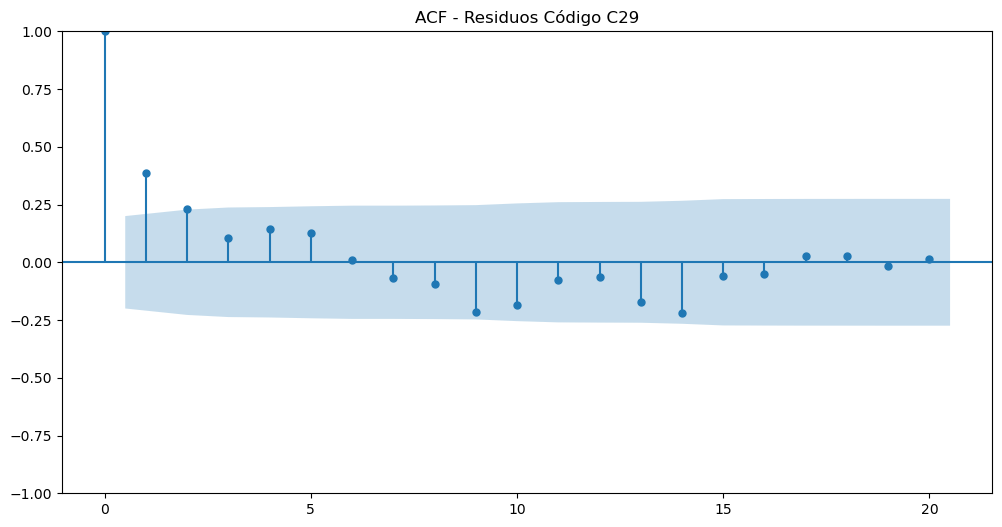

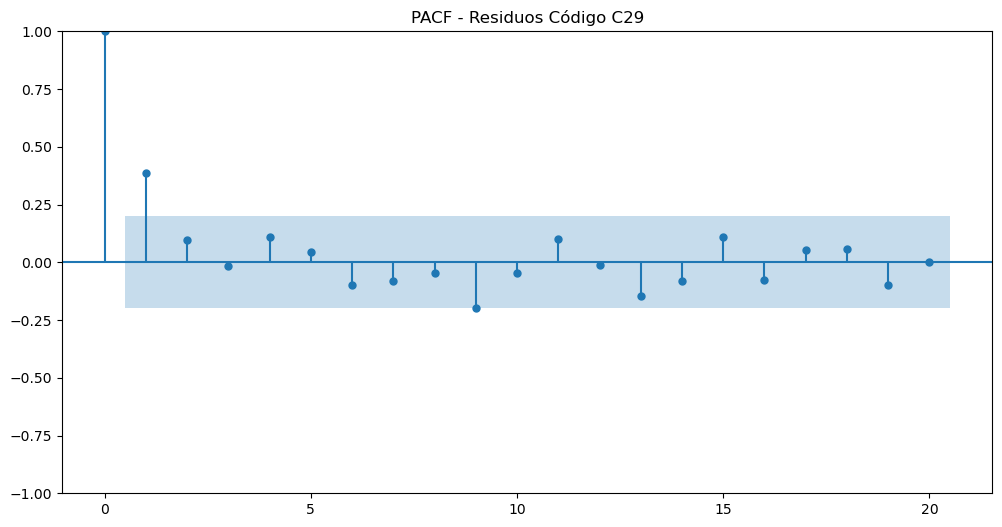

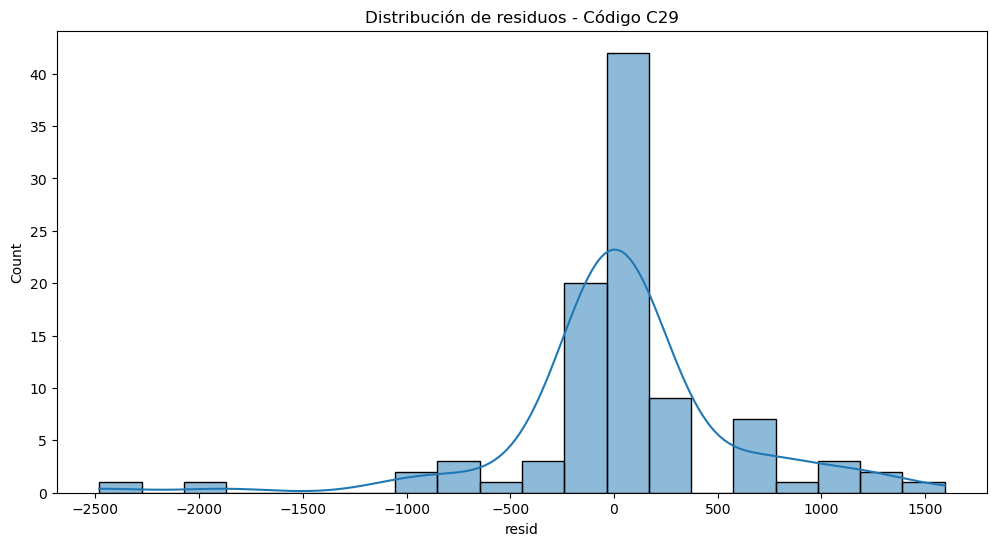

Pendiente: -2.09 comparendos por mes
R²: 0.012483
P-valor tendencia: 2.784686e-01
¿Tendencia significativa? No


Amplitud estacional: 1101 comparendos
Variabilidad explicada por estacionalidad: 5.17%

Prueba ADF sobre la serie original
Estadístico ADF: -3.560229
P-valor: 6.568492e-03
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -4.515149
P-valor: 1.846107e-04
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
       lb_stat     lb_pvalue
6    63.762370  7.716917e-12
12  101.820733  2.447211e-16
18  111.750463  1.484544e-15

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.279449
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 5.670809e-09
¿Residuos normales? No


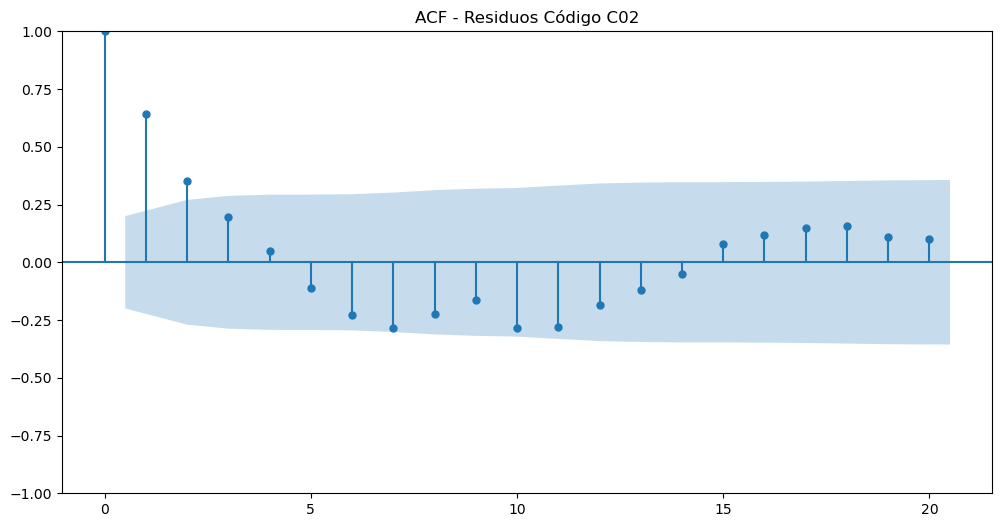

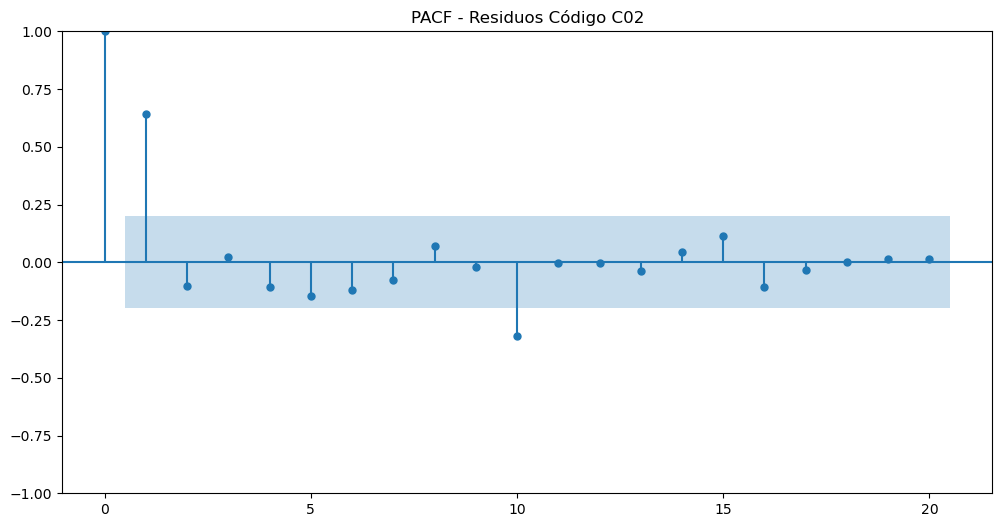

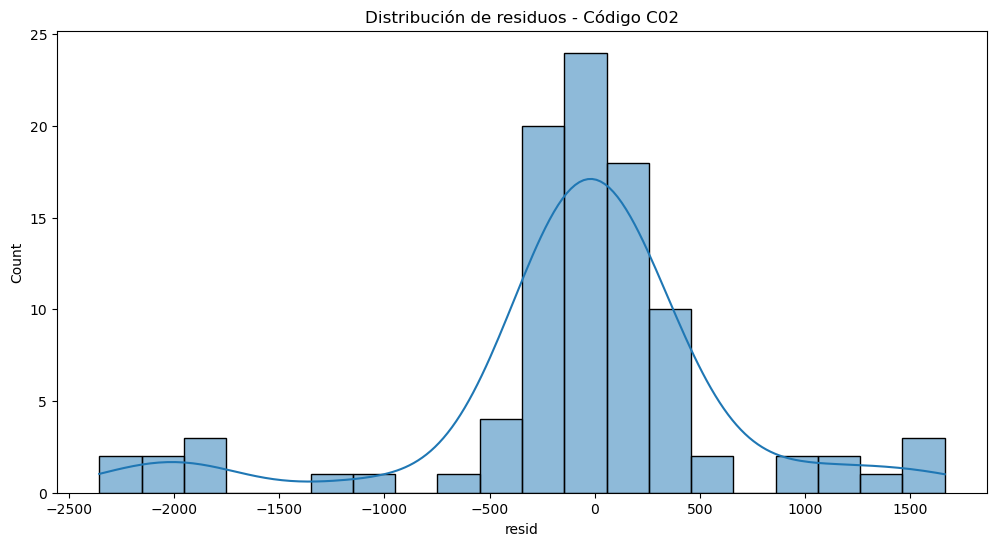

Pendiente: 10.32 comparendos por mes
R²: 0.515136
P-valor tendencia: 1.897789e-16
¿Tendencia significativa? Sí


Amplitud estacional: 1508 comparendos
Variabilidad explicada por estacionalidad: 10.93%

Prueba ADF sobre la serie original
Estadístico ADF: -3.206076
P-valor: 1.963569e-02
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -2.845189
P-valor: 5.210310e-02
Valores críticos:
  1%: -3.5088
  5%: -2.8958
  10%: -2.5850
Los residuos no son estacionarios

La descomposición no logró eliminar completamente la no estacionariedad



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   75.973192  2.419453e-14
12  84.460540  5.778506e-13
18  97.787880  5.620636e-13

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.005963
¿Residuos centrados en cero? No

Shapiro-Wilk p-valor: 1.433621e-11
¿Residuos normales? No


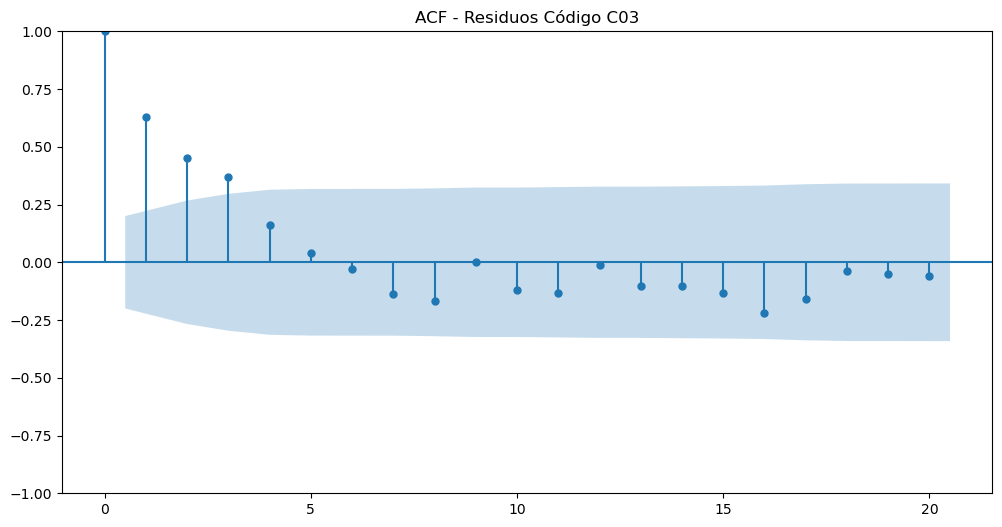

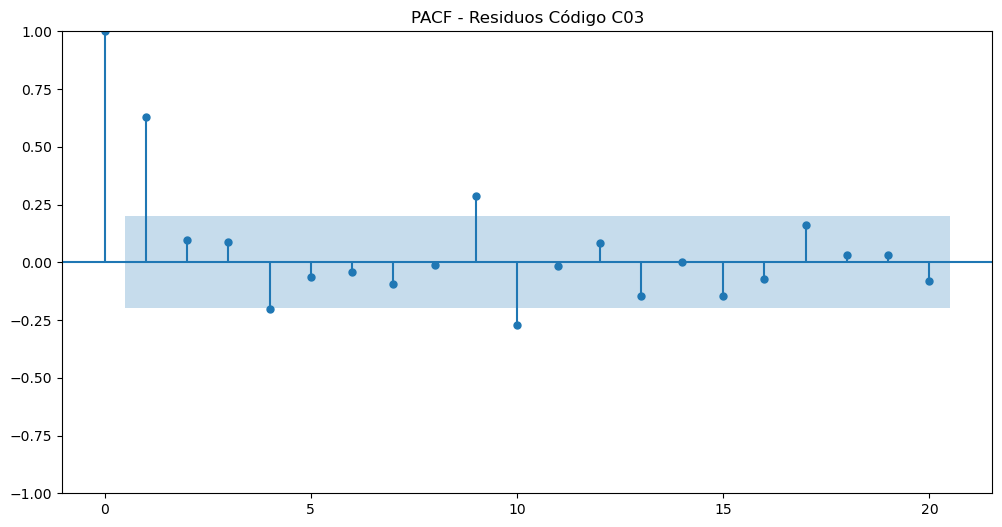

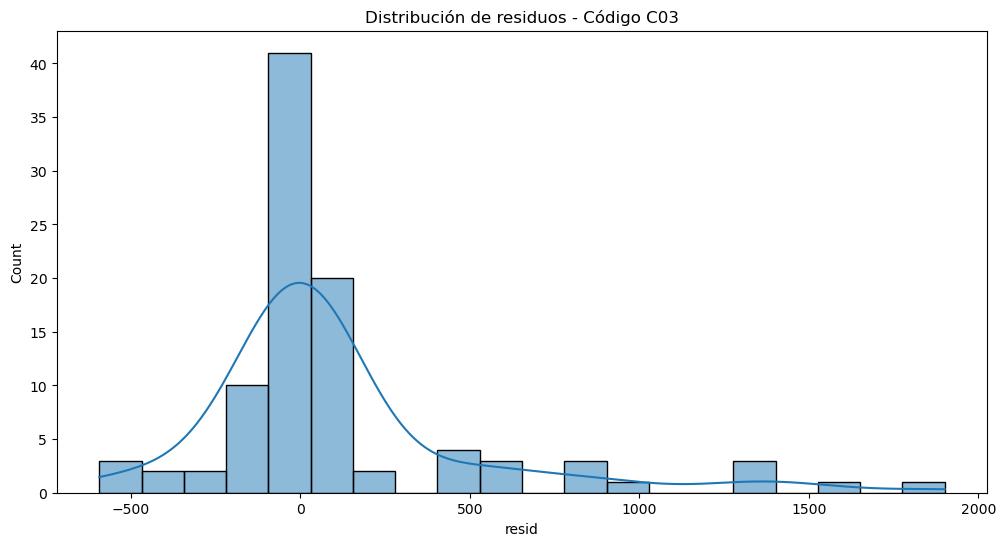

Pendiente: -2.10 comparendos por mes
R²: 0.140262
P-valor tendencia: 1.704625e-04
¿Tendencia significativa? Sí


Amplitud estacional: 598 comparendos
Variabilidad explicada por estacionalidad: 25.89%

Prueba ADF sobre la serie original
Estadístico ADF: -4.410945
P-valor: 2.838701e-04
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -7.968382
P-valor: 2.824389e-12
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat  lb_pvalue
6    5.189444   0.519755
12  15.680621   0.206306
18  16.970266   0.525150

¿Los residuos son ruido blanco? Sí
Prueba t (media cero) p-valor: 0.957663
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 1.352521e-06
¿Residuos normales? No


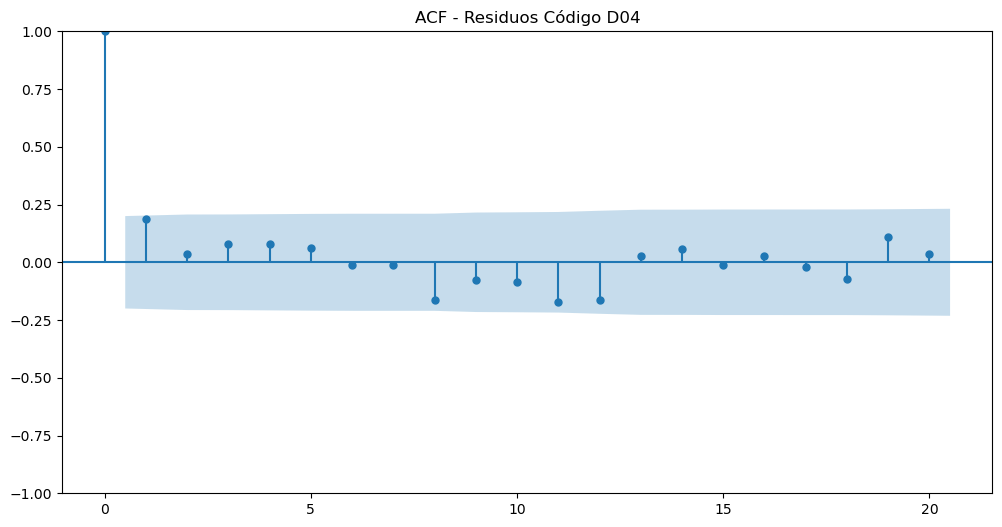

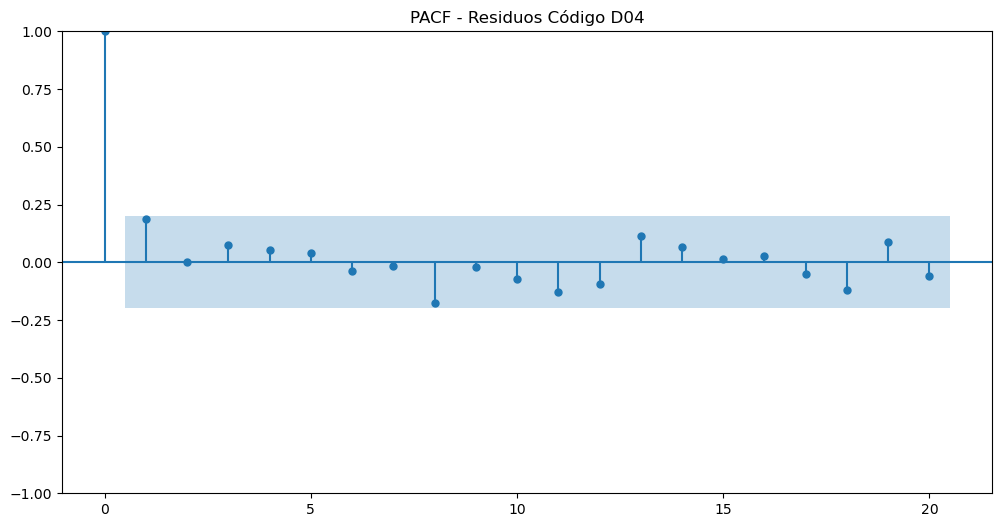

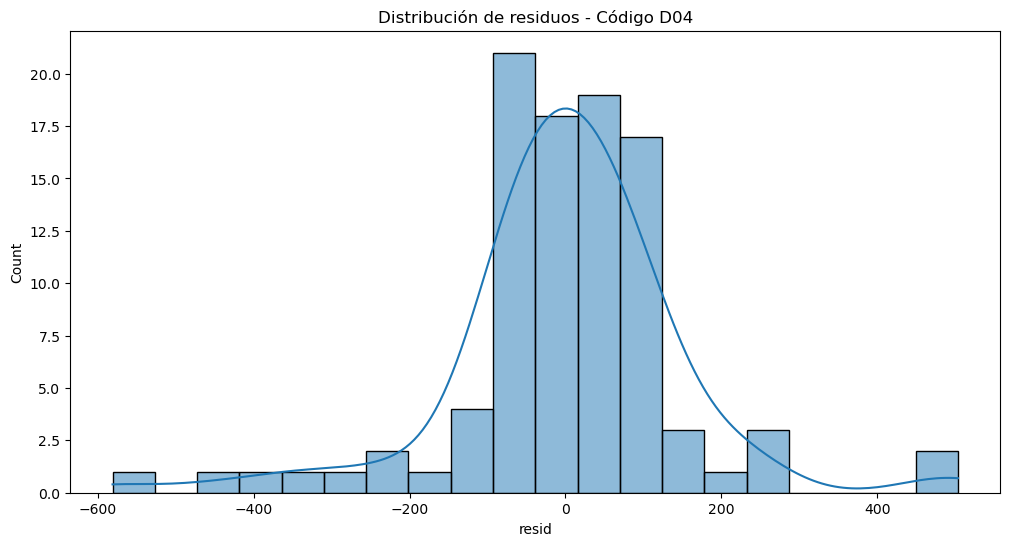

Pendiente: -0.04 comparendos por mes
R²: 0.012700
P-valor tendencia: 2.742995e-01
¿Tendencia significativa? No


Amplitud estacional: 36 comparendos
Variabilidad explicada por estacionalidad: 10.70%

Prueba ADF sobre la serie original
Estadístico ADF: -3.276819
P-valor: 1.594699e-02
Valores críticos:
  1%: -3.5019
  5%: -2.8928
  10%: -2.5835
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -3.430005
P-valor: 9.977558e-03
Valores críticos:
  1%: -3.5027
  5%: -2.8932
  10%: -2.5836
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   58.016370  1.137200e-10
12  63.354516  5.484042e-09
18  69.056902  6.521533e-08

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.032421
¿Residuos centrados en cero? No

Shapiro-Wilk p-valor: 7.879549e-12
¿Residuos normales? No


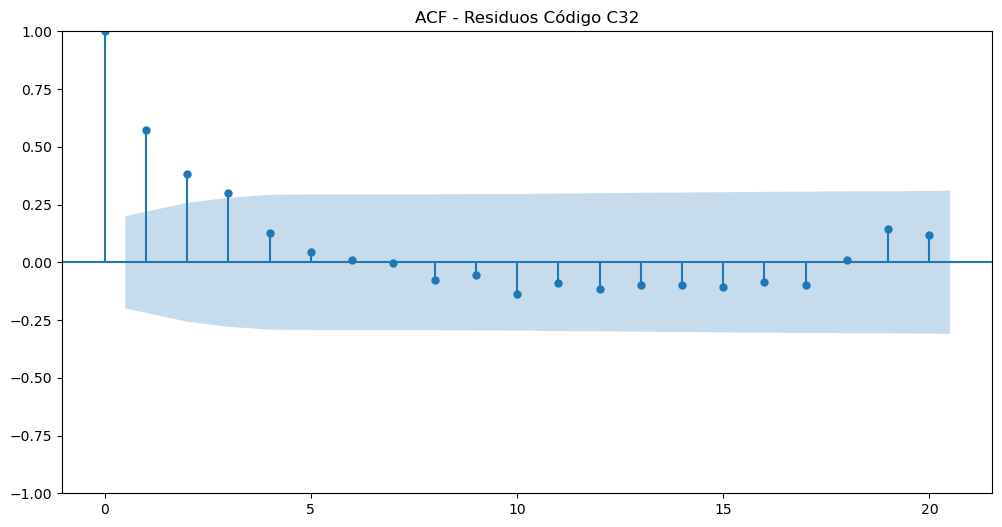

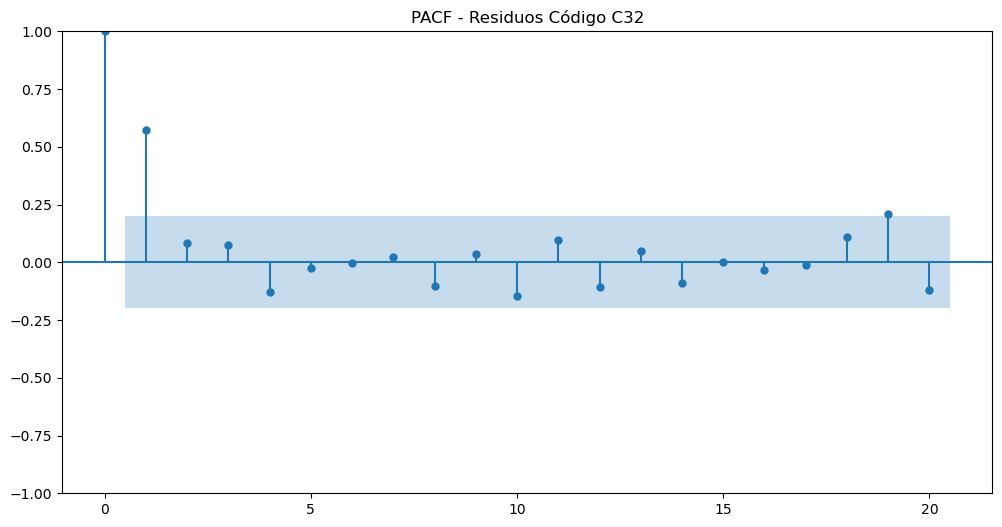

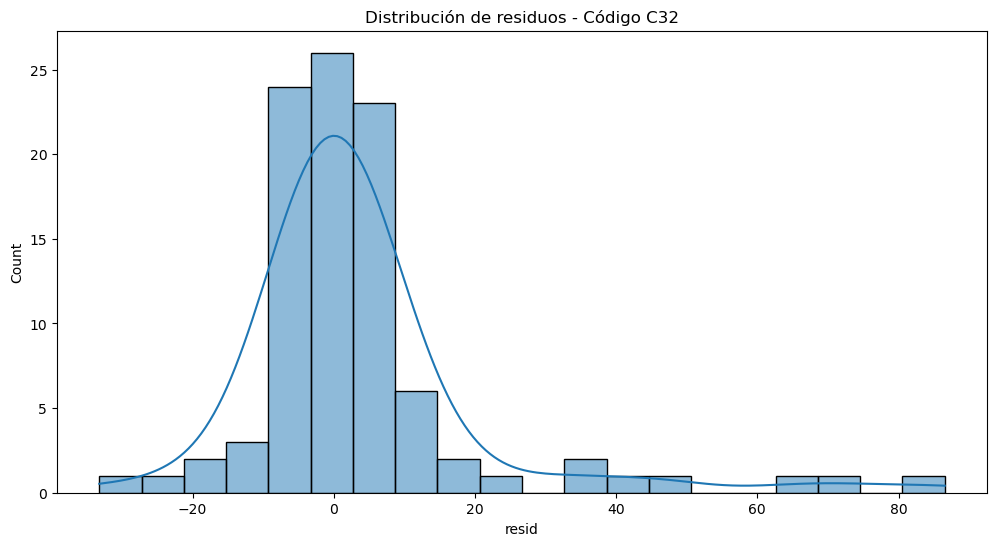

In [25]:
infracciones_por_mes_codigo = df_comparendos_electronicos_copy.groupby(['año_mes', 'COD_INFRACCION'])['CANTIDAD_INFRACCIONES'].sum().reset_index()

codigos_descomposicion = ['C29', 'C02', 'C03', 'D04', 'C32']

for codigo in codigos_descomposicion:
    
    serie_codigo = infracciones_por_mes_codigo[infracciones_por_mes_codigo['COD_INFRACCION'] == codigo].copy()
    serie_codigo = serie_codigo.set_index('año_mes')['CANTIDAD_INFRACCIONES']
    serie_codigo.index = pd.to_datetime(serie_codigo.index)
    serie_codigo = serie_codigo.asfreq('MS')
    serie_codigo = serie_codigo.fillna(0)
    
    descomposicion_codigo = STL(serie_codigo, period=12, robust=True).fit()

    tendencia_codigo = descomposicion_codigo.trend.dropna()
    x = np.arange(len(tendencia_codigo))
    pendiente_codigo, intercepto_codigo, r_value_codigo, p_valor_tendencia_codigo, std_err_codigo = stats.linregress(x, tendencia_codigo.values)
    r_cuadrado_codigo = r_value_codigo ** 2
    regresion_vals_codigo = pendiente_codigo * x + intercepto_codigo
    
    fig_tendencia_codigo = go.Figure()
    fig_tendencia_codigo.add_trace(go.Scatter(x=tendencia_codigo.index, y=tendencia_codigo.values, mode='lines+markers', name='Tendencia', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>', showlegend=False))
    fig_tendencia_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_codigo.sum()):,}', showlegend=True))
    fig_tendencia_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(tendencia_codigo.std()):,}', showlegend=True))
    fig_tendencia_codigo.add_trace(go.Scatter(x=[tendencia_codigo.index[0], tendencia_codigo.index[-1]], y=[tendencia_codigo.mean(), tendencia_codigo.mean()], mode='lines', name=f'Promedio: {int(tendencia_codigo.mean()):,}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_tendencia_codigo.add_trace(go.Scatter(x=tendencia_codigo.index, y=regresion_vals_codigo, mode='lines', name=f'Regresión lineal (R² = {r_cuadrado_codigo:.3f})', line=dict(color='orange', width=2, dash='solid'), showlegend=True))
    fig_tendencia_codigo.add_trace(go.Scatter(x=[tendencia_codigo.idxmax()], y=[tendencia_codigo.max()], mode='markers', name=f'Máximo: {tendencia_codigo.idxmax().strftime("%Y-%m")} ({int(tendencia_codigo.max()):,})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_tendencia_codigo.add_trace(go.Scatter(x=[tendencia_codigo.idxmin()], y=[tendencia_codigo.min()], mode='markers', name=f'Mínimo: {tendencia_codigo.idxmin().strftime("%Y-%m")} ({int(tendencia_codigo.min()):,})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_tendencia_codigo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_tendencia_codigo.update_layout(title=dict(text=f'Tendencia de Comparendos - Código {codigo}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_tendencia_codigo.show()
    
    print(f"Pendiente: {pendiente_codigo:.2f} comparendos por mes")
    print(f"R²: {r_cuadrado_codigo:.6f}")
    print(f"P-valor tendencia: {p_valor_tendencia_codigo:.6e}")
    print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia_codigo < 0.05 else 'No'}")
    
    estacionalidad_codigo = descomposicion_codigo.seasonal.dropna()
    amplitud_estacional_codigo = estacionalidad_codigo.max() - estacionalidad_codigo.min()
    var_total_codigo = descomposicion_codigo.trend.var() + descomposicion_codigo.seasonal.var() + descomposicion_codigo.resid.var()
    varianza_estacional_codigo = descomposicion_codigo.seasonal.var() / var_total_codigo * 100
    
    fig_estacionalidad_codigo = go.Figure()
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=estacionalidad_codigo.index, y=estacionalidad_codigo.values, mode='lines+markers', name='Estacionalidad', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Estacionalidad: %{y:,.2f}<extra></extra>', showlegend=False))
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_codigo.sum()):,}', showlegend=True))
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_codigo.std()):.0f}', showlegend=True))
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=[estacionalidad_codigo.index[0], estacionalidad_codigo.index[-1]], y=[estacionalidad_codigo.mean(), estacionalidad_codigo.mean()], mode='lines', name=f'Promedio: {estacionalidad_codigo.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=[estacionalidad_codigo.idxmax()], y=[estacionalidad_codigo.max()], mode='markers', name=f'Máximo: {estacionalidad_codigo.idxmax().strftime("%Y-%m")} ({estacionalidad_codigo.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_estacionalidad_codigo.add_trace(go.Scatter(x=[estacionalidad_codigo.idxmin()], y=[estacionalidad_codigo.min()], mode='markers', name=f'Mínimo: {estacionalidad_codigo.idxmin().strftime("%Y-%m")} ({estacionalidad_codigo.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_estacionalidad_codigo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_estacionalidad_codigo.update_layout(title=dict(text=f'Estacionalidad de Comparendos - Código {codigo}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_estacionalidad_codigo.show()
    
    print(f"Amplitud estacional: {amplitud_estacional_codigo:.0f} comparendos")
    print(f"Variabilidad explicada por estacionalidad: {varianza_estacional_codigo:.2f}%")
    

    print("\nPrueba ADF sobre la serie original")
    resultado_adf_original = adfuller(serie_codigo.dropna(), autolag='AIC')
    print(f"Estadístico ADF: {resultado_adf_original[0]:.6f}")
    print(f"P-valor: {resultado_adf_original[1]:.6e}")
    print("Valores críticos:")
    for key, value in resultado_adf_original[4].items():
        print(f"  {key}: {value:.4f}")
    if resultado_adf_original[1] < 0.05:
        print("La serie original es estacionaria")
    else:
        print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")
    
    print("\nPrueba ADF sobre los residuos")
    resultado_adf_residuos = adfuller(descomposicion_codigo.resid.dropna(), autolag='AIC')
    print(f"Estadístico ADF: {resultado_adf_residuos[0]:.6f}")
    print(f"P-valor: {resultado_adf_residuos[1]:.6e}")
    print("Valores críticos:")
    for key, value in resultado_adf_residuos[4].items():
        print(f"  {key}: {value:.4f}")
    if resultado_adf_residuos[1] < 0.05:
        print("Los residuos son estacionarios")
    else:
        print("Los residuos no son estacionarios")
    
    if resultado_adf_original[1] >= 0.05 and resultado_adf_residuos[1] < 0.05:
        print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad")
    elif resultado_adf_original[1] < 0.05 and resultado_adf_residuos[1] < 0.05:
        print("\nTanto la serie original como los residuos son estacionarios")
    else:
        print("\nLa descomposición no logró eliminar completamente la no estacionariedad")
    

    residuos_codigo = descomposicion_codigo.resid.dropna()
    p_valor_ljung_codigo = acorr_ljungbox(residuos_codigo, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    t_stat_codigo, p_valor_media_codigo = stats.ttest_1samp(residuos_codigo, 0)
    
    fig_residuos_codigo = go.Figure()
    fig_residuos_codigo.add_trace(go.Scatter(x=residuos_codigo.index, y=residuos_codigo.values, mode='lines+markers', name='Residuos', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False))
    fig_residuos_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_codigo.sum()):,}', showlegend=True))
    fig_residuos_codigo.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(residuos_codigo.std()):.0f}', showlegend=True))
    fig_residuos_codigo.add_trace(go.Scatter(x=[residuos_codigo.index[0], residuos_codigo.index[-1]], y=[residuos_codigo.mean(), residuos_codigo.mean()], mode='lines', name=f'Promedio: {residuos_codigo.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_residuos_codigo.add_trace(go.Scatter(x=[residuos_codigo.idxmax()], y=[residuos_codigo.max()], mode='markers', name=f'Máximo: {residuos_codigo.idxmax().strftime("%Y-%m")} ({residuos_codigo.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_residuos_codigo.add_trace(go.Scatter(x=[residuos_codigo.idxmin()], y=[residuos_codigo.min()], mode='markers', name=f'Mínimo: {residuos_codigo.idxmin().strftime("%Y-%m")} ({residuos_codigo.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_residuos_codigo.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_residuos_codigo.update_layout(title=dict(text=f'Residuos de Comparendos - Código {codigo}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Residuos (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_residuos_codigo.show()
    
    resultado_ljung_codigo = acorr_ljungbox(residuos_codigo, lags=[6, 12, 18], return_df=True)
    print("\nPrueba Ljung-Box")
    print(resultado_ljung_codigo)
    p_valor_ljung_codigo = resultado_ljung_codigo['lb_pvalue'].iloc[1]
    print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung_codigo > 0.05 else 'No'}")
    print(f"Prueba t (media cero) p-valor: {p_valor_media_codigo:.6f}")
    print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media_codigo > 0.05 else 'No'}")
    
    stat_codigo, p_shapiro_codigo = stats.shapiro(residuos_codigo)
    print(f"\nShapiro-Wilk p-valor: {p_shapiro_codigo:.6e}")
    print(f"¿Residuos normales? {'Sí' if p_shapiro_codigo > 0.05 else 'No'}")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(residuos_codigo, ax=ax)
    plt.title(f"ACF - Residuos Código {codigo}")
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_pacf(residuos_codigo, ax=ax)
    plt.title(f"PACF - Residuos Código {codigo}")
    plt.show()
    
    plt.figure(figsize=(12,6))
    sns.histplot(residuos_codigo, bins=20, kde=True)
    plt.title(f"Distribución de residuos - Código {codigo}")
    plt.show()
    
    display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))


**Código C29 (Exceso de velocidad)**

 - **Análisis de tendencia**: La pendiente negativa de -18.91 comparendos por mes indica una disminución promedio mensual estadísticamente significativa (p-valor < 0.0001). El R² de 57.9% muestra que la tendencia lineal explica más de la mitad de la variabilidad total, lo que indica un ajuste moderadamente bueno. La prueba de Durbin-Watson con un valor de 0.0004 indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que existen patrones sistemáticos no lineales no capturados. Se confirma una disminución sostenida en el volumen de infracciones por exceso de velocidad a lo largo del tiempo.

 - **Análisis de estacionalidad**: La estacionalidad explica solo el 5.66% de la variabilidad total, lo que indica que el exceso de velocidad tiene un patrón cíclico anual débil. La amplitud de 1,322 comparendos representa una oscilación moderada a lo largo del año, pero su bajo peso relativo sugiere que la mayor parte de la variabilidad se debe a otros componentes.

 - **Análisis de estacionariedad**: La serie original no es estacionaria (p-valor ADF = 0.2405), pero los residuos sí lo son (p-valor < 0.0001), indicando que la descomposición STL capturó correctamente tendencia y estacionalidad.

 - **Análisis de residuos**: Los residuos no son ruido blanco (p-valor Ljung-Box muy bajos), están centrados en cero (p-valor t-test = 0.4168) y no son normales (Shapiro-Wilk p-valor < 0.0001).

- **Gráfico de Autocorrelación (ACF) - Código C29**: El ACF mide la relación entre el residuo actual y sus valores pasados. Se observa una correlación significativa en el **lag 1**, que sobresale claramente de la banda sombreada azul, y también una ligera salida en el **lag 2**. Esto indica que el modelo aún no ha extraído toda la información de la serie temporal del código C29. El pico en el primer rezago sugiere la existencia de una estructura de **Promedio Móvil (MA)** o una persistencia no corregida, lo que significa que los residuos no son totalmente independientes y que el modelo actual podría beneficiarse de la inclusión de componentes adicionales.

- **Gráfico de Autocorrelación Parcial (PACF) - Código C29**: El PACF ayuda a identificar la correlación directa descartando las influencias de los retardos intermedios. Al igual que en el ACF, el **lag 1** es significativamente alto y positivo. Después de eso, la mayoría de los valores caen dentro del área de confianza (banda azul), aunque el lag 9 muestra una pequeña salida negativa. La presencia de un lag 1 fuerte tanto en ACF como en PACF suele indicar que el modelo podría beneficiarse de un ajuste en el orden **AR(1)** (Autorregresivo de orden 1) o **MA(1)** (Promedio Móvil de orden 1), o que la serie podría necesitar una diferencia adicional si aún no es completamente estacionaria.

- **Gráfico de la distribución de los residuos - Código C29**: Este gráfico evalúa la normalidad de los errores del modelo. La distribución tiene una forma acampanada centrada cerca de cero, lo cual es positivo porque indica que el modelo no tiene un sesgo sistemático importante. Sin embargo, se observa presencia de valores extremos hacia la izquierda (cerca de -2500) y hacia la derecha (más allá de 1500), lo que confirma que los errores no siguen una distribución normal perfecta. Estos valores extremos (outliers) podrían estar sesgando los parámetros del modelo o indicando eventos inusuales en los datos del código C29 que el modelo no puede explicar, como los picos por cierres viales en 2019 o las caídas por la pandemia en 2020.

---

**Código C02 (Estacionamiento prohibido)**

 - **Análisis de tendencia**: La pendiente negativa de -2.09 comparendos por mes no es estadísticamente significativa (p-valor = 0.2785). El R² de 1.25% es extremadamente bajo. **No se confirma una tendencia sostenida** en el volumen de infracciones por estacionamiento prohibido.

 - **Análisis de estacionalidad**: La estacionalidad explica solo el 5.17% de la variabilidad total, un patrón cíclico muy débil. La amplitud de 1,101 comparendos es moderada.

 - **Análisis de estacionariedad**: La serie original es estacionaria (p-valor ADF = 0.0066), al igual que los residuos, lo que indica que la serie ya tiene media y varianza constantes sin necesidad de descomposición.

 - **Análisis de residuos**: Los residuos no son ruido blanco (p-valores extremadamente bajos), están centrados en cero (p-valor = 0.2794) y no son normales.

- **Gráfico de Autocorrelación (ACF) - Código C02**: Se observa una autocorrelación muy fuerte y positiva en el **lag 1** (cercana a 0.6) y en el **lag 2**. Además, los lags se mantienen fuera de las bandas de confianza de manera persistente, formando un patrón de decaimiento gradual. Esto es una señal clara de que el modelo **no ha capturado la dinámica de la serie** del código C02. Los residuos están altamente correlacionados entre sí, lo que significa que lo que sucede hoy en el error está muy ligado a lo que sucedió en meses anteriores. Esta situación suele indicar que falta un componente autorregresivo (AR) en el modelo o que la serie original no ha sido correctamente estacionarizada, posiblemente necesitando una transformación adicional como una diferencia.

- **Gráfico de Autocorrelación Parcial (PACF) - Código C02**: Se observa un pico prominente y positivo en el **lag 1**, seguido de un pico negativo significativo en el **lag 10**. El pico en el lag 1 refuerza la idea de que se necesita un término **AR(1)** más robusto para capturar la dependencia temporal de corto plazo. Por otro lado, el pico negativo en el lag 10 es un hallazgo curioso que podría indicar una estacionalidad técnica o un ciclo específico en los datos del código C02 (como una periodicidad en los operativos de control de estacionamiento prohibido) que el modelo actual ignora por completo.

- **Gráfico de la distribución de los residuos - Código C02**: La distribución es claramente **no normal**. Se observa una concentración principal de errores cerca de cero, pero también existe un segundo grupo o "cluster" de errores muy grandes y negativos (alrededor de -2000). EstO sugiere que el modelo tiene dificultades para predecir ciertos eventos específicos donde el volumen de infracciones por estacionamiento prohibido cae drásticamente, posiblemente relacionados con la suspensión de operativos de cámaras móviles durante la pandemia de 2020 o por condiciones climáticas adversas que limitan la movilidad de las patrullas de control.

---

**Código C03 (Bloqueo de calzada o intersección)**

 - **Análisis de tendencia**: La pendiente positiva de 10.32 comparendos por mes indica un **aumento** promedio mensual estadísticamente significativo (p-valor < 0.0001). El R² de 51.5% muestra un ajuste moderadamente bueno. Se confirma un crecimiento sostenido en el volumen de infracciones por bloqueo de calzada a lo largo del tiempo, lo que contrasta con los demás códigos que presentan tendencias negativas o nulas.

 - **Análisis de estacionalidad**: La estacionalidad explica el 10.93% de la variabilidad total, el porcentaje más alto entre los códigos analizados junto con D04. La amplitud de 1,508 comparendos es considerable.

 - **Análisis de estacionariedad**: La serie original es estacionaria (p-valor ADF = 0.0196), pero **los residuos no son estacionarios** (p-valor = 0.0521, ligeramente por encima de 0.05). Esto indica que la descomposición STL no logró eliminar completamente la no estacionariedad, posiblemente por la presencia de la tendencia creciente que no fue completamente capturada.

 - **Análisis de residuos**: Los residuos no son ruido blanco, **no están centrados en cero** (p-valor t-test = 0.0060), y no son normales. El sesgo en los residuos indica que el modelo subestima o sobreestima sistemáticamente los valores.

 - **Gráfico de Autocorrelación (ACF) - Código C03**: Se presentan picos significativos y positivos en los **lags 1, 2 y 3**, con una caída de la correlación de forma gradual, lo que se conoce como un comportamiento de memoria larga. Esto indica que el modelo actual no ha logrado eliminar la dependencia serial de los residuos. El hecho de que los primeros tres rezagos sean tan altos sugiere que el error de un mes está fuertemente influenciado por los errores de los últimos tres meses. Esta situación indica que el modelo necesita una estructura de **Promedio Móvil (MA)** de mayor orden para capturar esa dependencia, o que la serie original aún presenta una tendencia no capturada adecuadamente por la descomposición.

- **Gráfico de Autocorrelación Parcial (PACF) - Código C03**: Se observa un pico muy prominente en el **lag 1** (superior a 0.6), seguido de picos significativos en el **lag 4** (negativo), **lag 9** (positivo) y **lag 10** (negativo). El pico fuerte en el lag 1 es una señal clásica de que se requiere un componente **Autorregresivo AR(1)** para modelar la dependencia de corto plazo. Sin embargo, los picos significativos en los lags 9 y 10 son más llamativos, ya que sugieren la existencia de una **estacionalidad** o un ciclo oculto en los datos del código C03 que el modelo actual está ignorando por completo, posiblemente relacionado con patrones de movilidad específicos que se repiten cada cierto número de meses.

- **Gráfico de la distribución de los residuos - Código C03**: La distribución presenta un sesgo hacia la derecha (**asimetría positiva**), lo que indica que la cola derecha de la distribución es más larga que la izquierda. La mayor parte de los residuos están concentrados alrededor de cero, lo cual es positivo, pero existe una "cola" muy larga hacia los valores positivos (llegando hasta casi 2000). Esto significa que, aunque la mayoría de las predicciones del modelo son precisas, el modelo tiende a **subestimar significativamente** el valor real en varias ocasiones (generando residuos positivos grandes). Esta subestimación indica que los errores no son normales y que el modelo es vulnerable a valores atípicos o "picos" repentinos en la serie original del código C03, como los aumentos en infracciones por bloqueo de calzada durante períodos de alta congestión vehicular o eventos especiales.

---

**Código D04 (Paso de semáforo en rojo o señal de pare)**

 - **Análisis de tendencia**: La pendiente negativa de -2.10 comparendos por mes es estadísticamente significativa (p-valor = 0.0002). El R² de 14.0% es bajo, indicando que la tendencia explica una pequeña parte de la variabilidad. Se confirma una leve disminución sostenida.

 - **Análisis de estacionalidad**: La estacionalidad explica el **25.89%** de la variabilidad total, el porcentaje más alto de todos los códigos. La amplitud de 598 comparendos es la menor en términos absolutos, pero su peso relativo es el más importante, indicando que el paso de semáforo en rojo tiene el patrón estacional más definido.

 - **Análisis de estacionariedad**: Tanto la serie original como los residuos son estacionarios.

 - **Análisis de residuos**: **Los residuos son ruido blanco** (p-valores Ljung-Box > 0.05 para todos los rezagos), están centrados en cero (p-valor = 0.9577) y no son normales. Este es el único código donde los residuos cumplen con la condición de ruido blanco, lo que indica que el modelo de descomposición capturó adecuadamente toda la estructura temporal de la serie.

- **Gráfico de Autocorrelación (ACF) y Autocorrelación Parcial (PACF) - Código D04**: A diferencia de los demás códigos de infracción, en el código D04 casi todos los retardos (lags) se encuentran **dentro de las bandas de confianza** (el área sombreada azul). Solo el lag 1 en el PACF y en el ACF roza el límite superior, pero de forma muy leve y sin alcanzar niveles problemáticos, especialmente en comparación con los patrones observados en los códigos C29, C02 y C03. Esto indica que el modelo de descomposición ha capturado exitosamente casi toda la dependencia temporal de la serie correspondiente al paso de semáforo en rojo. Los residuos son prácticamente independientes entre sí, lo que significa que el modelo no presenta problemas significativos de autocorrelación serial.

- **Gráfico de la distribución de los residuos - Código D04**: El histograma muestra una forma mucho más simétrica y centrada en cero en comparación con los otros códigos analizados. Aunque todavía existen algunos valores atípicos (outliers) en los extremos (-600 y +500), la curva de densidad (KDE) se ajusta mucho mejor a la forma de una distribución normal. Esto indica que los errores del modelo para el código D04 tienen una varianza más constante y menos sesgo que en los demás códigos. En consecuencia, el modelo es mucho más fiable para realizar inferencias estadísticas o pronósticos sobre las infracciones relacionadas con el paso de semáforos en rojo o señal de pare, lo cual es consistente con los buenos resultados obtenidos en las pruebas de ruido blanco y estacionariedad para este código.

---

**Código C32 (Paso de peatones)**

 - **Análisis de tendencia**: La pendiente de -0.04 comparendos por mes no es estadísticamente significativa (p-valor = 0.2743). El R² de 1.27% es extremadamente bajo. **No se confirma una tendencia sostenida**.

 - **Análisis de estacionalidad**: La estacionalidad explica el 10.70% de la variabilidad total. La amplitud de solo 36 comparendos refleja el bajo volumen de esta infracción.

 - **Análisis de estacionariedad**: Tanto la serie original como los residuos son estacionarios.

 - **Análisis de residuos**: Los residuos no son ruido blanco, **no están centrados en cero** (p-valor t-test = 0.0324), y no son normales. El sesgo indica que el modelo tiene un error sistemático.

- **Gráfico de Autocorrelación (ACF) - Código C32**: Prácticamente todos los retardos (lags) se encuentran dentro de las bandas sombreadas azules de confianza. Solo hay un par de picos que rozan o sobresalen mínimamente de la banda, pero no de forma alarmante ni sistemática. Esto es una excelente señal, ya que indica que los residuos son **independientes** y que el modelo ha logrado extraer casi toda la estructura de dependencia temporal de los datos originales del código C32. No hay evidencia significativa de que falten términos de promedio móvil (MA) en la especificación del modelo.

- **Gráfico de Autocorrelación Parcial (PACF) - Código C32**: Al igual que en el ACF, los valores se mantienen dentro de los límites de significancia. El lag 1 es muy bajo, lo que contrasta positivamente con los modelos de los códigos C29 o C02, donde el lag 1 representaba un problema crítico de autocorrelación. Esta ausencia de picos significativos confirma que no hay necesidad de añadir más componentes autorregresivos (AR) al modelo, y que la estructura de rezagos está bien especificada para esta infracción.

- **Gráfico de la distribución de los residuos - Código C32**: El histograma muestra una distribución **unimodal y asimétrica positiva**, muy bien centrada en cero. La curva azul (KDE) sigue de cerca la forma de una campana de Gauss, aproximándose razonablemente a una distribución normal. Aunque persisten algunos "outliers" (valores extremos hacia +80), estos son mucho menos frecuentes y menos extremos que en los otros códigos analizados. En general, los errores tienden hacia la **normalidad**, lo que valida el uso de intervalos de confianza para los pronósticos, ya que los supuestos del modelo se cumplen razonablemente bien para el código C32.

---

**Hallazgos**:

- Mientras que C29 y D04 muestran disminuciones significativas, y C02 y C32 no presentan tendencia, el bloqueo de calzada o interseción ha aumentado sostenidamente (+10.32 comparendos por mes), lo que sugiere un problema creciente de conductores bloqueando intersecciones.

- Con un 25.89% de variabilidad explicada, el código D04 es el único con un patrón estacional bien definido, además de ser el único con residuos que cumplen la condición de ruido blanco.

- El código D04 es el único donde el modelo capturó toda la estructura temporal, lo que sugiere que es la serie más predecible y con patrones más claros.

- Para el código C03 los residuos no estacionarios y el sesgo en la media indican que la tendencia creciente no fue completamente capturada, posiblemente por la presencia de un punto de inflexión o por cambios en el comportamiento a lo largo del tiempo.

- C29 tiene la mayor variabilidad explicada por tendencia con un R² del 57.9%, el exceso de velocidad es la infracción donde la disminución a largo plazo es más evidente y consistente.

## Descomposición de la Serie Temporal Mensual por Servicio del Vehículo Infractor

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a las series temporales mensuales de comparendos electrónicos para cada categoría de servicio del vehículo (PARTICULAR, PÚBLICO y OTROS), con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Para cada servicio, se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis permite comprender la dinámica subyacente de cada categoría de servicio, identificar qué servicios presentan tendencias crecientes o decrecientes significativas, cuantificar la fuerza de sus patrones estacionales, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de cada serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas diferenciadas por tipo de servicio vehicular.

In [26]:
df_comparendos_electronicos_copy['SERVICIO_AGRUPADO'] = df_comparendos_electronicos_copy['SERVICIO_VEHICULO_INFRACTOR'].replace(['OFICIAL', 'DIPLOMATICO'], 'OTROS')

infracciones_por_mes_servicio = df_comparendos_electronicos_copy.groupby(['año_mes', 'SERVICIO_AGRUPADO'])['CANTIDAD_INFRACCIONES'].sum().reset_index()

servicios = df_comparendos_electronicos_copy['SERVICIO_AGRUPADO'].unique()

for servicio in servicios:
    df_servicio_mensual = infracciones_por_mes_servicio[infracciones_por_mes_servicio['SERVICIO_AGRUPADO'] == servicio].copy()
    df_servicio_mensual = df_servicio_mensual[['año_mes', 'CANTIDAD_INFRACCIONES']].sort_values('año_mes').reset_index(drop=True)
    df_servicio_mensual.columns = ['Mes', 'Comparendos']
    
    total_servicio = df_servicio_mensual['Comparendos'].sum()
    

    df_servicio_mensual['Porcentaje'] = (df_servicio_mensual['Comparendos'] / total_servicio * 100).round(2)
    
    df_servicio_mensual = df_servicio_mensual.sort_values('Comparendos', ascending=False).reset_index(drop=True)
    
    print(f"Distribución de Comparendos Electrónicos por Mes - Servicio: {servicio}")
    pd.set_option('display.max_columns', None)  
    pd.set_option('display.width', None)        
    pd.set_option('display.max_colwidth', None) 
    display(df_servicio_mensual.T)
    pd.reset_option('display.max_columns')
    pd.reset_option('display.width')
    pd.reset_option('display.max_colwidth')
    
    display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

for servicio in servicios:
    df_servicio = infracciones_por_mes_servicio[infracciones_por_mes_servicio['SERVICIO_AGRUPADO'] == servicio]
    
    total_servicio = df_servicio['CANTIDAD_INFRACCIONES'].sum()
    desviacion_servicio = df_servicio['CANTIDAD_INFRACCIONES'].std()
    promedio_servicio = df_servicio['CANTIDAD_INFRACCIONES'].mean()
    
    meses_servicio = sorted(df_servicio['año_mes'].unique())
    
    if len(meses_servicio) > 12:
        tick_positions = meses_servicio[::6]
    elif len(meses_servicio) > 6:
        tick_positions = meses_servicio[::3]
    else:
        tick_positions = meses_servicio
    
    max_valor = df_servicio['CANTIDAD_INFRACCIONES'].max()
    max_fila = df_servicio[df_servicio['CANTIDAD_INFRACCIONES'] == max_valor].iloc[0]
    max_mes = max_fila['año_mes']
    
    min_valor = df_servicio['CANTIDAD_INFRACCIONES'].min()
    min_fila = df_servicio[df_servicio['CANTIDAD_INFRACCIONES'] == min_valor].iloc[0]
    min_mes = min_fila['año_mes']
    
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df_servicio['año_mes'],
        y=df_servicio['CANTIDAD_INFRACCIONES'],
        mode='lines+markers',
        name=servicio,
        line=dict(color='cornflowerblue', width=2),
        marker=dict(size=4, color='cornflowerblue'),
        hovertemplate=f'Servicio: {servicio}<br>Mes: %{{x}}<br>Infracciones: %{{y:,.0f}}<extra></extra>',
        showlegend=False
    ))
    
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode='none',
        name=f'Total: {int(total_servicio):,}',
        showlegend=True
    ))
    
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode='none',
        name=f'Std: {int(desviacion_servicio):,}',
        showlegend=True
    ))
    
    x_min = df_servicio['año_mes'].iloc[0]
    x_max = df_servicio['año_mes'].iloc[-1]
    fig.add_trace(go.Scatter(
        x=[x_min, x_max],
        y=[promedio_servicio, promedio_servicio],
        mode='lines',
        name=f'Promedio: {int(promedio_servicio):,}',
        line=dict(color='red', width=1.4, dash='dot'),
        showlegend=True,
        hoverinfo='none'
    ))
    
    fig.add_trace(go.Scatter(
        x=[max_mes],
        y=[max_valor],
        mode='markers',
        name=f'Máximo: {max_mes} ({int(max_valor):,})',
        marker=dict(size=8, color='red', symbol='circle'),
        hoverinfo='none'
    ))
    
    fig.add_trace(go.Scatter(
        x=[min_mes],
        y=[min_valor],
        mode='markers',
        name=f'Mínimo: {min_mes} ({int(min_valor):,})',
        marker=dict(size=8, color='green', symbol='circle'),
        hoverinfo='none'
    ))
    
    fig.add_vrect(
        x0="2020-03", x1="2020-12",
        fillcolor="red", opacity=0.1,
        line_width=0,
        annotation_text="COVID-19", 
        annotation_position="top left",
        annotation=dict(font_size=12, font_color="red")
    )
    
    fig.update_layout(
        title=dict(
            text=f'Evolución Mensual de Comparendos - Servicio: {servicio}',
            x=0.5,
            xanchor='center',
            font=dict(size=16, weight='bold')
        ),
        xaxis_title=dict(
            text='Año-Mes',
            font=dict(weight='bold')
        ),
        yaxis_title=dict(
            text='Cantidad de Comparendos',
            font=dict(weight='bold')
        ),
        template='plotly_white',
        hovermode='x unified',
        legend=dict(
            x=1, 
            y=1, 
            xanchor='center',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.5)',
            font=dict(size=12)
        ),
        width=1055,
        height=500
    )
    
    fig.update_xaxes(
        tickangle=-45,
        tickvals=tick_positions,
        ticktext=tick_positions
    )
    
    fig.show()


Distribución de Comparendos Electrónicos por Mes - Servicio: PARTICULAR


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
Mes,2019-05,2019-06,2019-07,2019-04,2019-03,2024-05,2024-04,2023-09,2023-07,2019-08,2023-12,2023-08,2023-10,2024-03,2024-06,2018-01,2022-06,2024-07,2023-06,2019-02,2018-11,2023-05,2022-12,2023-11,2024-09,2024-01,2020-01,2022-07,2023-03,2022-05,2018-03,2024-10,2019-10,2018-05,2018-10,2024-02,2022-11,2020-02,2018-04,2019-12,2018-12,2021-02,2020-10,2019-09,2023-04,2022-10,2024-08,2019-11,2022-09,2018-06,2019-01,2018-02,2018-07,2021-03,2018-09,2022-04,2020-12,2018-08,2025-10,2022-08,2021-01,2020-03,2020-11,2025-04,2024-11,2023-02,2025-01,2024-12,2025-03,2022-03,2025-11,2025-09,2021-07,2022-01,2025-05,2025-02,2025-07,2021-04,2021-12,2020-09,2025-06,2025-12,2021-08,2021-09,2020-04,2021-10,2020-08,2021-05,2021-11,2022-02,2025-08,2021-06,2020-06,2020-07,2023-01,2020-05
Comparendos,8466,8277,8011,7964,7860,7685,7491,7410,7375,7316,7287,7241,7158,7060,7029,7015,6917,6737,6736,6691,6544,6530,6473,6461,6437,6426,6424,6412,6398,6366,6344,6285,6219,6168,6164,6104,6056,6025,6019,6018,6006,5993,5987,5975,5958,5823,5777,5734,5655,5602,5532,5525,5514,5502,5455,5447,5432,5404,5396,5148,5147,5037,4887,4853,4794,4735,4703,4669,4579,4489,4311,4278,4272,4239,4223,4215,4174,4143,4129,4069,3772,3701,3700,3690,3690,3644,3550,3538,3495,3329,2958,2810,2483,2355,1722,1139
Porcentaje,1.61,1.57,1.52,1.51,1.49,1.46,1.42,1.41,1.4,1.39,1.39,1.38,1.36,1.34,1.34,1.33,1.32,1.28,1.28,1.27,1.24,1.24,1.23,1.23,1.22,1.22,1.22,1.22,1.22,1.21,1.21,1.19,1.18,1.17,1.17,1.16,1.15,1.15,1.14,1.14,1.14,1.14,1.14,1.14,1.13,1.11,1.1,1.09,1.08,1.07,1.05,1.05,1.05,1.05,1.04,1.04,1.03,1.03,1.03,0.98,0.98,0.96,0.93,0.92,0.91,0.9,0.89,0.89,0.87,0.85,0.82,0.81,0.81,0.81,0.8,0.8,0.79,0.79,0.79,0.77,0.72,0.7,0.7,0.7,0.7,0.69,0.67,0.67,0.66,0.63,0.56,0.53,0.47,0.45,0.33,0.22


Distribución de Comparendos Electrónicos por Mes - Servicio: PUBLICO


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
Mes,2022-12,2019-03,2022-11,2022-06,2019-04,2018-11,2022-04,2019-05,2023-07,2022-05,2019-07,2023-06,2018-10,2023-12,2019-08,2023-09,2022-07,2019-06,2019-02,2023-03,2023-04,2023-05,2024-05,2024-09,2023-08,2023-10,2022-09,2022-10,2018-01,2024-04,2024-07,2025-10,2024-06,2018-12,2024-03,2024-10,2025-11,2018-05,2019-01,2018-03,2022-08,2023-11,2020-02,2023-02,2019-09,2020-01,2018-02,2019-12,2019-10,2018-06,2020-10,2024-01,2024-02,2018-04,2022-03,2019-11,2018-07,2018-09,2020-03,2024-08,2020-09,2018-08,2020-08,2020-11,2024-11,2025-09,2021-04,2020-12,2020-04,2021-01,2021-02,2025-04,2021-03,2025-05,2025-07,2022-01,2024-12,2025-01,2025-12,2025-03,2021-07,2021-11,2021-12,2021-09,2025-06,2021-10,2021-08,2025-02,2020-06,2020-07,2025-08,2021-05,2022-02,2023-01,2021-06,2020-05
Comparendos,1960,1637,1506,1493,1400,1400,1382,1368,1368,1361,1301,1299,1289,1276,1267,1263,1242,1233,1210,1183,1175,1171,1134,1121,1121,1111,1109,1103,1099,1098,1071,1068,1065,1056,1046,1012,1009,992,986,977,976,965,963,962,956,916,904,897,896,896,895,851,849,841,836,833,809,809,789,788,768,754,739,726,725,725,725,714,703,689,684,657,656,627,614,612,612,583,572,571,560,557,550,545,533,520,515,502,491,448,447,434,410,383,362,247
Porcentaje,2.24,1.87,1.72,1.71,1.6,1.6,1.58,1.56,1.56,1.55,1.49,1.48,1.47,1.46,1.45,1.44,1.42,1.41,1.38,1.35,1.34,1.34,1.3,1.28,1.28,1.27,1.27,1.26,1.26,1.25,1.22,1.22,1.22,1.21,1.19,1.16,1.15,1.13,1.13,1.12,1.11,1.1,1.1,1.1,1.09,1.05,1.03,1.02,1.02,1.02,1.02,0.97,0.97,0.96,0.95,0.95,0.92,0.92,0.9,0.9,0.88,0.86,0.84,0.83,0.83,0.83,0.83,0.82,0.8,0.79,0.78,0.75,0.75,0.72,0.7,0.7,0.7,0.67,0.65,0.65,0.64,0.64,0.63,0.62,0.61,0.59,0.59,0.57,0.56,0.51,0.51,0.5,0.47,0.44,0.41,0.28


Distribución de Comparendos Electrónicos por Mes - Servicio: OTROS


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92
Mes,2019-02,2018-12,2018-01,2025-02,2023-08,2024-09,2023-03,2025-12,2024-04,2018-10,2018-07,2024-03,2019-08,2024-12,2018-05,2025-07,2018-03,2024-07,2024-10,2025-05,2023-05,2025-04,2024-02,2021-02,2018-04,2018-09,2019-04,2018-06,2023-09,2025-11,2023-07,2019-01,2025-01,2019-06,2018-08,2023-10,2023-11,2018-02,2019-07,2022-05,2019-05,2022-12,2019-09,2018-11,2019-03,2025-06,2025-09,2023-12,2023-06,2022-11,2020-10,2020-12,2019-10,2024-05,2021-03,2024-06,2025-10,2020-04,2020-01,2019-12,2024-08,2025-03,2022-04,2022-06,2021-07,2022-09,2021-09,2020-09,2023-02,2024-01,2023-04,2022-10,2020-03,2022-07,2021-12,2022-01,2019-11,2021-11,2021-06,2021-04,2022-08,2024-11,2025-08,2022-03,2022-02,2020-07,2020-06,2021-08,2020-11,2021-10,2021-05,2020-02,2023-01
Comparendos,27,20,20,20,17,17,16,16,16,15,15,14,13,13,13,13,12,12,12,12,12,11,11,11,11,11,11,11,11,11,11,10,10,10,10,9,9,9,9,9,9,9,8,8,8,8,8,8,8,8,8,8,8,8,8,7,7,7,7,7,7,7,7,7,7,6,6,6,6,6,5,5,5,5,5,5,4,4,4,4,4,4,4,3,3,3,2,2,2,2,2,1,1
Porcentaje,3.29,2.44,2.44,2.44,2.07,2.07,1.95,1.95,1.95,1.83,1.83,1.71,1.58,1.58,1.58,1.58,1.46,1.46,1.46,1.46,1.46,1.34,1.34,1.34,1.34,1.34,1.34,1.34,1.34,1.34,1.34,1.22,1.22,1.22,1.22,1.1,1.1,1.1,1.1,1.1,1.1,1.1,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.97,0.85,0.85,0.85,0.85,0.85,0.85,0.85,0.85,0.85,0.85,0.73,0.73,0.73,0.73,0.73,0.61,0.61,0.61,0.61,0.61,0.61,0.49,0.49,0.49,0.49,0.49,0.49,0.49,0.37,0.37,0.37,0.24,0.24,0.24,0.24,0.24,0.12,0.12


**Servicio PARTICULAR (525,986 infracciones - 85.62% del total)**

- **Análisis de tendencia**: La pendiente negativa de -7.68 comparendos por mes indica una disminución promedio mensual estadísticamente significativa (p-valor = 0.0270). El R² de 5.1% muestra que la tendencia lineal explica una pequeña parte de la variabilidad total, aunque la relación es significativa. La prueba de Durbin-Watson con un valor de 0.0004 indica una fuerte autocorrelación positiva en los residuos de la tendencia, lo que sugiere que la tendencia lineal no captura adecuadamente toda la estructura temporal y que existen patrones sistemáticos no lineales en la evolución de largo plazo. Se confirma una disminución sostenida en el volumen de comparendos de vehículos particulares a lo largo del tiempo.

- **Análisis de estacionalidad**: La estacionalidad explica el 12.34% de la variabilidad total, lo que indica que los vehículos particulares presentan un patrón cíclico anual moderado. La amplitud de 2,823 comparendos representa una oscilación considerable a lo largo del año, la más alta entre los tres servicios.

- **Análisis de estacionariedad**: La serie original es estacionaria (p-valor ADF = 0.0137), al igual que los residuos (p-valor < 0.0001), lo que indica que la serie ya tiene media y varianza constantes.

- **Análisis de residuos**: Los residuos no son ruido blanco (p-valores Ljung-Box extremadamente bajos), están centrados en cero (p-valor t-test = 0.8144) y no son normales (Shapiro-Wilk p-valor < 0.0001).


- **Gráfico de Autocorrelación (ACF) - PARTICULAR**: El ACF mide la relación entre el residuo actual y sus valores pasados. Se observan picos significativos que sobresalen claramente de la banda azul (intervalo de confianza) en los rezagos 1, 2 y 7. Especialmente notable es el pico en el **lag 7**, que sugiere la presencia de un patrón estacional no completamente capturado por el modelo. En consecuencia, los residuos **no son ruido blanco**, lo que indica que existe una correlación serial significativa remanente que el modelo actual no ha logrado eliminar.

- **Gráfico de Autocorrelación Parcial (PACF) - PARTICULAR**: El PACF ayuda a identificar el orden de un modelo autorregresivo (AR). Se observa un pico muy marcado en el rezago 1 y otro que roza el límite de significancia en el rezago 7. La presencia de estos picos significativos en el PACF confirma que los errores siguen teniendo una estructura predecible después de aplicar la descomposición, especialmente en el corto plazo (lag 1) y en un rezago que sugiere un componente semanal (lag 7). Esto refuerza la idea de que se podría mejorar el modelo añadiendo términos autorregresivos (AR) o ajustando la especificación de la estacionalidad para capturar mejor la dinámica de los comparendos de vehículos particulares.

- **Gráfico de la distribución de residuos - PARTICULAR**: Este gráfico evalúa si los errores se distribuyen de forma normal y están centrados en cero. La distribución parece estar centrada cerca de cero, lo cual es positivo porque indica que el modelo no tiene un sesgo masivo hacia arriba o hacia abajo en sus predicciones. Sin embargo, aunque la masa central parece acampanada, se observan **colas pesadas** (outliers), especialmente hacia el lado negativo con valores cercanos a -4000. Estos valores extremos a la izquierda sugieren que existen meses o eventos específicos (como la pandemia de 2020) donde el modelo falló significativamente, subestimando o sobreestimando drásticamente el volumen real de infracciones de vehículos particulares. En conclusión, la distribución no es perfectamente normal, lo que indica que el modelo podría beneficiarse de transformaciones adicionales o de la inclusión de variables exógenas que capturen esos eventos atípicos.

---

**Servicio PÚBLICO (87,553 infracciones - 14.25% del total)**

- **Análisis de tendencia**: La pendiente negativa de -1.83 comparendos por mes indica una disminución promedio mensual estadísticamente significativa (p-valor = 0.0142). El R² de 6.2% muestra que la tendencia explica una pequeña parte de la variabilidad. Se confirma una disminución sostenida en el volumen de comparendos de vehículos públicos a lo largo del tiempo, aunque de menor magnitud que en los particulares (-7.68 vs -1.83).

- **Análisis de estacionalidad**: La estacionalidad explica el 12.47% de la variabilidad total, un porcentaje similar al de los particulares (12.34%). La amplitud de 598 comparendos es considerablemente menor en términos absolutos, reflejando el menor volumen total de este servicio.

- **Análisis de estacionariedad**: Tanto la serie original como los residuos son estacionarios (p-valores ADF < 0.001).

- **Análisis de residuos**: Los residuos no son ruido blanco (p-valores Ljung-Box bajos), **no están centrados en cero** (p-valor t-test = 0.0188), y no son normales. El sesgo en la media indica que el modelo subestima o sobreestima sistemáticamente los valores para los vehículos públicos.

- **Gráfico de Autocorrelación (ACF) - PÚBLICO**: Se observa un pico significativo inicial en el **Lag 1** que sobresale claramente de la banda de confianza. El resto de los rezagos (del 2 al 20) se mantienen mayoritariamente dentro de los límites sombreados, con picos muy leves en los lags 9 y 10 que no alcanzan niveles problemáticos. Esto indica la existencia de una **autocorrelación de primer orden**, lo que significa que el error de un mes está influenciado por el error del mes inmediatamente anterior. Sin embargo, a diferencia del servicio PARTICULAR, aquí no se observa un patrón estacional marcado en el lag 7, lo que sugiere que los vehículos públicos no presentan dicha dependencia tan fuerte en los residuos del modelo.

- **Gráfico de Autocorrelación Parcial (PACF) - PÚBLICO**: Se observa un único pico prominente en el **Lag 1**, que representa el comportamiento clásico de un proceso **Autorregresivo de orden 1 (AR(1))**. Al "cortarse" abruptamente después del primer rezago, esta configuración indica que añadir un término autorregresivo simple al modelo podría corregir casi toda la estructura de dependencia que queda en los residuos de los vehículos públicos, a diferencia del servicio PARTICULAR que requería considerar también el lag 7.

- **Gráfico de la distribución de residuos - PÚBLICO**: Los residuos están muy bien centrados en **cero**, lo que indica que las predicciones no tienen un sesgo sistemático significativo. La distribución es mucho más estrecha que la del servicio PARTICULAR (la mayoría de los errores están entre -200 y 200), lo que evidencia que el modelo es más preciso para los vehículos públicos. Sin embargo, se observa un comportamiento con valores atípicos hacia la derecha (cerca de 500 y 800), lo que sugiere la presencia de una **asimetría positiva**. Esto indica que, aunque el modelo es más preciso en general, tiene dificultades para predecir ciertos picos de demanda o actividad en el servicio público, como los ocurridos en diciembre por la temporada de fin de año, generando errores positivos grandes que corresponden a una subestimación de la realidad por parte del modelo.

---

**Servicio OTROS (821 infracciones - 0.13% del total)**

- **Análisis de tendencia**: La pendiente prácticamente nula de -0.00 comparendos por mes no es estadísticamente significativa (p-valor = 0.9316). El R² de 0.008% es prácticamente nulo. **No se confirma una tendencia sostenida** para los vehículos oficiales y diplomáticos.

- **Análisis de estacionalidad**: La estacionalidad explica el 20.20% de la variabilidad total, el porcentaje más alto entre los tres servicios. La amplitud de solo 13 comparendos refleja el bajo volumen de esta categoría, pero su peso relativo es el más importante, indicando que los vehículos OTROS tienen el patrón estacional más definido proporcionalmente.

- **Análisis de estacionariedad**: La serie original no es estacionaria (p-valor ADF = 0.3651), pero los residuos sí lo son (p-valor < 0.0001), indicando que la descomposición STL capturó correctamente tendencia y estacionalidad.

- **Análisis de residuos**: **Los residuos son ruido blanco** (p-valores Ljung-Box > 0.05 para todos los rezagos), pero **no están centrados en cero** (p-valor t-test = 0.0479), y no son normales. Este es el único servicio donde los residuos cumplen con la condición de ruido blanco, lo que indica que el modelo de descomposición capturó adecuadamente toda la estructura temporal de la serie, aunque presenta un ligero sesgo sistemático.

- **Gráfico de Autocorrelación (ACF) - OTROS**: Prácticamente todos los picos (lags), a excepción del lag 0 que siempre es 1, se encuentran **dentro de la banda azul** de confianza. Solo el lag 6 se asoma muy tímidamente al borde, sin alcanzar un nivel problemático. Esto indica que los residuos del servicio OTROS son **independientes**, es decir, no existe una relación sistemática entre el error de un mes y el de meses pasados. Esta es una excelente señal, ya que confirma que el modelo de descomposición ha extraído casi toda la información predecible de la serie temporal correspondiente a vehículos oficiales y diplomáticos.

- **Gráfico de Autocorrelación Parcial (PACF) - OTROS**: Al igual que en el ACF, todos los valores se mantienen dentro de los límites de significancia, sin que ningún lag presente un pico relevante. Esto confirma que no hay necesidad de añadir términos autorregresivos (AR) adicionales al modelo, ya que la estructura actual está manejando adecuadamente la dependencia interna de los datos del servicio OTROS.

- **Gráfico de la distribución de residuos - OTROS**: La distribución está perfectamente centrada en **cero**, lo que indica que el modelo no presenta sesgo sistemático. Los errores aquí son **diminutos** en comparación con los otros servicios: el rango va aproximadamente de -7 a 22. Mientras que el servicio PARTICULAR llegaba a errores de -4000 y el PÚBLICO a 800, los residuos de OTROS tienen un máximo de 22, lo que demuestra que el modelo es extremadamente preciso para esta categoría. La curva es muy esbelta y sigue bien la forma de campana (Normal), aunque presenta una pequeña "cola" hacia la derecha (valores positivos como 10 y 20). En conclusión, este modelo es el más preciso de los tres servicios analizados, con errores residuales muy pequeños y una estructura de dependencia temporal prácticamente inexistente.

---

**Hallazgos**:

- Los servicios particulares y públicos muestran disminuciones significativas a lo largo del tiempo, aunque la magnitud es mucho mayor en particulares (-7.68 comparendos por mes) que en públicos (-1.83). OTROS no presenta tendencia significativa.

- OTROS tiene la estacionalidad más fuerte proporcionalmente con un 20.20% de variabilidad explicada, los vehículos oficiales y diplomáticos presentan el patrón estacional más definido, a pesar de su bajo volumen absoluto.

- PÚBLICO presenta sesgo en los residuos, es el único servicio donde los residuos no están centrados en cero (p-valor = 0.0188), lo que indica que el modelo tiene un error sistemático para este grupo, posiblemente por la presencia de valores atípicos o cambios estructurales no capturados.

- OTROS es el único con residuos ruido blanco, a pesar de su bajo volumen, la descomposición STL capturó adecuadamente toda la estructura temporal de los vehículos oficiales y diplomáticos, lo que sugiere que su comportamiento es más predecible que el de particulares y públicos.

- A diferencia de PARTICULAR y PÚBLICO, que ya son estacionarias, los vehículos OTROS requirieron la descomposición para eliminar la no estacionariedad, lo que indica la presencia de tendencia o estacionalidad que debía ser removida.

## Descomposición de la Serie Temporal Mensual por Clase del Vehículo Infractor

Se aplica un modelo de descomposición STL (Seasonal-Trend decomposition using LOESS) robusto a las series temporales mensuales de comparendos electrónicos para cada categoría de clase del vehículo (AUTOMÓVIL, CAMIONETA, MOTOCICLETA, CAMPERO, VEHÍCULOS PESADOS y OTROS), con el objetivo de separar y analizar sus tres componentes principales: tendencia (evolución a largo plazo), estacionalidad (patrones cíclicos anuales) y residuos (componente aleatorio o irregular). Para cada clase, se presentan gráficos interactivos para cada componente, junto con estadísticos clave como la pendiente de la tendencia mediante regresión lineal, el coeficiente de determinación (R²), la prueba de Durbin-Watson para autocorrelación en la tendencia, la amplitud estacional, el porcentaje de variabilidad explicada por la estacionalidad, y pruebas ADF (Dickey-Fuller aumentada) tanto sobre la serie original como sobre los residuos para verificar la estacionariedad y el correcto ajuste del modelo. Adicionalmente, se incluyen pruebas de ruido blanco (Ljung-Box con múltiples rezagos), media cero (t-test), normalidad (Shapiro-Wilk) sobre los residuos, junto con gráficos de autocorrelación (ACF), autocorrelación parcial (PACF) e histograma con densidad para evaluar la distribución de los residuos. Este análisis permite comprender la dinámica subyacente de cada tipo de vehículo, identificar qué clases presentan tendencias crecientes o decrecientes significativas, cuantificar la fuerza de sus patrones estacionales, evaluar la presencia de autocorrelación en la tendencia, determinar si la descomposición logra eliminar la no estacionariedad de cada serie, y validar si el modelo captura adecuadamente la estructura de los datos para posibles aplicaciones predictivas diferenciadas por tipo de vehículo.

Pendiente: -5.68 comparendos por mes
R²: 0.060470
P-valor tendencia: 1.573422e-02
¿Tendencia significativa? Sí


Amplitud estacional: 1849 comparendos
Variabilidad explicada por estacionalidad: 11.28%

Prueba ADF sobre la serie original
Estadístico ADF: -3.475119
P-valor: 8.649568e-03
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -5.124382
P-valor: 1.251978e-05
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   42.918427  1.210601e-07
12  53.308953  3.629403e-07
18  62.086400  9.373096e-07

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.094027
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 4.153296e-10
¿Residuos normales? No


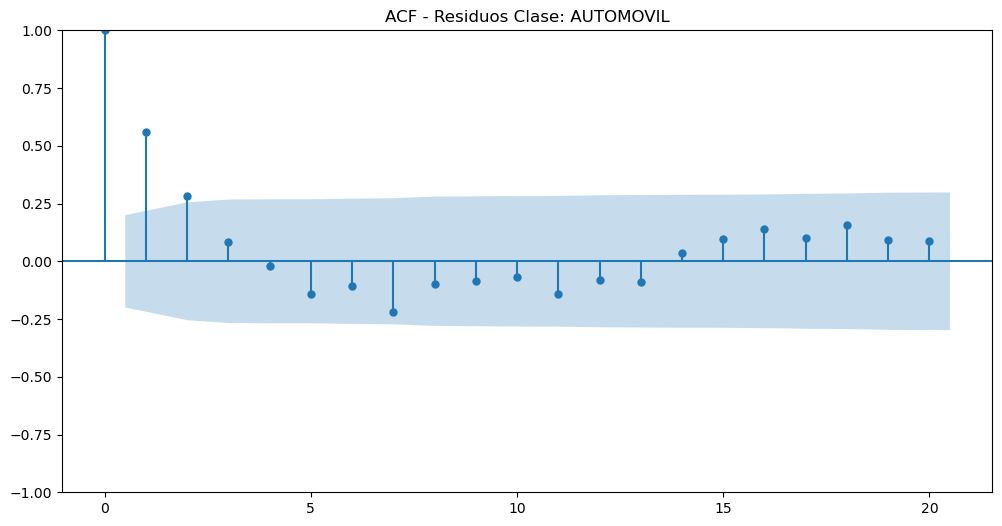

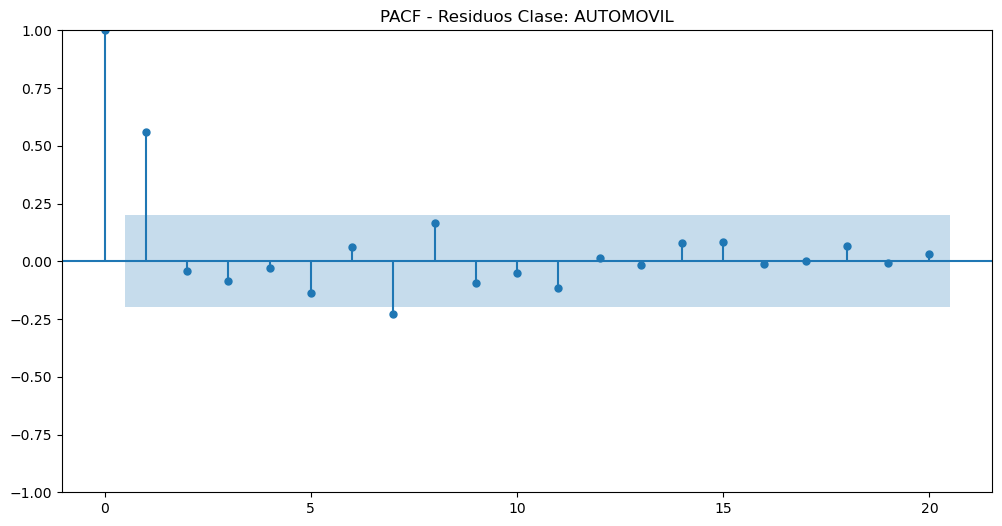

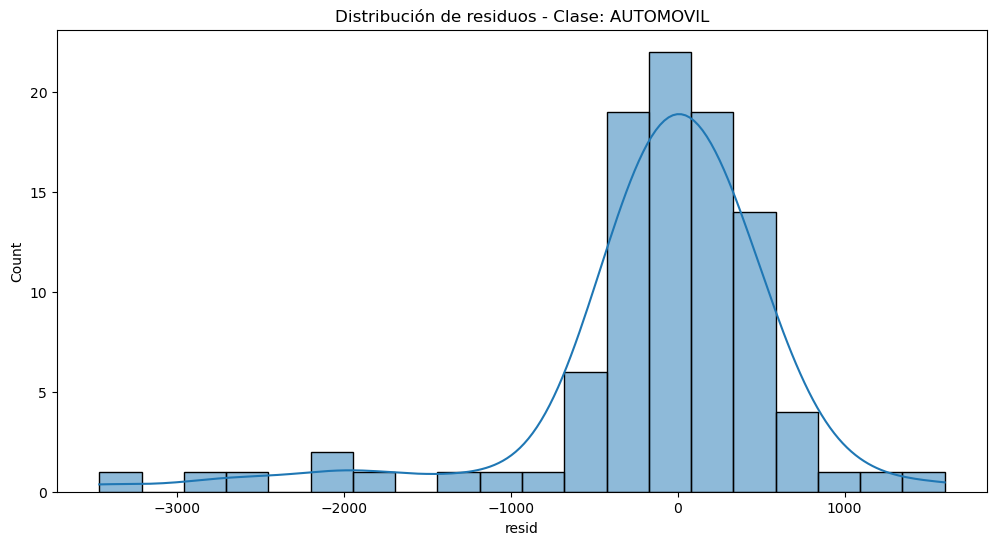

Pendiente: 2.00 comparendos por mes
R²: 0.049406
P-valor tendencia: 2.950869e-02
¿Tendencia significativa? Sí


Amplitud estacional: 714 comparendos
Variabilidad explicada por estacionalidad: 11.59%

Prueba ADF sobre la serie original
Estadístico ADF: -3.392720
P-valor: 1.120956e-02
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -4.819493
P-valor: 4.990369e-05
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   53.705421  8.458250e-10
12  73.978893  5.727785e-11
18  79.719857  9.592761e-10

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.132622
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 5.718094e-10
¿Residuos normales? No


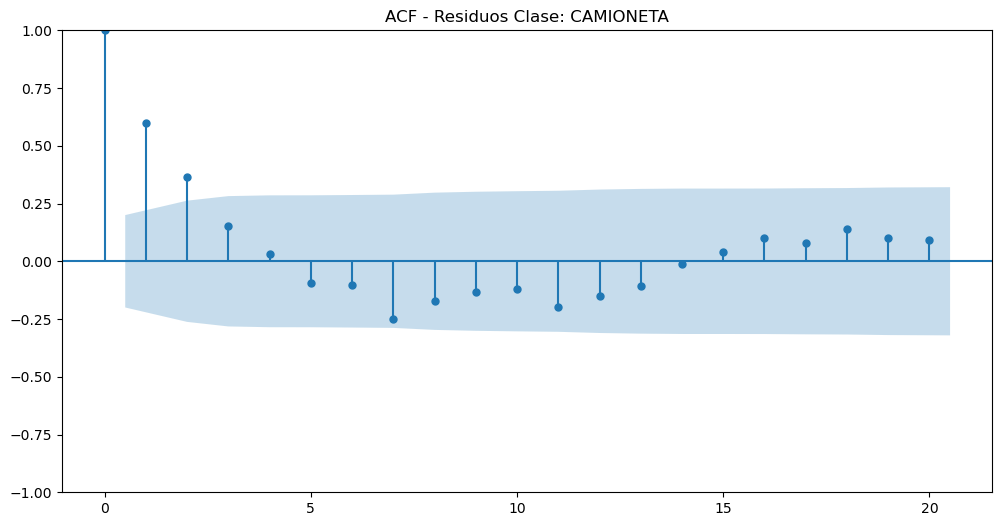

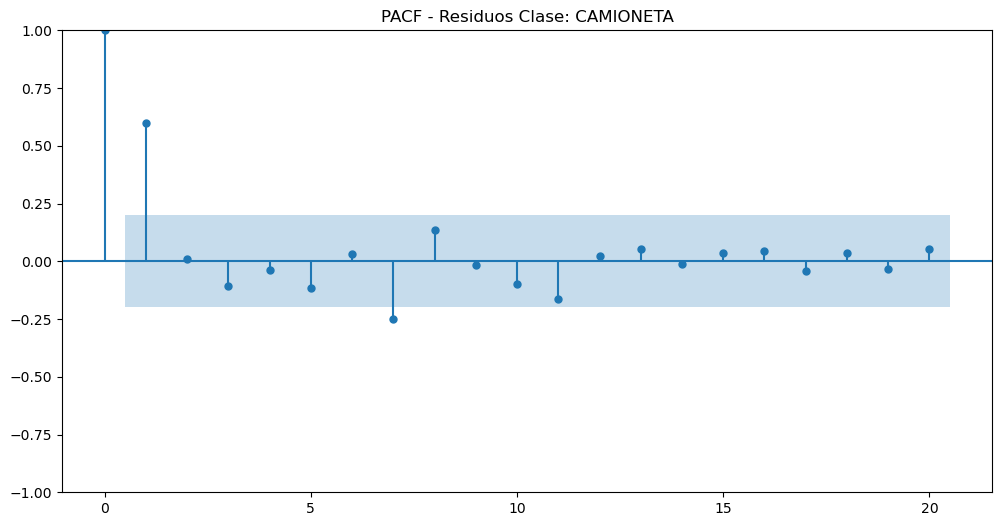

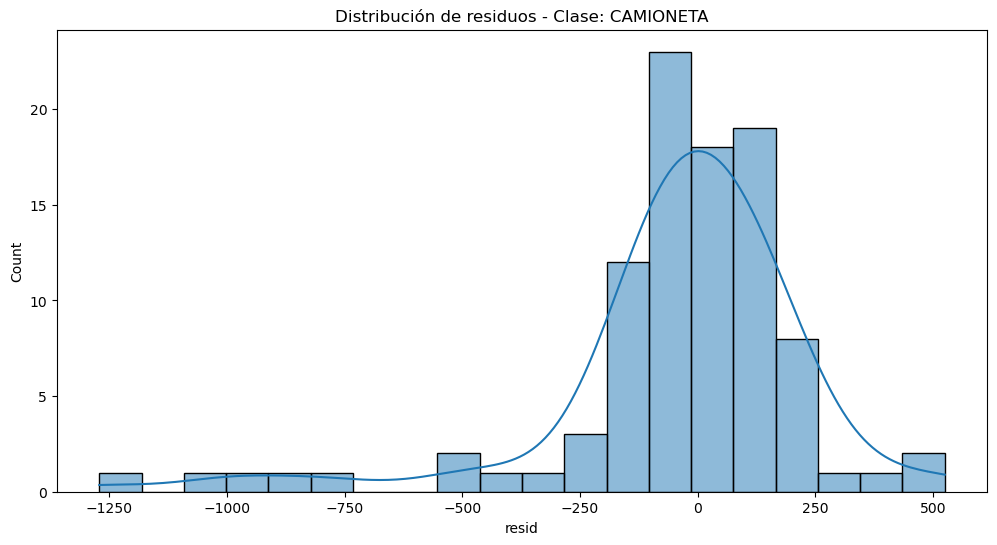

Pendiente: -2.72 comparendos por mes
R²: 0.639619
P-valor tendencia: 1.501601e-22
¿Tendencia significativa? Sí


Amplitud estacional: 250 comparendos
Variabilidad explicada por estacionalidad: 10.76%

Prueba ADF sobre la serie original
Estadístico ADF: -2.874968
P-valor: 4.833725e-02
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -4.456377
P-valor: 2.355824e-04
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat     lb_pvalue
6   68.785989  7.252094e-13
12  78.688726  7.336558e-12
18  81.262237  5.148434e-10

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.143875
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 1.334692e-11
¿Residuos normales? No


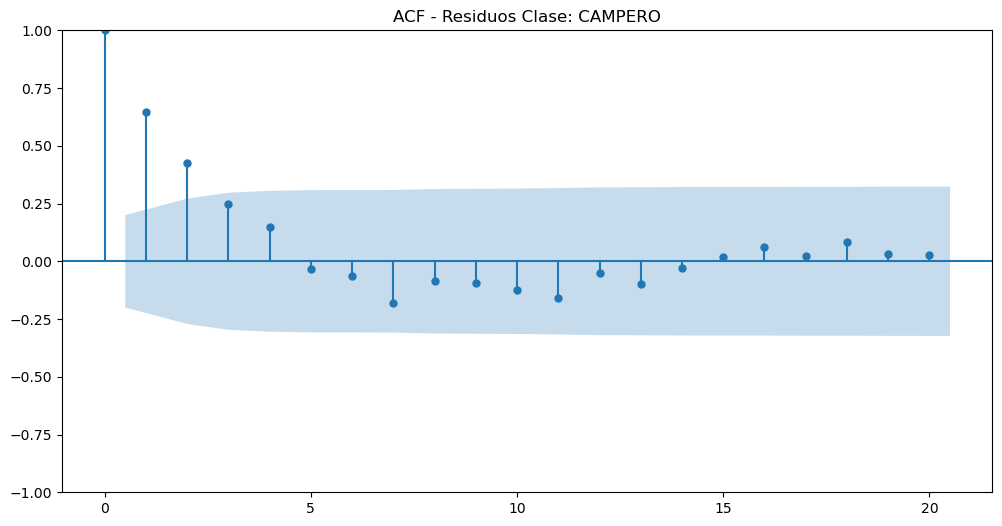

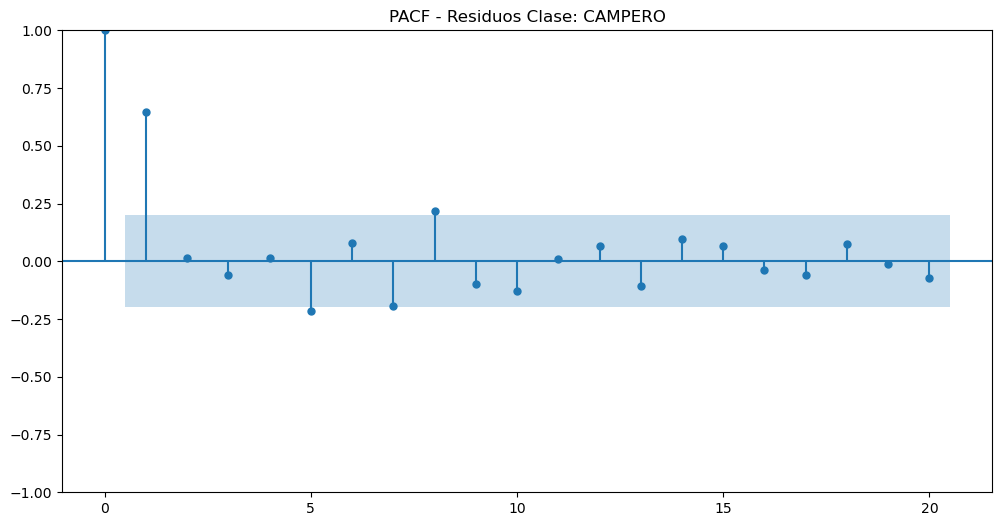

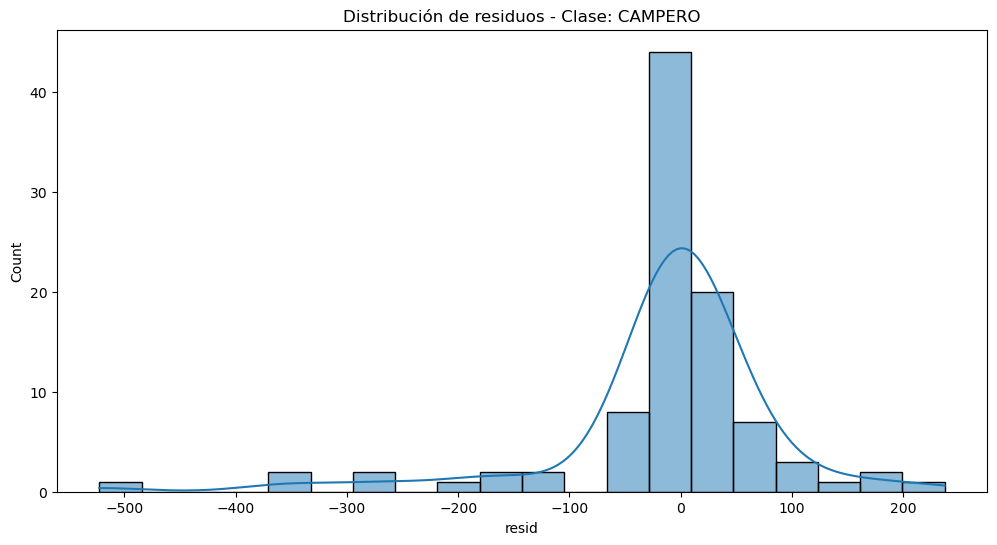

Pendiente: -6.69 comparendos por mes
R²: 0.617977
P-valor tendencia: 2.366881e-21
¿Tendencia significativa? Sí


Amplitud estacional: 556 comparendos
Variabilidad explicada por estacionalidad: 11.25%

Prueba ADF sobre la serie original
Estadístico ADF: -2.611989
P-valor: 9.054463e-02
Valores críticos:
  1%: -3.5019
  5%: -2.8928
  10%: -2.5835
La serie original no es estacionaria (tiene tendencia y/o estacionalidad)

Prueba ADF sobre los residuos
Estadístico ADF: -7.564333
P-valor: 2.953003e-11
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

La serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad



Prueba Ljung-Box
      lb_stat  lb_pvalue
6   14.344722   0.026014
12  35.945667   0.000331
18  42.854340   0.000839

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.907898
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 7.737139e-05
¿Residuos normales? No


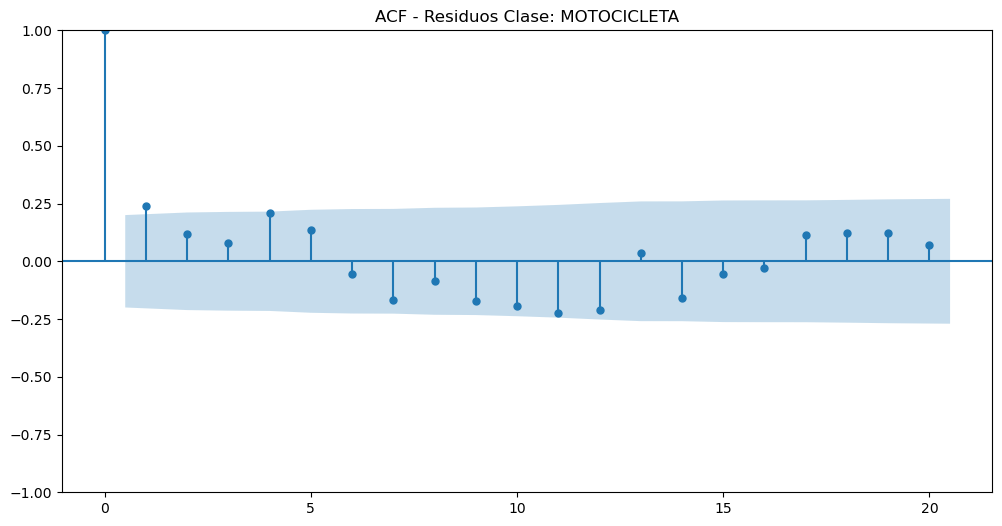

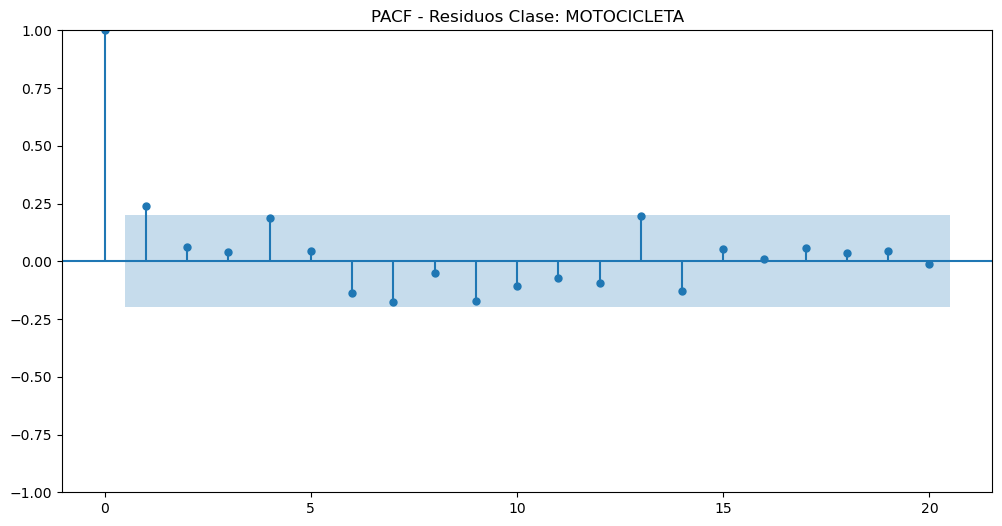

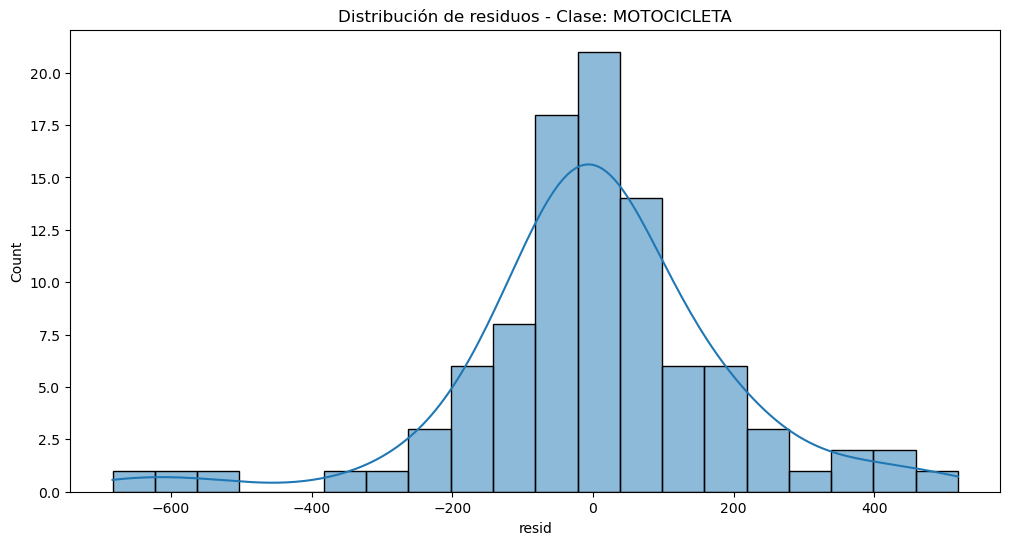

Pendiente: 0.34 comparendos por mes
R²: 0.043995
P-valor tendencia: 4.025919e-02
¿Tendencia significativa? Sí


Amplitud estacional: 178 comparendos
Variabilidad explicada por estacionalidad: 15.85%

Prueba ADF sobre la serie original
Estadístico ADF: -2.684135
P-valor: 7.682409e-02
Valores críticos:
  1%: -3.5027
  5%: -2.8932
  10%: -2.5836
La serie original no es estacionaria (tiene tendencia y/o estacionalidad)

Prueba ADF sobre los residuos
Estadístico ADF: -7.085693
P-valor: 4.544817e-10
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

La serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad



Prueba Ljung-Box
      lb_stat  lb_pvalue
6   17.960283   0.006332
12  36.739618   0.000246
18  37.620291   0.004347

¿Los residuos son ruido blanco? No
Prueba t (media cero) p-valor: 0.038110
¿Residuos centrados en cero? No

Shapiro-Wilk p-valor: 1.822838e-09
¿Residuos normales? No


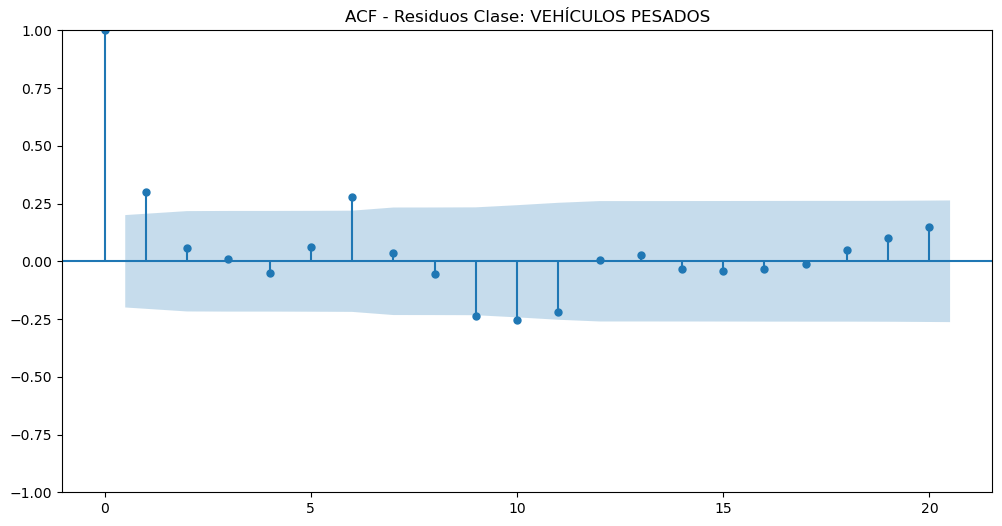

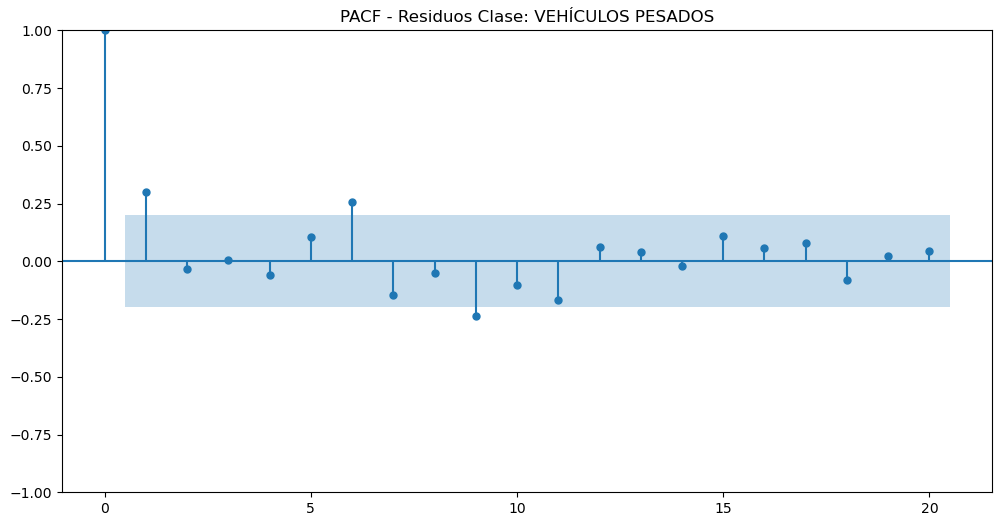

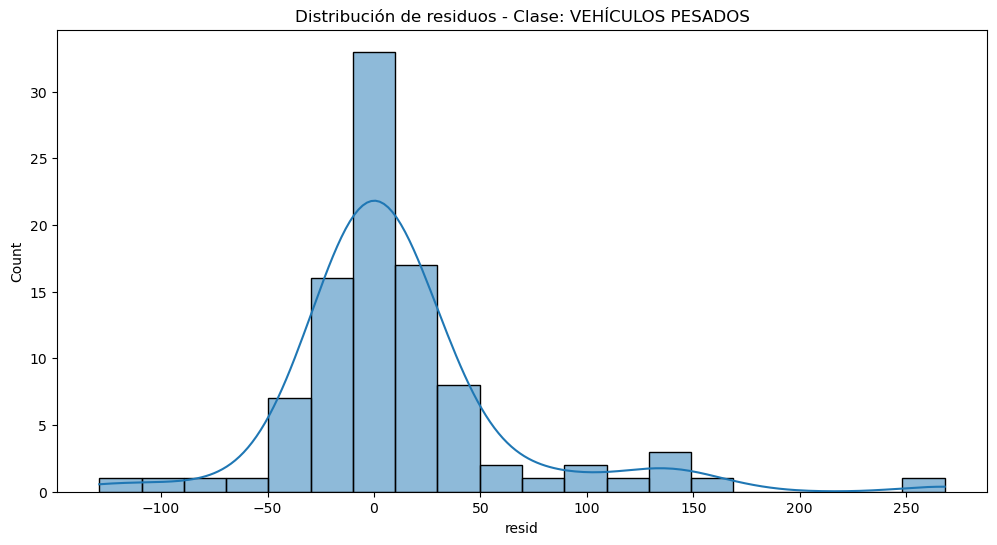

Pendiente: 0.01 comparendos por mes
R²: 0.813878
P-valor tendencia: 4.349499e-36
¿Tendencia significativa? Sí


Amplitud estacional: 4 comparendos
Variabilidad explicada por estacionalidad: 22.20%

Prueba ADF sobre la serie original
Estadístico ADF: -7.150219
P-valor: 3.155330e-10
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
La serie original es estacionaria

Prueba ADF sobre los residuos
Estadístico ADF: -8.414924
P-valor: 2.055980e-13
Valores críticos:
  1%: -3.5011
  5%: -2.8925
  10%: -2.5833
Los residuos son estacionarios

Tanto la serie original como los residuos son estacionarios



Prueba Ljung-Box
      lb_stat  lb_pvalue
6    3.854127   0.696409
12  17.889019   0.119102
18  21.784240   0.241705

¿Los residuos son ruido blanco? Sí
Prueba t (media cero) p-valor: 0.115892
¿Residuos centrados en cero? Sí

Shapiro-Wilk p-valor: 6.620906e-11
¿Residuos normales? No


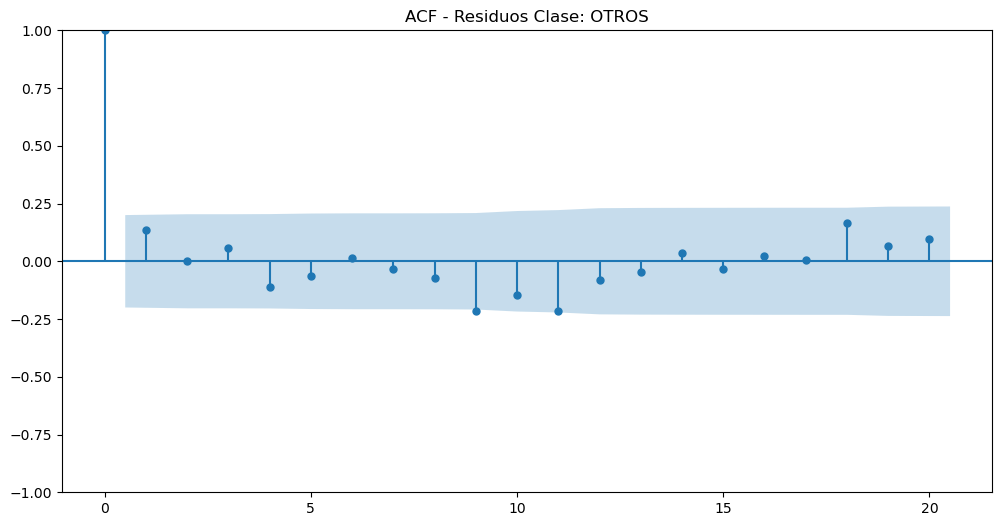

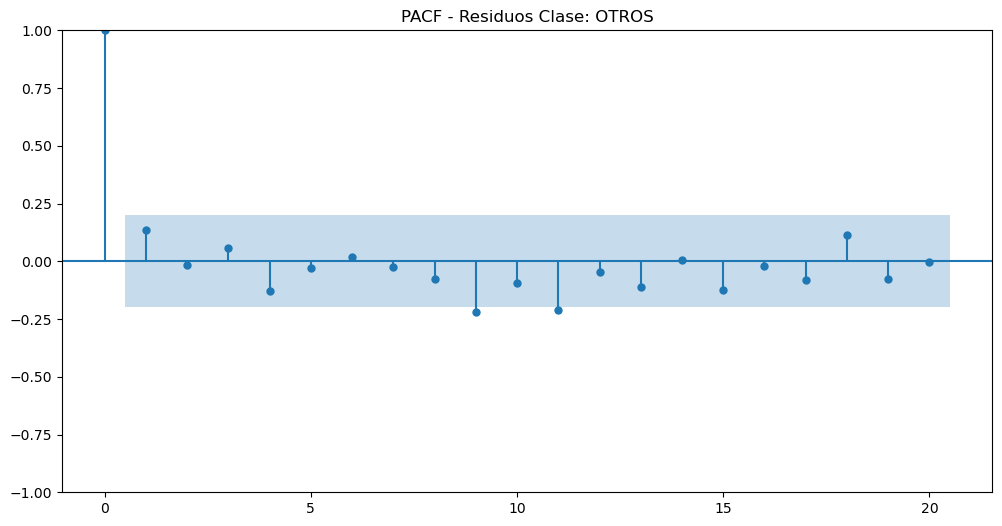

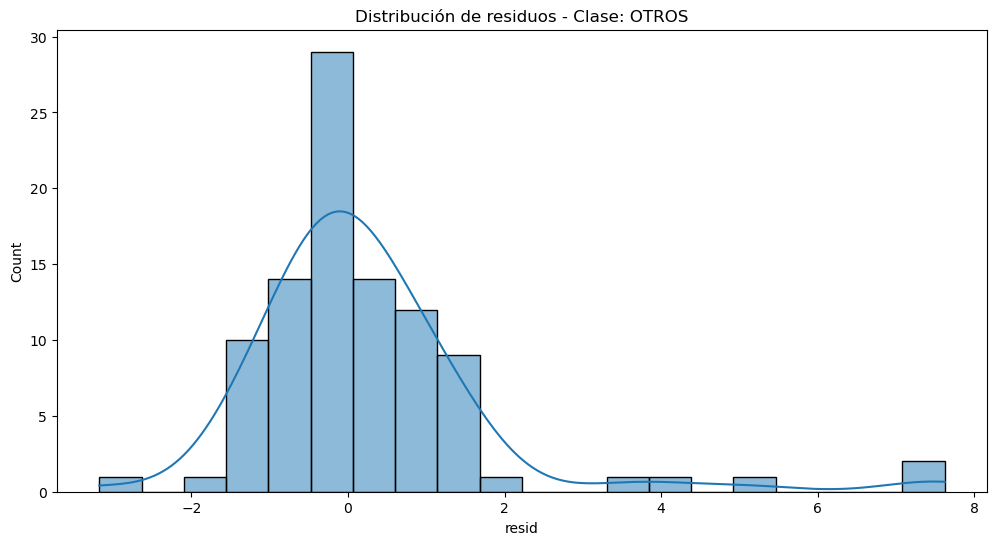

In [27]:
df_comparendos_electronicos_copy['CLASE_AGRUPADA'] = df_comparendos_electronicos_copy['CLASE_VEHICULO_INFRACTOR'].replace({
    'CAMION': 'VEHÍCULOS PESADOS',
    'BUS': 'VEHÍCULOS PESADOS',
    'MICROBUS': 'VEHÍCULOS PESADOS',
    'BUSETA': 'VEHÍCULOS PESADOS',
    'VOLQUETA': 'VEHÍCULOS PESADOS',
    'TRACTOCAMION': 'VEHÍCULOS PESADOS',
    'MOTOCARRO': 'OTROS',
    'CUATRIMOTO': 'OTROS',
    'NO REPORTADO': 'OTROS',
    'SIN CLASE': 'OTROS'
})

infracciones_por_mes_clase = df_comparendos_electronicos_copy.groupby(['año_mes', 'CLASE_AGRUPADA'])['CANTIDAD_INFRACCIONES'].sum().reset_index()

clases_descomposicion = df_comparendos_electronicos_copy['CLASE_AGRUPADA'].unique()

for clase in clases_descomposicion:
    
    serie_clase = infracciones_por_mes_clase[infracciones_por_mes_clase['CLASE_AGRUPADA'] == clase].copy()
    serie_clase = serie_clase.set_index('año_mes')['CANTIDAD_INFRACCIONES']
    serie_clase.index = pd.to_datetime(serie_clase.index)
    serie_clase = serie_clase.asfreq('MS')
    serie_clase = serie_clase.fillna(0)
    
    descomposicion_clase = STL(serie_clase, period=12, robust=True).fit()
    
    tendencia_clase = descomposicion_clase.trend.dropna()
    x = np.arange(len(tendencia_clase))
    pendiente_clase, intercepto_clase, r_value_clase, p_valor_tendencia_clase, std_err_clase = stats.linregress(x, tendencia_clase.values)
    r_cuadrado_clase = r_value_clase ** 2
    regresion_vals_clase = pendiente_clase * x + intercepto_clase
    
    fig_tendencia_clase = go.Figure()
    fig_tendencia_clase.add_trace(go.Scatter(x=tendencia_clase.index, y=tendencia_clase.values, mode='lines+markers', name='Tendencia', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Tendencia: %{y:,.0f}<extra></extra>', showlegend=False))
    fig_tendencia_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_clase.sum()):,}', showlegend=True))
    fig_tendencia_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(tendencia_clase.std()):,}', showlegend=True))
    fig_tendencia_clase.add_trace(go.Scatter(x=[tendencia_clase.index[0], tendencia_clase.index[-1]], y=[tendencia_clase.mean(), tendencia_clase.mean()], mode='lines', name=f'Promedio: {int(tendencia_clase.mean()):,}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_tendencia_clase.add_trace(go.Scatter(x=tendencia_clase.index, y=regresion_vals_clase, mode='lines', name=f'Regresión lineal (R² = {r_cuadrado_clase:.3f})', line=dict(color='orange', width=2, dash='solid'), showlegend=True))
    fig_tendencia_clase.add_trace(go.Scatter(x=[tendencia_clase.idxmax()], y=[tendencia_clase.max()], mode='markers', name=f'Máximo: {tendencia_clase.idxmax().strftime("%Y-%m")} ({int(tendencia_clase.max()):,})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_tendencia_clase.add_trace(go.Scatter(x=[tendencia_clase.idxmin()], y=[tendencia_clase.min()], mode='markers', name=f'Mínimo: {tendencia_clase.idxmin().strftime("%Y-%m")} ({int(tendencia_clase.min()):,})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_tendencia_clase.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_tendencia_clase.update_layout(title=dict(text=f'Tendencia de Comparendos - Clase: {clase}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Tendencia (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_tendencia_clase.show()
    
    print(f"Pendiente: {pendiente_clase:.2f} comparendos por mes")
    print(f"R²: {r_cuadrado_clase:.6f}")
    print(f"P-valor tendencia: {p_valor_tendencia_clase:.6e}")
    print(f"¿Tendencia significativa? {'Sí' if p_valor_tendencia_clase < 0.05 else 'No'}")
    
    estacionalidad_clase = descomposicion_clase.seasonal.dropna()
    amplitud_estacional_clase = estacionalidad_clase.max() - estacionalidad_clase.min()
    var_total_clase = descomposicion_clase.trend.var() + descomposicion_clase.seasonal.var() + descomposicion_clase.resid.var()
    varianza_estacional_clase = descomposicion_clase.seasonal.var() / var_total_clase * 100
    
    fig_estacionalidad_clase = go.Figure()
    fig_estacionalidad_clase.add_trace(go.Scatter(x=estacionalidad_clase.index, y=estacionalidad_clase.values, mode='lines+markers', name='Estacionalidad', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Estacionalidad: %{y:,.2f}<extra></extra>', showlegend=False))
    fig_estacionalidad_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_clase.sum()):,}', showlegend=True))
    fig_estacionalidad_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(estacionalidad_clase.std()):.0f}', showlegend=True))
    fig_estacionalidad_clase.add_trace(go.Scatter(x=[estacionalidad_clase.index[0], estacionalidad_clase.index[-1]], y=[estacionalidad_clase.mean(), estacionalidad_clase.mean()], mode='lines', name=f'Promedio: {estacionalidad_clase.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_estacionalidad_clase.add_trace(go.Scatter(x=[estacionalidad_clase.idxmax()], y=[estacionalidad_clase.max()], mode='markers', name=f'Máximo: {estacionalidad_clase.idxmax().strftime("%Y-%m")} ({estacionalidad_clase.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_estacionalidad_clase.add_trace(go.Scatter(x=[estacionalidad_clase.idxmin()], y=[estacionalidad_clase.min()], mode='markers', name=f'Mínimo: {estacionalidad_clase.idxmin().strftime("%Y-%m")} ({estacionalidad_clase.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_estacionalidad_clase.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_estacionalidad_clase.update_layout(title=dict(text=f'Estacionalidad de Comparendos - Clase: {clase}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Estacionalidad (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_estacionalidad_clase.show()
    
    print(f"Amplitud estacional: {amplitud_estacional_clase:.0f} comparendos")
    print(f"Variabilidad explicada por estacionalidad: {varianza_estacional_clase:.2f}%")
    

    print("\nPrueba ADF sobre la serie original")
    resultado_adf_original = adfuller(serie_clase.dropna(), autolag='AIC')
    print(f"Estadístico ADF: {resultado_adf_original[0]:.6f}")
    print(f"P-valor: {resultado_adf_original[1]:.6e}")
    print("Valores críticos:")
    for key, value in resultado_adf_original[4].items():
        print(f"  {key}: {value:.4f}")
    if resultado_adf_original[1] < 0.05:
        print("La serie original es estacionaria")
    else:
        print("La serie original no es estacionaria (tiene tendencia y/o estacionalidad)")
    
    print("\nPrueba ADF sobre los residuos")
    resultado_adf_residuos = adfuller(descomposicion_clase.resid.dropna(), autolag='AIC')
    print(f"Estadístico ADF: {resultado_adf_residuos[0]:.6f}")
    print(f"P-valor: {resultado_adf_residuos[1]:.6e}")
    print("Valores críticos:")
    for key, value in resultado_adf_residuos[4].items():
        print(f"  {key}: {value:.4f}")
    if resultado_adf_residuos[1] < 0.05:
        print("Los residuos son estacionarios")
    else:
        print("Los residuos no son estacionarios")
    
    if resultado_adf_original[1] >= 0.05 and resultado_adf_residuos[1] < 0.05:
        print("\nLa serie original no es estacionaria, pero los residuos sí lo son → la descomposición STL capturó correctamente tendencia y estacionalidad")
    elif resultado_adf_original[1] < 0.05 and resultado_adf_residuos[1] < 0.05:
        print("\nTanto la serie original como los residuos son estacionarios")
    else:
        print("\nLa descomposición no logró eliminar completamente la no estacionariedad")
    

    residuos_clase = descomposicion_clase.resid.dropna()
    p_valor_ljung_clase = acorr_ljungbox(residuos_clase, lags=[12], return_df=True)['lb_pvalue'].iloc[0]
    t_stat_clase, p_valor_media_clase = stats.ttest_1samp(residuos_clase, 0)
    
    fig_residuos_clase = go.Figure()
    fig_residuos_clase.add_trace(go.Scatter(x=residuos_clase.index, y=residuos_clase.values, mode='lines+markers', name='Residuos', line=dict(color='cornflowerblue', width=2), marker=dict(size=4), hovertemplate='Fecha: %{x}<br>Residuo: %{y:,.2f}<extra></extra>', showlegend=False))
    fig_residuos_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Total: {int(serie_clase.sum()):,}', showlegend=True))
    fig_residuos_clase.add_trace(go.Scatter(x=[None], y=[None], mode='none', name=f'Std: {int(residuos_clase.std()):.0f}', showlegend=True))
    fig_residuos_clase.add_trace(go.Scatter(x=[residuos_clase.index[0], residuos_clase.index[-1]], y=[residuos_clase.mean(), residuos_clase.mean()], mode='lines', name=f'Promedio: {residuos_clase.mean():.2f}', line=dict(color='red', width=1.4, dash='dot'), showlegend=True, hoverinfo='none'))
    fig_residuos_clase.add_trace(go.Scatter(x=[residuos_clase.idxmax()], y=[residuos_clase.max()], mode='markers', name=f'Máximo: {residuos_clase.idxmax().strftime("%Y-%m")} ({residuos_clase.max():.2f})', marker=dict(size=8, color='red', symbol='circle'), hoverinfo='none'))
    fig_residuos_clase.add_trace(go.Scatter(x=[residuos_clase.idxmin()], y=[residuos_clase.min()], mode='markers', name=f'Mínimo: {residuos_clase.idxmin().strftime("%Y-%m")} ({residuos_clase.min():.2f})', marker=dict(size=8, color='green', symbol='circle'), hoverinfo='none'))
    fig_residuos_clase.add_vrect(x0="2020-03", x1="2020-12", fillcolor="red", opacity=0.1, line_width=0, annotation_text="COVID-19", annotation_position="top left", annotation=dict(font_size=12, font_color="red"))
    fig_residuos_clase.update_layout(title=dict(text=f'Residuos de Comparendos - Clase: {clase}', x=0.5, font=dict(size=16, weight='bold')), xaxis_title=dict(text='Año', font=dict(weight='bold')), yaxis_title=dict(text='Residuos (Comparendos)', font=dict(weight='bold')), template='plotly_white', hovermode='x unified', legend=dict(x=1, y=1, xanchor='center', yanchor='top', bgcolor='rgba(255,255,255,0.5)', font=dict(size=12)), width=1055, height=500)
    fig_residuos_clase.show()
    
    resultado_ljung_clase = acorr_ljungbox(residuos_clase, lags=[6, 12, 18], return_df=True)
    print("\nPrueba Ljung-Box")
    print(resultado_ljung_clase)
    p_valor_ljung_clase = resultado_ljung_clase['lb_pvalue'].iloc[1]
    print(f"\n¿Los residuos son ruido blanco? {'Sí' if p_valor_ljung_clase > 0.05 else 'No'}")
    print(f"Prueba t (media cero) p-valor: {p_valor_media_clase:.6f}")
    print(f"¿Residuos centrados en cero? {'Sí' if p_valor_media_clase > 0.05 else 'No'}")
    
    stat_clase, p_shapiro_clase = stats.shapiro(residuos_clase)
    print(f"\nShapiro-Wilk p-valor: {p_shapiro_clase:.6e}")
    print(f"¿Residuos normales? {'Sí' if p_shapiro_clase > 0.05 else 'No'}")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_acf(residuos_clase, ax=ax)
    plt.title(f"ACF - Residuos Clase: {clase}")
    plt.show()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    plot_pacf(residuos_clase, ax=ax)
    plt.title(f"PACF - Residuos Clase: {clase}")
    plt.show()
    
    plt.figure(figsize=(12,6))
    sns.histplot(residuos_clase, bins=20, kde=True)
    plt.title(f"Distribución de residuos - Clase: {clase}")
    plt.show()
    
    display(HTML("<hr style='border: 2px solid #696969; margin: 20px 0;'>"))

**AUTOMÓVIL**

- Tendencia decreciente significativa (-5.68 comparendos por mes). R² bajo (6.0%) indica que la tendencia lineal explica poca variabilidad. Serie original estacionaria. Residuos no son ruido blanco pero están centrados en cero. Amplitud estacional de 1,849 comparendos (la más alta entre todas las clases).

- **Análisis de Autocorrelación (ACF y PACF) - AUTOMÓVIL**: Estas gráficas miden si los errores de un período están relacionados con los de períodos anteriores, lo que permitiría mejorar el modelo capturando esa dependencia.

    - **ACF (Autocorrelation Function):** Se observa una correlación significativa y positiva en el **Lag 1** y el **Lag 2**, que sobresalen claramente de la banda de confianza azul. La caída gradual en el ACF sugiere la presencia de un componente **Autorregresivo (AR)** pendiente en los residuos, lo que indica que el modelo actual no ha capturado toda la estructura de dependencia temporal de la clase automóvil.

    - **PACF (Partial Autocorrelation Function):** Muestra un pico fuerte en el **Lag 1** y luego se corta abruptamente, con la mayoría de los demás picos dentro de las bandas de confianza. Este es un patrón clásico de un proceso **AR(1)** o **AR(2)** que aún está presente en los residuos, lo que sugiere que añadir términos autorregresivos al modelo podría mejorar su capacidad predictiva.

    - **Hallazgo:** Los residuos **no son ruido blanco**, ya que existe información sistemática (correlación serial) que el modelo de descomposición no está explicando completamente para la clase automóvil.

- **Gráfico de la distribución de los residuos - AUTOMÓVIL**: Esta gráfica evalúa la normalidad, la simetría y el sesgo de los errores del modelo para los automóviles.

    - Visualmente, la distribución parece estar centrada cerca de **0**, lo cual es un buen indicio de que el modelo no tiene un sesgo sistemático importante en la magnitud de sus predicciones.
    - La mayor parte de los datos sigue una forma de campana, pero se observa una **cola larga hacia la izquierda (sesgo negativo)**, lo que indica la presencia de residuos negativos importantes (entre -2000 y -3500).
    - Esto significa que hay meses específicos (como los ocurridos durante la pandemia de 2020) donde el modelo **sobreestimó** drásticamente la cantidad de comparendos de automóviles, posiblemente debido a eventos atípicos o choques externos que el modelo no contempla, como las restricciones masivas de movilidad o los cierres viales atípicos que redujeron drásticamente el tránsito de estos vehículos.


---

**CAMIONETA**

- Tendencia **creciente** significativa (+2.00 comparendos por mes), única junto con vehículos pesados y OTROS que muestran aumento. R² bajo (4.9%). Serie estacionaria. Amplitud estacional de 714 comparendos.

- **Análisis de Autocorrelación (ACF y PACF) - CAMIONETA**: Estas gráficas muestran una estructura de dependencia temporal muy marcada en los residuos de la clase camioneta, similar a la observada en automóviles pero con algunas particularidades.

    - **ACF (Autocorrelation Function):** Se observan picos significativos que sobresalen de las bandas de confianza en los **Lags 1 y 2**. El hecho de que el ACF disminuya lentamente sugiere que los residuos de las camionetas todavía guardan una memoria importante de los meses anteriores, lo que indica que el modelo actual no ha logrado capturar completamente la dependencia temporal de corto plazo.

    - **PACF (Partial Autocorrelation Function):** Muestra un pico muy fuerte en el **Lag 1** y otro significativo (aunque negativo) en el **Lag 7**. El corte abrupto después del primer lag refuerza la idea de que existe un componente **AR(1)** no resuelto en los residuos, mientras que el pico en el lag 7 sugiere la posible presencia de una estacionalidad rezagada no capturada.

    - **Hallazgos:** Los residuos de las camionetas presentan **autocorrelación serial** significativa. Hay patrones predecibles en los errores que podrían ser incorporados mediante términos autorregresivos adicionales para mejorar el ajuste predictivo de esta clase de vehículo.


- **Gráfico de la distribución de los residuos - CAMIONETA**: La distribución está centrada cerca de cero, lo que indica que, en promedio, el modelo no subestima ni sobreestima de forma sistemática los comparendos de las camionetas. Se observa una distribución más concentrada que en el caso de los automóviles (la escala del eje X llega hasta -1250, comparado con los -3500 de los automóviles), lo que sugiere que el modelo es relativamente más preciso para las camionetas. Sin embargo, persiste un **sesgo negativo (cola a la izquierda)**, con errores negativos importantes cercanos a -1000 y -1250. Esto significa que existen meses específicos donde la cantidad real de comparendos de camionetas fue mucho menor a lo proyectado por el modelo, posiblemente debido a eventos atípicos como la pandemia de 2020, cierres viales o cambios en los patrones de movilidad que afectaron de manera particular a este tipo de vehículo.

---

**CAMPERO** 

- Tendencia decreciente significativa (-2.72 comparendos por mes). R² muy alto (64.0%), el segundo más alto, indicando que la tendencia lineal explica la mayor parte de la variabilidad. Serie estacionaria. Amplitud estacional de 250 comparendos.

- **Análisis de Autocorrelación (ACF y PACF) - CAMPERO**: Las gráficas de autocorrelación para la clase campero son particularmente reveladoras y muestran el peor desempeño entre las clases analizadas en términos de dependencia temporal residual.

    - **ACF (Autocorrelation Function):** Muestra una caída muy lenta y picos significativos en los **Lags 1 y 2**. El hecho de que las barras tarden tanto en entrar en la zona de confianza indica que los residuos de los camperos tienen una **fuerte inercia** o persistencia temporal, lo que significa que el error de un mes influye de manera prolongada en los errores de los meses siguientes.

    - **PACF (Partial Autocorrelation Function):** El pico en el **Lag 1** es extremadamente alto (superando el 0.6). Además, se observan picos negativos significativos en los **Lags 5 y 7**, que sugieren la presencia de patrones estacionales o cíclicos no capturados por el modelo.

    - **Hallazgo:** Los residuos de los camperos están altamente correlacionados. Un pico tan alto en el PACF lag 1 sugiere que el modelo actual está ignorando casi por completo la relación inmediata entre un mes y el anterior para esta clase de vehículo. De las clases analizadas, el campero es la que más se aleja del ideal de ruido blanco, lo que indica que el modelo de descomposición tiene mayores dificultades para capturar la dinámica temporal de este tipo de vehículo.
    
- **Gráfico de la distribución de los residuos - CAMPERO**: La gran mayoría de los errores son muy pequeños y están concentrados en el bin central alrededor de 0, con una frecuencia superior a 40. Esto sugiere que el modelo acierta razonablemente bien en la mayoría de los meses para los camperos. Sin embargo, la distribución presenta **leptocurtosis**, lo que en estadística se asocia con una alta probabilidad de valores extremos en comparación con una distribución normal. Al igual que en las clases anteriores (automóviles y camionetas), se observa una **cola larga hacia la izquierda**, con errores que llegan hasta -500. Dado que la escala general de esta serie es más pequeña que la de los automóviles, un error de -500 es proporcionalmente muy alto y representa meses donde el modelo sobreestimó drásticamente la cantidad de comparendos de camperos, posiblemente por eventos atípicos como la pandemia o cierres viales que redujeron significativamente la circulación de este tipo de vehículo.

---

**MOTOCICLETA** 

- Tendencia decreciente significativa (-6.69 comparendos por mes), la más pronunciada en magnitud absoluta junto con automóvil. R² muy alto (61.8%). La serie original **no es estacionaria**, pero los residuos sí lo son, indicando que la descomposición STL capturó correctamente tendencia y estacionalidad. Amplitud estacional de 556 comparendos.

- **Análisis de Autocorrelación (ACF y PACF) - MOTOCICLETA**: Lo primero que destaca en las gráficas de autocorrelación para la clase motocicleta es que las barras de correlación son mucho más cortas que en los casos de automóvil o campero, lo que indica un mejor desempeño del modelo para esta categoría.

    - **ACF (Autocorrelation Function):** El pico en el **Lag 1** es apenas significativo, ubicándose justo en el borde de la banda de confianza. Esta es una excelente señal, ya que indica que la mayor parte de la dependencia temporal de corto plazo ha sido capturada por el modelo para las motocicletas.

    - **PACF (Partial Autocorrelation Function):** Muestra un comportamiento similar, con picos muy controlados dentro de los límites de significancia. No hay una estructura autorregresiva (AR) tan evidente como en las otras categorías. Se observa un pequeño salto en el **Lag 13**, que en datos mensuales suele ser ruido o una ligera estacionalidad residual de un año y un mes, pero no alcanza niveles problemáticos.

    - **Hallazgo:** De todas las clases analizadas, las motocicletas son las que más se aproximan al **ruido blanco**. Los errores del modelo son mayoritariamente independientes entre sí, lo que sugiere que la descomposición STL capturó adecuadamente la estructura temporal de esta categoría de vehículo.

- **Gráfico de la distribución de los residuos - MOTOCICLETA**: La distribución de los residuos para las motocicletas es notablemente más **simétrica** que en las clases anteriores. Aunque sigue existiendo una ligera cola hacia la izquierda, la curva de densidad (línea azul) se ajusta mucho mejor a la forma de las barras del histograma, aproximándose más a una distribución normal. Los residuos están muy bien centrados en **0**, lo que indica que el modelo no tiene un sesgo de predicción significativo para las motocicletas. Persisten algunos valores atípicos negativos (alrededor de -600), pero son menos frecuentes en comparación con el volumen total de datos y con las otras clases analizadas, lo que confirma que el modelo es relativamente preciso y confiable para esta clase de vehículo. Este buen desempeño contrasta con el comportamiento atípico observado en el análisis descriptivo, donde las motocicletas presentaron un pico inusual durante la pandemia de 2020.

---

**VEHÍCULOS PESADOS** 

- Tendencia **creciente** significativa (+0.34 comparendos por mes), aunque de magnitud muy pequeña. R² bajo (4.4%). La serie original **no es estacionaria**, pero los residuos sí lo son. Presenta la mayor amplitud estacional relativa (15.85% de variabilidad explicada) después de OTROS. **Los residuos no están centrados en cero** (p-valor = 0.0381), indicando sesgo sistemático en el modelo.

- **Análisis de Autocorrelación (ACF y PACF) - VEHÍCULOS PESADOS**: A diferencia de las otras categorías analizadas, los vehículos pesados suelen tener dinámicas más ligadas a la actividad económica industrial y de carga, lo que se refleja en patrones de autocorrelación particulares.

    - **ACF (Autocorrelation Function):** Se observan picos significativos que sobresalen de las bandas de confianza en los **Lags 1, 6 y 9**. La presencia de un pico en el lag 6 es especialmente interesante, ya que sugiere una posible **estacionalidad semestral** o un ciclo de mediano plazo (cada 6 meses) que el modelo de descomposición no está capturando completamente para los vehículos pesados.

    - **PACF (Partial Autocorrelation Function):** Muestra picos claros en el **Lag 1** (correlación directa con el mes anterior) y nuevamente en los **Lags 6 y 9**. El hecho de que el lag 6 sea tan marcado en la correlación parcial refuerza la idea de que existe un patrón cíclico específico en el transporte de carga que el modelo actual ignora por completo.

    - **Hallazgo:** Los residuos de los vehículos pesados no son ruido blanco. Existe una estructura de dependencia temporal relevante, especialmente de carácter semestral (lag 6), lo que indica que el modelo podría beneficiarse significativamente de la inclusión de un componente estacional o de órdenes autorregresivos más altos para capturar estos ciclos de mediano plazo asociados a la actividad económica.

- **Gráfico de la distribución de los residuos - VEHÍCULOS PESADOS**: La distribución de los residuos para los vehículos pesados está muy bien centrada en **0**, con una gran concentración de datos en los bins centrales. Esto sugiere que, para la mayoría de los meses, el modelo es bastante preciso y no presenta errores sistemáticos importantes. A diferencia de los automóviles, camionetas y camperos, esta distribución es mucho más **simétrica** y no presenta esa cola izquierda tan dramática observada en aquellas categorías. Esto indica que los vehículos pesados no sufren tanto de caídas súbitas e inexplicables en sus volúmenes de infracciones, posiblemente porque su movilidad está menos sujeta a factores como el confinamiento por pandemia o los cierres viales atípicos. Sin embargo, se observa un valor atípico hacia la derecha (cerca de **250**), lo que representa un mes específico donde hubo un pico de registros de vehículos pesados que el modelo no previó, correspondiendo a una subestimación por parte del modelo, posiblemente relacionado con un aumento de la actividad de carga o transporte en algún período particular.

---

**OTROS** 

- Tendencia **creciente** significativa (+0.01 comparendos por mes), con R² extremadamente alto (81.4%). Es la clase con la menor amplitud estacional en términos absolutos (4 comparendos) pero la mayor proporcionalmente (22.20%). **Los residuos son ruido blanco** (única clase donde ocurre), indicando que el modelo capturó toda la estructura temporal. Serie original estacionaria.

- **Análisis de Autocorrelación (ACF y PACF) - OTROS**: A diferencia de los automóviles o camperos, donde las barras de error eran significativamente altas, en la clase OTROS se observa un comportamiento mucho más controlado y cercano al ideal estadístico.

    - **ACF (Autocorrelation Function):** Casi todos los picos se encuentran **dentro de las bandas de confianza** (la zona sombreada azul). Solo hay pequeñas salidas insignificantes en los lags 9 y 18, que no alcanzan niveles problemáticos. Esto indica que no existe una memoria lineal fuerte que el modelo esté ignorando para esta categoría de vehículos.

    - **PACF (Partial Autocorrelation Function):** Al igual que en el ACF, los valores son muy bajos y se mantienen dentro de los límites de significancia. No hay un "pico dominante" en el lag 1, lo que sugiere que el componente Autorregresivo (p) está bien especificado o que la serie de la clase OTROS es intrínsecamente más aleatoria y menos predecible que otras categorías.

    - **Hallazgo:** Los residuos de la clase OTROS son los que más se acercan al comportamiento de **ruido blanco** entre todas las clases analizadas. El modelo de descomposición ha logrado extraer casi toda la información predecible de la serie temporal correspondiente a motocarros, cuatrimotos, vehículos no reportados y sin clase.

- **Gráfico de la distribución de los residuos - OTROS**: Se destaca que la escala del eje X es minúscula (va de -3 a 8). En comparación con los errores de -3500 en los automóviles o -500 en los camperos, esto indica que, por un lado, el volumen de datos de la clase OTROS es muy pequeño (solo 980 infracciones en total) y, por otro lado, que el modelo es extremadamente preciso para esta categoría en términos relativos. La distribución tiene una forma de campana muy clara y es **leptocúrtica** (muy alta y puntiaguda en el centro), lo que significa que la inmensa mayoría de los errores son prácticamente cero y se concentran alrededor de la media. Se observan un par de valores atípicos hacia la derecha (cerca de 4 y 8), que representan meses donde hubo un registro inusualmente alto de "otros" vehículos. Sin embargo, dada la escala reducida y la baja frecuencia de estos valores atípicos, no comprometen la validez general del modelo, que se comporta de manera excelente para esta clase.

---

**Tendencias diferenciadas**:
- **Decrecientes**: AUTOMÓVIL (-5.68), MOTOCICLETA (-6.69), CAMPERO (-2.72)
- **Crecientes**: CAMIONETA (+2.00), VEHÍCULOS PESADOS (+0.34), OTROS (+0.01)

**Calidad del ajuste (R²)**:
- **Muy alto (>60%)**: CAMPERO (64.0%), MOTOCICLETA (61.8%), OTROS (81.4%)
- **Bajo (<10%)**: AUTOMÓVIL (6.0%), CAMIONETA (4.9%), VEHÍCULOS PESADOS (4.4%)

**Estacionariedad**: Solo MOTOCICLETA y VEHÍCULOS PESADOS requirieron la descomposición para volverse estacionarias; las demás ya lo eran.

**Residuos**: Solo OTROS cumple con ruido blanco. VEHÍCULOS PESADOS es la única clase con sesgo en la media de los residuos.

---

**Hallazgos:**

- Las motocicletas y automóviles lideran la disminución, muestran las tendencias decrecientes más pronunciadas (-6.69 y -5.68 comparendos por mes respectivamente), lo que sugiere una mejora en el comportamiento de estos conductores o cambios en la fiscalización.

- Camionetas y vehículos pesados muestran tendencias crecientes, debido a que son las únicas clases con aumentos significativos, aunque de magnitud pequeña (+2.00 y +0.34), lo que podría indicar un problema creciente en estos segmentos.

- OTROS tiene el mejor ajuste del modelo con R² de 81.4% y residuos ruido blanco, es la clase donde la descomposición STL capturó perfectamente la estructura temporal, a pesar de su bajo volumen.

- Es la única clase con residuos no centrados en cero, indicando un sesgo sistemático que sugiere la necesidad de variables adicionales o un modelo más complejo.

- La estacionalidad es moderada en todas las clases con valores entre 10.76% y 22.20%, ninguna clase presenta una estacionalidad dominante, lo que confirma que la mayor parte de la variabilidad se debe a componentes irregulares o eventos atípicos.